# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [146]:
import sys
sys.path.append('..')

import importlib

from util import config
from util.data_loader import DataLoader
import util.utilities as util

# Reload config first (paths live here)
importlib.reload(config)

# Reload utilities so they see the updated config
importlib.reload(util)

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt


def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti` (trigger index), and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

import numpy as np
import pandas as pd

def add_distance_travelled(position):
    """
    Adds per-step distance and cumulative distance to a position dataframe.

    Requires columns: ['t','x','y'].
    Returns a COPY with new columns:
      - dx, dy
      - step_dist: distance between consecutive samples
      - cum_dist: cumulative distance from start
    """
    if position is None or len(position) == 0:
        return None

    pos = position.copy()

    # differences between consecutive samples
    dx = np.diff(pos['x'].values, prepend=pos['x'].values[0])
    dy = np.diff(pos['y'].values, prepend=pos['y'].values[0])

    pos['dx'] = dx
    pos['dy'] = dy

    # step distance (same units as x,y)
    pos['step_dist'] = np.sqrt(dx**2 + dy**2)

    # cumulative distance
    pos['cum_dist'] = np.cumsum(pos['step_dist'])

    return pos


def add_speed(position):
    """
    Adds instantaneous speed to the position DataFrame.
    Assumes:
      - x, y in cm
      - t in ms
    Speed returned in cm/s
    """
    pos = position.copy()

    dx = np.diff(pos['x'].values)
    dy = np.diff(pos['y'].values)
    dt = np.diff(pos['t'].values) / 1000.0  # ms → s

    dist = np.sqrt(dx**2 + dy**2)

    speed = np.zeros(len(pos))
    valid = dt > 0
    speed[1:][valid] = dist[valid] / dt[valid]

    pos['speed'] = speed
    return pos

# colour coding
def get_genotype_color(genotype=None):
    # Create a dictionary to match the animal genotype with the colour.
    genotype_color = {}
    genotype_color['ChR2'] = '#F44636ff'
    genotype_color['eYFP_ChR2'] =  '#5ba0d8ff'
    genotype_color['ChR2_short'] = '#FFA623ff'
    genotype_color['CA1'] = '#63D15Aff'
    genotype_color['CA3'] = '#7b62c5ff'
    genotype_color['NAc'] = '#FF9BD6ff'
    genotype_color['ArchT'] = "#22d2bdff"
    genotype_color['eYFP_ArchT'] = '#5ba0d8ff'
    genotype_color['CA1_control'] = "#62d70fff"
    genotype_color['Control'] = '#5ba0d8ff'
    genotype_color['NAc_control'] = "#00C2B5"
    genotype_color['WT'] = 'grey'
    if genotype == None:
        return genotype_color
    else:
        return genotype_color[genotype]

# other good colours i could use
'#00877D'
'#A4B2FF'
'#FF9BD6'
'#A66A5C'
"#7b62c5ff"
'#1F2A63'
"#1E1A1C"

# significance test
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."


In [165]:
from util import config
print(config.trial_info_path)
print(config.animal_info_path)

/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/trial_info_20260427.csv
/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/animal_info_20260427.csv


## Main

### Visualize the cheeseboard maze task variables

In [166]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[1395])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [132]:
dl.id, dl.ses_dir

('AL', 'ses-02_date-20250709')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

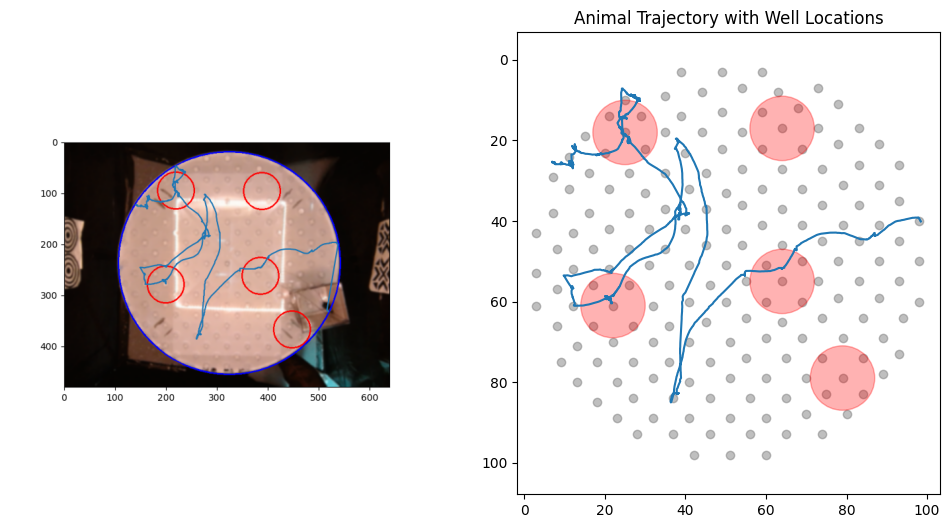

In [133]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [167]:
triggerLoc

,well_row,well_col,x,y
0,D,2,25,18
1,D,6,64,17
2,M,7,64,55
3,N,3,22,61
4,R,8,79,79


In [168]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,93406,166092,72686,1
1,213010,221155,8145,1
2,222870,223096,226,1
3,6961,13736,6775,3
4,46011,70075,24064,4


### Compute the time animal took to reach the trigger zone

In [169]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note
0,1,A,20241205,1,1,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
1,1,A,20241205,1,2,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
2,1,A,20241205,1,3,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
3,1,A,20241205,1,4,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
4,1,A,20241205,1,5,H,1,NaN,1,NaN,ChR2,e,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6755,89,N10,20260424,8,6,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6756,89,N10,20260424,8,7,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6757,89,N10,20260424,8,8,L,5,NaN,1,NaN,NAc_control,NaN,0,0,0,NaN
6758,89,N10,20260425,9,1,T,1,NaN,0,NaN,NAc_control,NaN,0,0,0,NaN


In [170]:
# initialize both columns
metadata['t_to_trigger'] = np.nan
metadata['t_to_trigger_long'] = np.nan

R_TRIGGER = 10 / 1.2

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        continue

    position_ = add_dist_to_trigger(position.copy(), triggerLoc)

    # full trial time, used as fallback
    full_trial_time = position_.iloc[-1]['t']

    dfs = []

    for i in range(len(triggerLoc)):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i + 1
        )

        if df_trigger_interaction is not None and len(df_trigger_interaction) > 0:
            df_trigger_interaction["trigger_id"] = i + 1
            dfs.append(df_trigger_interaction)

    # --------------------------------------------------------
    # If no visits at all:
    # use full trial time for BOTH columns
    # --------------------------------------------------------
    if len(dfs) == 0:
        metadata.at[trial_id, 't_to_trigger'] = full_trial_time
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time
        continue

    # --------------------------------------------------------
    # ALL visits
    # --------------------------------------------------------
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    first_entry_time = df_all_triggers.iloc[0]['t_enter']
    metadata.at[trial_id, 't_to_trigger'] = first_entry_time

    # --------------------------------------------------------
    # LONG visits only (> 2000 ms = 2 s)
    # If no long visit, use full trial time
    # --------------------------------------------------------
    df_long = df_all_triggers[df_all_triggers['duration'] > 2000]

    if len(df_long) > 0:
        first_long_entry = df_long.iloc[0]['t_enter']
        metadata.at[trial_id, 't_to_trigger_long'] = first_long_entry
    else:
        metadata.at[trial_id, 't_to_trigger_long'] = full_trial_time

 12%|█▏        | 835/6760 [00:09<00:57, 103.74it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1307/6760 [00:14<00:51, 105.34it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 47%|████▋     | 3152/6760 [00:32<00:25, 139.53it/s]

...

 83%|████████▎ | 5598/6760 [00:56<00:12, 96.30it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 88%|████████▊ | 5972/6760 [01:01<00:08, 88.72it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6760/6760 [01:08<00:00, 98.01it/s] 


([<matplotlib.axis.XTick at 0x12224e210>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

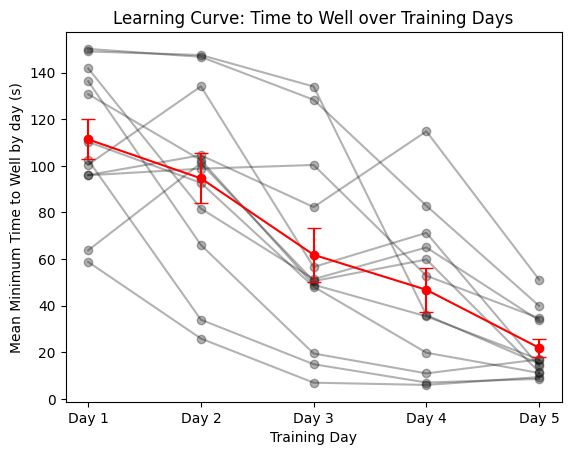

In [ ]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
    ].reset_index(drop=True)

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])

ArchT animals plotted: 6
eYFP_ArchT animals plotted: 6
WT animals plotted: 4


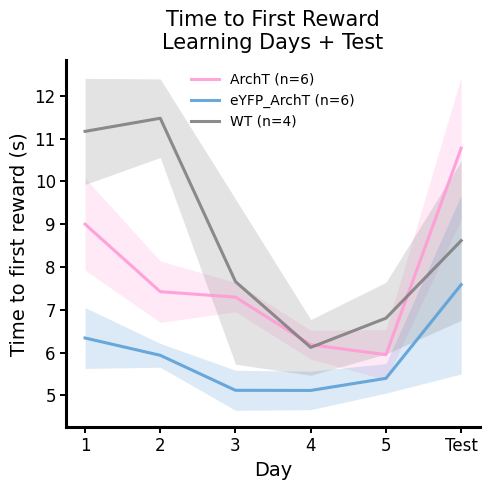

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
SHOW_STAY_TAG = False              # True -> add " (≥2 s stay)" to title
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, ArchT / eYFP_ArchT / WT, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['t_to_trigger'] != 0)          # exclude trials with no latency data
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue  # this animal has no post-learning test session

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# Learning days 1–5 + Test day 6
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector (in ms)
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days],
                        dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ArchT      = meta_LT[meta_LT['genotype'] == 'ArchT']
meta_eYFP_ArchT = meta_LT[meta_LT['genotype'] == 'eYFP_ArchT']
meta_WT         = meta_LT[meta_LT['genotype'] == 'WT']

mat_ArchT,      subs_ArchT      = build_genotype_matrix(meta_ArchT)
mat_eYFP_ArchT, subs_eYFP_ArchT = build_genotype_matrix(meta_eYFP_ArchT)
mat_WT,         subs_WT         = build_genotype_matrix(meta_WT)

print("ArchT animals plotted:", len(subs_ArchT))
print("eYFP_ArchT animals plotted:", len(subs_eYFP_ArchT))
print("WT animals plotted:", len(subs_WT))

# ---------------------------------------------------------------------
# 3. Plot: mean curves + shaded SEM, using colour function
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) t_to_trigger in ms
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ArchT')
    """
    if mat is None or len(subs) == 0:
        return

    # convert ms → s
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals, mean_s,
        '-',                    # no markers; use '-o' if you want dots
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# Plot ArchT + eYFP_ArchT + WT
plot_group_shaded(mat_ArchT,      subs_ArchT,
                  genotype_key='ArchT',
                  label='ArchT')

plot_group_shaded(mat_eYFP_ArchT, subs_eYFP_ArchT,
                  genotype_key='eYFP_ArchT',
                  label='eYFP_ArchT')

plot_group_shaded(mat_WT,         subs_WT,
                  genotype_key='WT',
                  label='WT')

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Time to First Reward' + STAY_TAG + '\nLearning Days + Test',
          fontsize=15, pad=8)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Test day animals:
  ArchT:        n = 6
  eYFP_ArchT:   n = 6
  WT:           n = 4
Mann–Whitney U (ArchT vs eYFP_ArchT) p = 0.31
Mann–Whitney U (WT vs eYFP_ArchT) p = 0.914


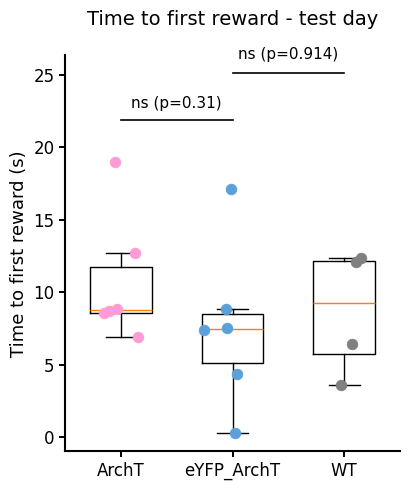

In [40]:
# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
SHOW_STAY_TAG = False
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

VALUE_COL = 't_to_trigger'   # in ms

# ------------------------------------------------------------
# 1) Filter base metadata
# ------------------------------------------------------------
meta_test = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ArchT', 'eYFP_ArchT', 'WT'])) &
    (metadata['trial_type'] == 'T') &
    (metadata[VALUE_COL].notna()) &
    (metadata[VALUE_COL] > 0)
].copy()

# ------------------------------------------------------------
# 2) Identify FIRST test session after learning (plot_day = 6)
# ------------------------------------------------------------
meta_test['is_first_test'] = False

for sub in meta_test['sub'].unique():
    ms = meta_test[meta_test['sub'] == sub]

    L_ses = metadata.loc[
        (metadata['sub'] == sub) &
        (metadata['trial_type'] == 'L'),
        'ses'
    ]

    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[ms['ses'] > last_L_ses]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    meta_test.loc[
        (meta_test['sub'] == sub) &
        (meta_test['ses'] == first_T_ses),
        'is_first_test'
    ] = True

meta_test = meta_test[meta_test['is_first_test']]

# ------------------------------------------------------------
# 3) Extract per-animal mean (convert ms → s)
# ------------------------------------------------------------
def extract_vals(meta_df, genotype, value_col):
    vals = (
        meta_df[meta_df['genotype'] == genotype]
        .groupby('sub')[value_col]
        .mean()
        .values / 1000.0
    )
    return vals

vals_ArchT       = extract_vals(meta_test, 'ArchT', VALUE_COL)
vals_eYFP_ArchT  = extract_vals(meta_test, 'eYFP_ArchT', VALUE_COL)
vals_WT          = extract_vals(meta_test, 'WT', VALUE_COL)

print("Test day animals:")
print(f"  ArchT:        n = {len(vals_ArchT)}")
print(f"  eYFP_ArchT:   n = {len(vals_eYFP_ArchT)}")
print(f"  WT:           n = {len(vals_WT)}")

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
SHOW_STAY_TAG = False
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# If your get_genotype_color doesn't have WT, we fall back to grey
WT_COLOR_FALLBACK = '0.25'

# ------------------------------------------------------------
# Assume you already have per-animal test-day values in seconds:
#   vals_ArchT, vals_eYFP_ArchT, vals_WT
# ------------------------------------------------------------

groups = ['ArchT', 'eYFP_ArchT', 'WT']
vals_groups = [vals_ArchT, vals_eYFP_ArchT, vals_WT]

# colors (WT fallback)
colors = {
    'ArchT'     : get_genotype_color('ArchT'),
    'eYFP_ArchT': get_genotype_color('eYFP_ArchT'),
    'WT'        : WT_COLOR_FALLBACK
}
try:
    colors['WT'] = get_genotype_color('WT')
except Exception:
    pass

plt.figure(figsize=(4.2, 5))

# -----------------------------
# Boxplot
# -----------------------------
bp = plt.boxplot(
    vals_groups,
    positions=np.arange(len(groups)),
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# -----------------------------
# Jittered points
# -----------------------------
for i, g in enumerate(groups):
    vals = np.asarray(vals_groups[i], dtype=float)
    vals = vals[~np.isnan(vals)]
    jitter = 0.12
    x = np.random.normal(i, jitter, size=len(vals))
    plt.scatter(
        x, vals,
        s=58,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# -----------------------------
# Stats helper
# -----------------------------
def p_to_stars(p):
    if np.isnan(p): return "ns"
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "ns"

def safe_mwu(a, b):
    a = np.asarray(a, dtype=float); a = a[~np.isnan(a)]
    b = np.asarray(b, dtype=float); b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b, alternative='two-sided')[1]

vals_a  = np.asarray(vals_ArchT, dtype=float)
vals_y  = np.asarray(vals_eYFP_ArchT, dtype=float)
vals_w  = np.asarray(vals_WT, dtype=float)

p1 = safe_mwu(vals_a, vals_y)   # ArchT vs eYFP_ArchT
p2 = safe_mwu(vals_w, vals_y)   # WT vs eYFP_ArchT

print(f"Mann–Whitney U (ArchT vs eYFP_ArchT) p = {p1:.3g}" if not np.isnan(p1) else "ArchT vs eYFP_ArchT: p = NaN")
print(f"Mann–Whitney U (WT vs eYFP_ArchT) p = {p2:.3g}" if not np.isnan(p2) else "WT vs eYFP_ArchT: p = NaN")

# -----------------------------
# Draw straight significance lines + star + p
# (no dips; straight horizontal only)
# -----------------------------
all_vals = np.concatenate([vals_a[~np.isnan(vals_a)], vals_y[~np.isnan(vals_y)], vals_w[~np.isnan(vals_w)]])
ymax = np.nanmax(all_vals) if len(all_vals) else 1.0

y1 = ymax * 1.15   # for ArchT vs eYFP (0 vs 1)
y2 = ymax * 1.32   # for WT vs eYFP (2 vs 1)

# ArchT vs eYFP (0 vs 1)
if not np.isnan(p1):
    plt.plot([0, 1], [y1, y1], color='black', linewidth=1.2)
    plt.text(
        0.5, y1 * 1.03,
        f"{p_to_stars(p1)} (p={p1:.3g})",
        ha='center', va='bottom', fontsize=11
    )

# WT vs eYFP (2 vs 1)
if not np.isnan(p2):
    plt.plot([1, 2], [y2, y2], color='black', linewidth=1.2)
    plt.text(
        1.5, y2 * 1.03,
        f"{p_to_stars(p2)} (p={p2:.3g})",
        ha='center', va='bottom', fontsize=11
    )

# -----------------------------
# Axes / labels / style
# -----------------------------
plt.ylabel('Time to first reward (s)', fontsize=13)
plt.xticks(np.arange(len(groups)), groups, fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('Time to first reward - test day' + STAY_TAG + '\n', fontsize=14, pad=6)

plt.tight_layout()
plt.show()

ChR2 animals in dataset: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in dataset: 5
eYFP_ChR2 animals plotted: 5


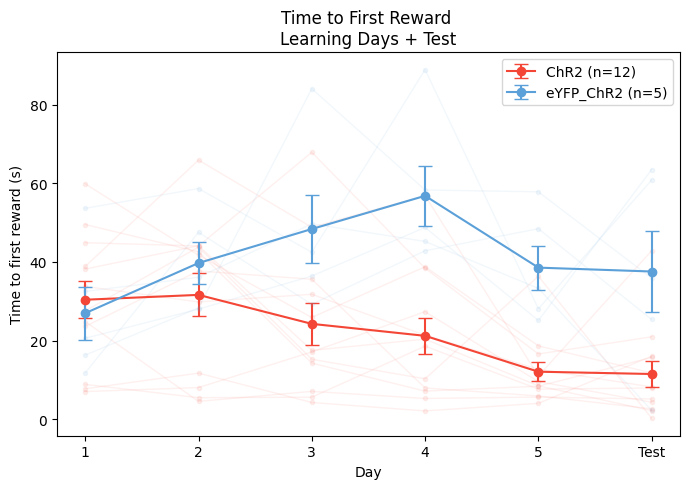

In [47]:
# time to arrive at new reward ChR2 vs YFP and stayed there for at least 2 sec

# Plot ChR2 & eYFP_ChR2 learning trials + first test day by session
# Metric: time to first reward (t_to_trigger), in seconds

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in dataset:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in dataset:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot (using colour function)
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# grab colours from your function
col_ChR2 = get_genotype_color('ChR2')
col_eYFP = get_genotype_color('eYFP_ChR2')

# ---- ChR2 ----
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row / 1000,
            '-o',
            color=col_ChR2,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o',
        color=col_ChR2,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# ---- eYFP_ChR2 ----
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(
            x_vals, row / 1000,
            '-o',
            color=col_eYFP,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o',
        color=col_eYFP,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward \nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

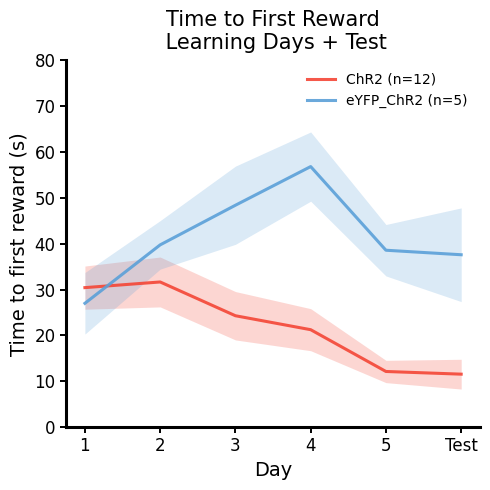

In [49]:
# time to first reward - clean figure

# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) time-to-trigger in ms
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    # convert ms → s
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals, mean_s,
        '-',                    # no markers; use '-o' if you want dots
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# --- plot both groups using your color function ---
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Time to First Reward\n Learning Days + Test',
          fontsize=15, pad=8)

#(≥2 s stay)

plt.legend(frameon=False)
plt.ylim(0, 80)   # set min/max
plt.tight_layout()
plt.show()

Group plotted: NAc (NAc)
Using column: t_to_trigger_long
Animals included per transition:
  Day 1 best -> Day 2 trial 1: n = 7
  Day 2 best -> Day 3 trial 1: n = 7
  Day 3 best -> Day 4 trial 1: n = 7
  Day 4 best -> Day 5 trial 1: n = 7
  Day 5 best -> Test trial 1: n = 7


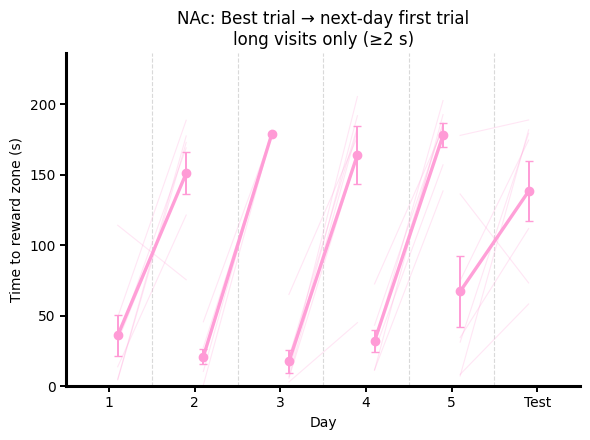

In [198]:
# ============================================================
# Flexible genotype:
# Plot "best trial from previous day" -> "first trial next day"
# Metric: time to reward zone
#
# Transitions plotted:
#   Day 1 best  -> Day 2 trial 1
#   Day 2 best  -> Day 3 trial 1
#   Day 3 best  -> Day 4 trial 1
#   Day 4 best  -> Day 5 trial 1
#   Day 5 best  -> Test day trial 1
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'NAc'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = True        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AS','AN']               # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

FILTER_SHORT_DURATION = False # True -> apply short_duration != 1
                              # False -> no short_duration filter

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 4) For each animal and day:
#    - best trial = MIN time within that day
#    - first trial = trial_in_day == 1
# ------------------------------------------------------------
def per_subject_day_values(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, best_val, first_val
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'best_val', 'first_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        # mean per trial if duplicates exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        best_val = np.nanmin(by_trial.values)   # smaller time = better
        first_val = by_trial.get(1, np.nan)

        rows.append({
            'sub': sub,
            'best_val': best_val,
            'first_val': first_val
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build transition values:
#    day d best -> day d+1 first
# ------------------------------------------------------------
transitions = []

for d_prev, d_next in [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6)]:
    prev_df = (
        per_subject_day_values(meta_LT, d_prev, TIME_COL)[['sub', 'best_val']]
        .rename(columns={'best_val': 'y_prev'})
    )

    next_df = (
        per_subject_day_values(meta_LT, d_next, TIME_COL)[['sub', 'first_val']]
        .rename(columns={'first_val': 'y_next'})
    )

    merged = prev_df.merge(next_df, on='sub', how='inner').dropna()

    transitions.append({
        'd_prev': d_prev,
        'd_next': d_next,
        'df': merged
    })

print(f"Group plotted: {GROUP_LABEL} ({GENOTYPE_TO_PLOT})")
print(f"Using column: {TIME_COL}")
print("Animals included per transition:")

for tr in transitions:
    n = len(tr['df'])
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    nxt_label = 'Test' if d_next == 6 else f'Day {d_next}'
    print(f"  Day {d_prev} best -> {nxt_label} trial 1: n = {n}")

# ------------------------------------------------------------
# 6) Plot helper
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))

col = get_genotype_color(GENOTYPE_TO_PLOT)

# x positions
x_best_offset  = 0.6
x_first_offset = 0.4

all_y_s = []

for tr in transitions:
    d_prev = tr['d_prev']
    d_next = tr['d_next']
    df_tr = tr['df']

    if len(df_tr) == 0:
        continue

    x_prev = d_prev + x_best_offset
    x_next = d_next + x_first_offset

    # --------------------------------------------------------
    # 1) Individual animal lines
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_tr.iterrows():
            y_prev_s = row['y_prev'] / 1000.0
            y_next_s = row['y_next'] / 1000.0

            ax.plot(
                [x_prev, x_next],
                [y_prev_s, y_next_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

            all_y_s.extend([y_prev_s, y_next_s])

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    y_prev = df_tr['y_prev'].values / 1000.0
    y_next = df_tr['y_next'].values / 1000.0

    all_y_s.extend(list(y_prev) + list(y_next))

    m_prev, s_prev = mean_sem(y_prev)
    m_next, s_next = mean_sem(y_next)

    ax.plot(
        [x_prev, x_next],
        [m_prev, m_next],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=3
    )

    ax.errorbar(
        x_prev,
        m_prev,
        yerr=s_prev,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x_next,
        m_next,
        yerr=s_next,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
for d in [2, 3, 4, 5, 6]:
    ax.axvline(d, color='0.85', linestyle='--', linewidth=0.8, zorder=0)

ax.set_xticks([1.5, 2.5, 3.5, 4.5, 5.5, 6.5])
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(1.0, 7.0)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: Best trial → next-day first trial\n'
    f'{TITLE_SUFFIX}',
    fontsize=12
)

if len(all_y_s) > 0:
    ymax = np.nanmax(all_y_s)
    ax.set_ylim(0, ymax * 1.15)

style_nature(ax)
plt.tight_layout()
plt.show()

Using genotype: NAc (NAc)
Using column: t_to_trigger
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included per within-day comparison:
  Day 1: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 2: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 3: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 4: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Day 5: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Test: n = 7, animals = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']

Wilcoxon signed-rank tests: first trial vs best trial of same day
Alternative used: two-sided
Test day is plotted as one dot only and is not tested.
  Day 1: n = 7, first mean = 54.093 s, best mean = 3.046 s, median diff best-first = -16.707 s, W = 0.000, p = 0.02771
  Day 2: n = 7, first mean = 56.810 s, best mean = 4.225 s, median diff best-first = -7.284 s, W = 0.000, p = 0.04311
  Day 3: n = 7, f

/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:199: UserWarning: Sample size too small for normal approximation.
  temp = _wilcoxon_iv(x, y, zero_method, correction, alternative, method, axis)


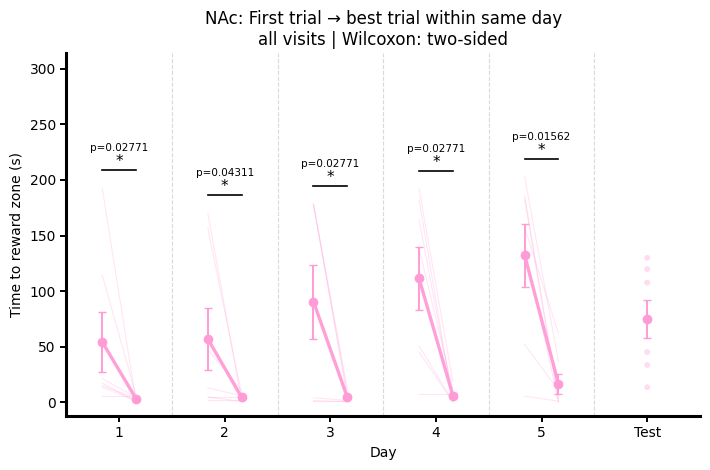

In [200]:
# ============================================================
# Flexible genotype:
# Plot "first trial of each day" -> "best trial of same day"
# Metric: time to reward zone
#
# Within-day progress:
#   Day 1 trial 1 -> Day 1 best trial
#   Day 2 trial 1 -> Day 2 best trial
#   Day 3 trial 1 -> Day 3 best trial
#   Day 4 trial 1 -> Day 4 best trial
#   Day 5 trial 1 -> Day 5 best trial
#
# Test day:
#   only one trial, so it is plotted as one dot only
#   no paired line / Wilcoxon test for Test
#
# IMPORTANT:
# For time-to-trigger, "best trial" = SMALLEST time
#
# Stats:
#   Wilcoxon signed-rank test, paired within animal
#   alternative='less' tests whether best trial < first trial
#   alternative='two-sided' tests whether first and best are different
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
GENOTYPE_TO_PLOT = 'NAc'      # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'CA1_control'
PLOT_INDIVIDUAL = True        # False -> only mean ± SEM
USE_LONG_VISITS = False        # False -> t_to_trigger ; True -> t_to_trigger_long

EXCLUDE_ID = ['AS', 'AN']     # e.g. ['AS']
EXCLUDE_SUBS = []             # e.g. [43]

# Wilcoxon:
# 'less' = tests whether best trial time < first trial time
# 'two-sided' = tests whether first and best are different
WILCOXON_ALTERNATIVE = 'two-sided'

SHOW_P_VALUES = True
SHOW_STARS = True
P_DECIMALS = 5

# x-axis positioning
X_FIRST_OFFSET = -0.16
X_BEST_OFFSET  =  0.16

# p-value annotation spacing
P_LINE_FRAC_ABOVE = 0.08
P_STAR_FRAC_ABOVE = 0.004   # smaller = star closer to horizontal line
P_TEXT_FRAC_ABOVE = 0.075

# y-axis
YMIN = None          # None -> slightly below 0
YMAX = None          # None -> auto
Y_BOTTOM_PAD_FRAC = 0.04

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_LABEL = 'Time to reward zone (s)'
TITLE_SUFFIX = 'long visits only (≥2 s)' if USE_LONG_VISITS else 'all visits'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

GROUP_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_PLOT, GENOTYPE_TO_PLOT)

plot_days = np.array([1, 2, 3, 4, 5, 6])

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
#    L -> 1..5
#    first T session after last L -> 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep only learning days 1..5 for L
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day',
    'trial_num',
    'trial_number',
    'trial',
    'trial_idx',
    'trial_index',
    'trial_in_session',
    'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GROUP_LABEL, f"({GENOTYPE_TO_PLOT})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) For each animal and day:
#    - first trial = trial_in_day == 1
#    - best trial = MIN time within that day
# ------------------------------------------------------------
def per_subject_day_first_best(meta_g, day, value_col):
    """
    Returns one row per animal:
      sub, id, first_val, best_val

    For time-to-trigger:
      best_val = minimum time within that day.
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'first_val', 'best_val'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        # mean per trial if duplicate rows exist
        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        first_val = by_trial.get(1, np.nan)
        best_val = np.nanmin(by_trial.values.astype(float))  # smaller time = better

        if not np.isfinite(first_val) or not np.isfinite(best_val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'first_val': float(first_val),
            'best_val': float(best_val)
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build within-day comparison values
# ------------------------------------------------------------
within_day = []

for d in plot_days:
    df_d = per_subject_day_first_best(meta_LT, d, TIME_COL)

    within_day.append({
        'day': d,
        'df': df_d
    })

print("\nAnimals included per within-day comparison:")
for wd in within_day:
    d = wd['day']
    df_d = wd['df']
    day_label = 'Test' if d == 6 else f'Day {d}'
    print(
        f"  {day_label}: n = {len(df_d)}, "
        f"animals = {list(df_d['id']) if len(df_d) > 0 else []}"
    )

# ------------------------------------------------------------
# 6) Stats + plotting helpers
# ------------------------------------------------------------
def mean_sem(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return np.nan, np.nan

    if len(x) == 1:
        return x[0], 0.0

    return np.nanmean(x), np.nanstd(x, ddof=1) / np.sqrt(len(x))


def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def run_wilcoxon_paired(first_vals, best_vals, alternative='less'):
    """
    Paired Wilcoxon signed-rank test.

    For time-to-reward:
      alternative='less' tests whether best_vals < first_vals.
      alternative='two-sided' tests whether best_vals != first_vals.

    If all differences are zero, scipy raises an error;
    in that case return p=1.
    """
    first_vals = np.asarray(first_vals, float)
    best_vals = np.asarray(best_vals, float)

    ok = np.isfinite(first_vals) & np.isfinite(best_vals)
    first_vals = first_vals[ok]
    best_vals = best_vals[ok]

    if len(first_vals) == 0:
        return np.nan, np.nan

    diffs = best_vals - first_vals

    if np.allclose(diffs, 0):
        return 0.0, 1.0

    try:
        stat, p = wilcoxon(
            best_vals,
            first_vals,
            alternative=alternative,
            zero_method='wilcox'
        )
    except ValueError:
        stat, p = np.nan, np.nan

    return stat, p


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)

# ------------------------------------------------------------
# 7) Run stats first
#    Test day is skipped because it usually has only one trial.
# ------------------------------------------------------------
print("\nWilcoxon signed-rank tests: first trial vs best trial of same day")
print(f"Alternative used: {WILCOXON_ALTERNATIVE}")
print("Test day is plotted as one dot only and is not tested.")

stats_results = {}

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    day_label = 'Test' if d == 6 else f'Day {d}'

    if d == 6:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': len(df_d)
        }
        print(f"  {day_label}: n = {len(df_d)}, no test")
        continue

    if len(df_d) == 0:
        stats_results[d] = {
            'stat': np.nan,
            'p': np.nan,
            'n': 0
        }
        print(f"  {day_label}: n = 0, p = NaN")
        continue

    first_vals = df_d['first_val'].values.astype(float)
    best_vals = df_d['best_val'].values.astype(float)

    stat, p = run_wilcoxon_paired(
        first_vals,
        best_vals,
        alternative=WILCOXON_ALTERNATIVE
    )

    stats_results[d] = {
        'stat': stat,
        'p': p,
        'n': len(df_d)
    }

    print(
        f"  {day_label}: "
        f"n = {len(df_d)}, "
        f"first mean = {np.nanmean(first_vals) / 1000.0:.3f} s, "
        f"best mean = {np.nanmean(best_vals) / 1000.0:.3f} s, "
        f"median diff best-first = {np.nanmedian((best_vals - first_vals) / 1000.0):.3f} s, "
        f"W = {stat:.3f}, "
        f"p = {format_p(p, P_DECIMALS)}"
        if np.isfinite(p)
        else
        f"  {day_label}: n = {len(df_d)}, p = NaN"
    )

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(7.2, 4.8))

col = get_genotype_color(GENOTYPE_TO_PLOT)

all_y_for_ylim = []

for wd in within_day:
    d = wd['day']
    df_d = wd['df']

    if len(df_d) == 0:
        continue

    # --------------------------------------------------------
    # Test day:
    # only plot single trial/best point, no paired line/stat
    # dots remain
    # --------------------------------------------------------
    if d == 6:
        x_test = d

        test_vals_s = df_d['first_val'].values.astype(float) / 1000.0
        test_vals_s = test_vals_s[np.isfinite(test_vals_s)]

        all_y_for_ylim.extend(test_vals_s)

        if len(test_vals_s) == 0:
            continue

        if PLOT_INDIVIDUAL:
            ax.scatter(
                np.full(len(test_vals_s), x_test),
                test_vals_s,
                color=col,
                s=18,
                alpha=0.35,
                edgecolor='none',
                zorder=2
            )

        m_test, s_test = mean_sem(test_vals_s)

        ax.errorbar(
            x_test,
            m_test,
            yerr=s_test,
            fmt='o',
            color=col,
            markersize=6,
            capsize=3,
            linewidth=1.4,
            zorder=5
        )

        continue

    x_first = d + X_FIRST_OFFSET
    x_best  = d + X_BEST_OFFSET

    first_vals_s = df_d['first_val'].values.astype(float) / 1000.0
    best_vals_s = df_d['best_val'].values.astype(float) / 1000.0

    all_y_for_ylim.extend(first_vals_s[np.isfinite(first_vals_s)])
    all_y_for_ylim.extend(best_vals_s[np.isfinite(best_vals_s)])

    # --------------------------------------------------------
    # 1) Individual animal paired lines only
    #    No individual dots for learning days 1-5
    # --------------------------------------------------------
    if PLOT_INDIVIDUAL:
        for _, row in df_d.iterrows():
            y_first_s = row['first_val'] / 1000.0
            y_best_s = row['best_val'] / 1000.0

            ax.plot(
                [x_first, x_best],
                [y_first_s, y_best_s],
                color=col,
                linewidth=0.8,
                alpha=0.25,
                zorder=1
            )

    # --------------------------------------------------------
    # 2) Group mean ± SEM
    # --------------------------------------------------------
    m_first, s_first = mean_sem(first_vals_s)
    m_best, s_best = mean_sem(best_vals_s)

    ax.plot(
        [x_first, x_best],
        [m_first, m_best],
        '-',
        color=col,
        linewidth=2.4,
        alpha=0.95,
        zorder=4
    )

    ax.errorbar(
        x_first,
        m_first,
        yerr=s_first,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

    ax.errorbar(
        x_best,
        m_best,
        yerr=s_best,
        fmt='o',
        color=col,
        markersize=6,
        capsize=3,
        linewidth=1.4,
        zorder=5
    )

# ------------------------------------------------------------
# 9) Add p-value bars after determining y scale
# ------------------------------------------------------------
if len(all_y_for_ylim) > 0:
    y_data_max = np.nanmax(all_y_for_ylim)
    y_data_min = np.nanmin(all_y_for_ylim)

    yrng = y_data_max - y_data_min
    if not np.isfinite(yrng) or yrng <= 0:
        yrng = max(abs(y_data_max), 1.0)

    for wd in within_day:
        d = wd['day']
        df_d = wd['df']

        # Skip test day
        if d == 6:
            continue

        if len(df_d) == 0:
            continue

        x_first = d + X_FIRST_OFFSET
        x_best  = d + X_BEST_OFFSET
        x_mid = (x_first + x_best) / 2

        local_vals_s = np.r_[
            df_d['first_val'].values.astype(float) / 1000.0,
            df_d['best_val'].values.astype(float) / 1000.0
        ]

        local_max = np.nanmax(local_vals_s)

        y_line = local_max + P_LINE_FRAC_ABOVE * yrng
        y_star = y_line + P_STAR_FRAC_ABOVE * yrng
        y_pval = y_line + P_TEXT_FRAC_ABOVE * yrng

        p = stats_results[d]['p']

        ax.plot(
            [x_first, x_best],
            [y_line, y_line],
            color='black',
            linewidth=1.2,
            zorder=6
        )

        if SHOW_STARS:
            ax.text(
                x_mid,
                y_star,
                p_to_stars(p),
                ha='center',
                va='bottom',
                fontsize=11,
                zorder=7
            )

        if SHOW_P_VALUES:
            ax.text(
                x_mid,
                y_pval,
                f"p={format_p(p, P_DECIMALS)}",
                ha='center',
                va='bottom',
                fontsize=7.5,
                zorder=7
            )

# ------------------------------------------------------------
# 10) Styling
# ------------------------------------------------------------
for d in [1.5, 2.5, 3.5, 4.5, 5.5]:
    ax.axvline(
        d,
        color='0.85',
        linestyle='--',
        linewidth=0.8,
        zorder=0
    )

ax.set_xticks(plot_days)
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'])

ax.set_xlim(0.5, 6.5)

ax.set_xlabel('Day')
ax.set_ylabel(TIME_LABEL)

ax.set_title(
    f'{GROUP_LABEL}: First trial → best trial within same day\n'
    f'{TITLE_SUFFIX} | Wilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12
)

# y-axis
if YMAX is not None:
    ymax = YMAX
else:
    if len(all_y_for_ylim) > 0:
        ymax = np.nanmax(all_y_for_ylim)
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = 1.0
        ymax = ymax * 1.55
    else:
        ymax = 1.0

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)

plt.tight_layout()
plt.show()

Using genotype: NAc (NAc)
Using column: t_to_trigger_long
Using trial column: inferred from sub/ses order
Wilcoxon alternative used: two-sided

Animals included: n = 7
   sub  id  Day 1 trials  Day 5 trials
0   64  N1             8             8
1   65  N2             8             8
2   66  N3             8             7
3   67  N4             8             8
4   68  N5             8             8
5   69  N6             7             8
6   70  N7             8             8

Paired values used for Wilcoxon:
   sub  id        y1_s        y2_s  diff_y2_minus_y1_s  n1  n2
0   64  N1   97.321500  122.128500           24.807000   8   8
1   65  N2  143.851750  106.216875          -37.634875   8   8
2   66  N3   99.042500  185.902714           86.860214   8   7
3   67  N4  161.865000  151.259125          -10.605875   8   8
4   68  N5  175.120625  135.047750          -40.072875   8   8
5   69  N6   88.624571  145.003375           56.378804   7   8
6   70  N7  126.475000  171.276000           

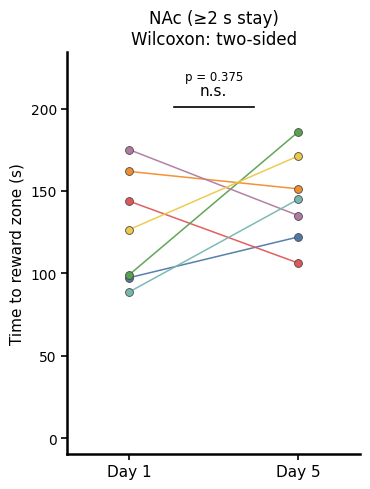

In [ ]:
from scipy.stats import wilcoxon
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# OPTIONS
# ============================================================
COMPARE_MODE = 'day1_vs_day5'   # 'day1_vs_test' or 'day1_vs_day5'

GENOTYPE_TO_USE = 'NAc'        # e.g. 'ChR2', 'CA1', 'CA3', 'NAc', 'eYFP_ChR2', 'CA1_control'
PLOT_INDIVIDUAL = True
PLOT_GROUP_MEAN = False         # False -> hide thick mean/SEM overlay
SHOW_ANIMAL_IDS = False

EXCLUDE_ID = ['AS', 'AN']
EXCLUDE_SUBS = []

# choose latency metric
USE_LONG_VISITS = True          # False -> t_to_trigger ; True -> t_to_trigger_long
TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
TIME_SUFFIX = ' (≥2 s stay)' if USE_LONG_VISITS else ' (all visits)'

# Wilcoxon:
# 'two-sided' = tests whether paired values are different
# 'greater'   = tests whether y1 > y2
# 'less'      = tests whether y1 < y2
WILCOXON_ALTERNATIVE = 'two-sided'

# individual animal colour style:
#   'pastel' -> each animal gets distinct colours
#   'shades' -> animals are different shades of genotype colour
INDIVIDUAL_COLOR_MODE = 'pastel'

# whether to draw a thin edge around each dot
DOT_EDGE = True

# y-axis padding
YMIN = None
YMAX = None
Y_BOTTOM_PAD_FRAC = 0.04

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'Control': 'Control',
}

GENOTYPE_LABEL = DISPLAY_NAME.get(GENOTYPE_TO_USE, GENOTYPE_TO_USE)

# ------------------------------------------------------------
# 1) Filter: usable, selected genotype, L/T, metric available
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GENOTYPE_TO_USE) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if FILTER_SHORT_DURATION and 'short_duration' in meta_LT.columns:
    meta_LT = meta_LT[meta_LT['short_duration'] != 1].copy()

if len(EXCLUDE_ID) > 0 and 'id' in meta_LT.columns:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# 2) Assign plot_day
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

plot_days = np.array([1, 2, 3, 4, 5, 6])
meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3) Create trial_in_day = 1..8
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]

trial_col = next((c for c in candidate_cols if c in meta_LT.columns), None)

if trial_col is not None:
    meta_LT['trial_in_day'] = meta_LT[trial_col].astype(int)
else:
    meta_LT = meta_LT.sort_values(['sub', 'ses']).copy()
    meta_LT['trial_in_day'] = meta_LT.groupby(['sub', 'ses']).cumcount() + 1

meta_LT = meta_LT[meta_LT['trial_in_day'].between(1, 8)].copy()

print("Using genotype:", GENOTYPE_LABEL, f"({GENOTYPE_TO_USE})")
print("Using column:", TIME_COL)
print("Using trial column:", trial_col if trial_col is not None else "inferred from sub/ses order")
print("Wilcoxon alternative used:", WILCOXON_ALTERNATIVE)

# ------------------------------------------------------------
# 4) Per-subject helpers
# ------------------------------------------------------------
def per_subject_day_mean(meta_g, day, value_col):
    """
    One value per animal = mean across available trials in that day.
    Used for:
      - Day 1 in day1_vs_day5
      - Day 5 in day1_vs_day5
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if len(by_trial) == 0:
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': np.nanmean(by_trial.values),
            'n_trials': len(by_trial)
        })

    return pd.DataFrame(rows)


def per_subject_day_first_trial(meta_g, day, value_col):
    """
    One value per animal = trial 1 only from that day.
    Used for:
      - Day 1 in day1_vs_test
      - Test day in day1_vs_test
    """
    md = meta_g[meta_g['plot_day'] == day].copy()

    if len(md) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'mean_val', 'n_trials'])

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_id = str(ms['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        by_trial = (
            ms.groupby('trial_in_day', as_index=True)[value_col]
              .mean()
              .sort_index()
        )

        by_trial = by_trial[np.isfinite(by_trial.values)]

        if 1 not in by_trial.index:
            continue

        val = by_trial.loc[1]

        if not np.isfinite(val):
            continue

        rows.append({
            'sub': sub,
            'id': animal_id,
            'mean_val': float(val),
            'n_trials': 1
        })

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5) Build paired dataframe
# ------------------------------------------------------------
if COMPARE_MODE == 'day1_vs_test':
    # Day 1 = trial 1 only.
    # Test = test trial 1 only.
    day1_df = per_subject_day_first_trial(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_first_trial(meta_LT, 6, TIME_COL)

    left_label = 'Day 1 trial 1'
    right_label = 'Test'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'

elif COMPARE_MODE == 'day1_vs_day5':
    # Day 1 = mean of available Day 1 trials.
    # Day 5 = mean of available Day 5 trials.
    day1_df = per_subject_day_mean(meta_LT, 1, TIME_COL)
    comp_df = per_subject_day_mean(meta_LT, 5, TIME_COL)

    left_label = 'Day 1'
    right_label = 'Day 5'
    title_txt = f'{GENOTYPE_LABEL}{TIME_SUFFIX}'

else:
    raise ValueError("COMPARE_MODE must be 'day1_vs_test' or 'day1_vs_day5'")

paired = (
    day1_df[['sub', 'id', 'mean_val', 'n_trials']]
    .rename(columns={'mean_val': 'y1', 'n_trials': 'n1'})
    .merge(
        comp_df[['sub', 'mean_val', 'n_trials']]
        .rename(columns={'mean_val': 'y2', 'n_trials': 'n2'}),
        on='sub',
        how='inner'
    )
    .dropna()
    .sort_values('sub')
    .reset_index(drop=True)
)

print(f'\nAnimals included: n = {len(paired)}')
print(
    paired[['sub', 'id', 'n1', 'n2']]
    .rename(columns={'n1': f'{left_label} trials', 'n2': f'{right_label} trials'})
)

print("\nPaired values used for Wilcoxon:")
if len(paired) > 0:
    paired_print = paired.copy()
    paired_print['y1_s'] = paired_print['y1'] / 1000.0
    paired_print['y2_s'] = paired_print['y2'] / 1000.0
    paired_print['diff_y2_minus_y1_s'] = paired_print['y2_s'] - paired_print['y1_s']
    print(paired_print[['sub', 'id', 'y1_s', 'y2_s', 'diff_y2_minus_y1_s', 'n1', 'n2']])
else:
    print("No paired data.")

# ------------------------------------------------------------
# 6) Wilcoxon signed-rank test
# ------------------------------------------------------------
y1 = paired['y1'].values.astype(float)
y2 = paired['y2'].values.astype(float)

if len(y1) > 0:
    diffs = y2 - y1

    if np.allclose(diffs, 0):
        stat_w, p_w = 0.0, 1.0
    else:
        try:
            stat_w, p_w = wilcoxon(
                y1,
                y2,
                alternative=WILCOXON_ALTERNATIVE,
                zero_method='wilcox'
            )
        except ValueError:
            stat_w, p_w = np.nan, np.nan
else:
    stat_w, p_w = np.nan, np.nan

print(
    f"\nWilcoxon signed-rank p = {p_w:.3g}"
    if np.isfinite(p_w)
    else "\nWilcoxon signed-rank p = NaN"
)
print(f"The Wilcoxon test is run on {len(y1)} paired animal values.")

if COMPARE_MODE == 'day1_vs_test':
    print("Day 1 value = first trial of Day 1 only.")
    print("Test value = first trial of first post-learning test session only.")
else:
    print("Day 1 value = mean across available Day 1 trials.")
    print("Day 5 value = mean across available Day 5 trials.")

# ------------------------------------------------------------
# 7) Helpers
# ------------------------------------------------------------
def p_to_stars(p):
    if not np.isfinite(p):
        return 'n.s.'
    if p < 1e-4:
        return '****'
    if p < 1e-3:
        return '***'
    if p < 1e-2:
        return '**'
    if p < 0.05:
        return '*'
    return 'n.s.'


def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.8)
    ax.spines['left'].set_linewidth(1.8)
    ax.tick_params(direction='out', length=4, width=1.2)
    ax.grid(False)


def lighten_color(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def get_nature_palette(n):
    """
    Publication-style muted but visible colours.
    """
    palette = [
        '#4E79A7', '#E15759', '#59A14F', '#F28E2B',
        '#B07AA1', '#76B7B2', '#EDC948', '#FF9DA7',
        '#9C755F', '#BAB0AC', '#86BCB6', '#D37295',
        '#8CD17D', '#F1CE63', '#499894', '#E17C05',
    ]
    return [palette[i % len(palette)] for i in range(n)]

# ------------------------------------------------------------
# 8) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(3.8, 5.0))

base_col = get_genotype_color(GENOTYPE_TO_USE)

# closer x positions
x1, x2 = 0.00, 0.55

# choose individual animal colours
n_animals = len(paired)

if INDIVIDUAL_COLOR_MODE == 'pastel':
    indiv_cols = get_nature_palette(n_animals)
elif INDIVIDUAL_COLOR_MODE == 'shades':
    shade_vals = np.linspace(0.35, 0.95, max(n_animals, 2))
    indiv_cols = [lighten_color(base_col, amount=s) for s in shade_vals[:n_animals]]
else:
    raise ValueError("INDIVIDUAL_COLOR_MODE must be 'pastel' or 'shades'")

dot_edgecolor = '#4a4a4a' if DOT_EDGE else 'none'
dot_linewidth = 0.6 if DOT_EDGE else 0.0

# individual paired lines
if PLOT_INDIVIDUAL:
    for i, (_, row) in enumerate(paired.iterrows()):
        this_col = indiv_cols[i]

        ax.plot(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            color=this_col,
            linewidth=1.1,
            alpha=0.95,
            zorder=1
        )

        ax.scatter(
            [x1, x2],
            [row['y1'] / 1000.0, row['y2'] / 1000.0],
            s=32,
            color=this_col,
            edgecolor=dot_edgecolor,
            linewidth=dot_linewidth,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            ax.text(
                x2 + 0.03,
                row['y2'] / 1000.0,
                str(row['id']),
                fontsize=6.5,
                alpha=0.8,
                va='center'
            )

# optional group mean ± SEM
y1_s = y1 / 1000.0
y2_s = y2 / 1000.0

if PLOT_GROUP_MEAN and len(y1_s) > 0:
    m1 = np.nanmean(y1_s)
    m2 = np.nanmean(y2_s)

    s1 = 0.0 if len(y1_s) <= 1 else np.nanstd(y1_s, ddof=1) / np.sqrt(len(y1_s))
    s2 = 0.0 if len(y2_s) <= 1 else np.nanstd(y2_s, ddof=1) / np.sqrt(len(y2_s))

    ax.plot(
        [x1, x2],
        [m1, m2],
        '-',
        color=base_col,
        linewidth=2.4,
        zorder=3
    )

    ax.errorbar(
        x1,
        m1,
        yerr=s1,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

    ax.errorbar(
        x2,
        m2,
        yerr=s2,
        fmt='o',
        color=base_col,
        markersize=7,
        capsize=3,
        linewidth=1.4,
        zorder=4
    )

# significance line + stars + p value
all_y_s = np.r_[y1_s, y2_s]

if len(all_y_s) > 0 and np.isfinite(all_y_s).any():
    ymax_data = np.nanmax(all_y_s)
    yrng = ymax_data if ymax_data > 0 else 1.0

    y_line = ymax_data + 0.08 * yrng
    y_star = ymax_data + 0.11 * yrng
    y_pval = ymax_data + 0.16 * yrng
else:
    ymax_data = 1.0
    yrng = 1.0
    y_line = 1.08
    y_star = 1.11
    y_pval = 1.16

xmid = (x1 + x2) / 2
half_len = 0.13

ax.plot(
    [xmid - half_len, xmid + half_len],
    [y_line, y_line],
    color='k',
    lw=1.2,
    zorder=5
)

ax.text(
    xmid,
    y_star,
    p_to_stars(p_w),
    ha='center',
    va='bottom',
    fontsize=11,
    zorder=6
)

ax.text(
    xmid,
    y_pval,
    f'p = {p_w:.3g}' if np.isfinite(p_w) else 'p = NaN',
    ha='center',
    va='bottom',
    fontsize=8.5,
    zorder=6
)

# styling
ax.set_xticks([x1, x2])
ax.set_xticklabels([left_label, right_label], fontsize=11)
ax.set_ylabel('Time to reward zone (s)', fontsize=11)

ax.set_title(
    f'{title_txt}\nWilcoxon: {WILCOXON_ALTERNATIVE}',
    fontsize=12,
    pad=6
)

ax.set_xlim(-0.20, 0.75)

if YMAX is not None:
    ymax = YMAX
else:
    ymax = y_pval + 0.10 * ymax_data

if YMIN is not None:
    ymin = YMIN
else:
    ymin = -Y_BOTTOM_PAD_FRAC * ymax

ax.set_ylim(ymin, ymax)

style_nature(ax)
plt.tight_layout()
plt.show()

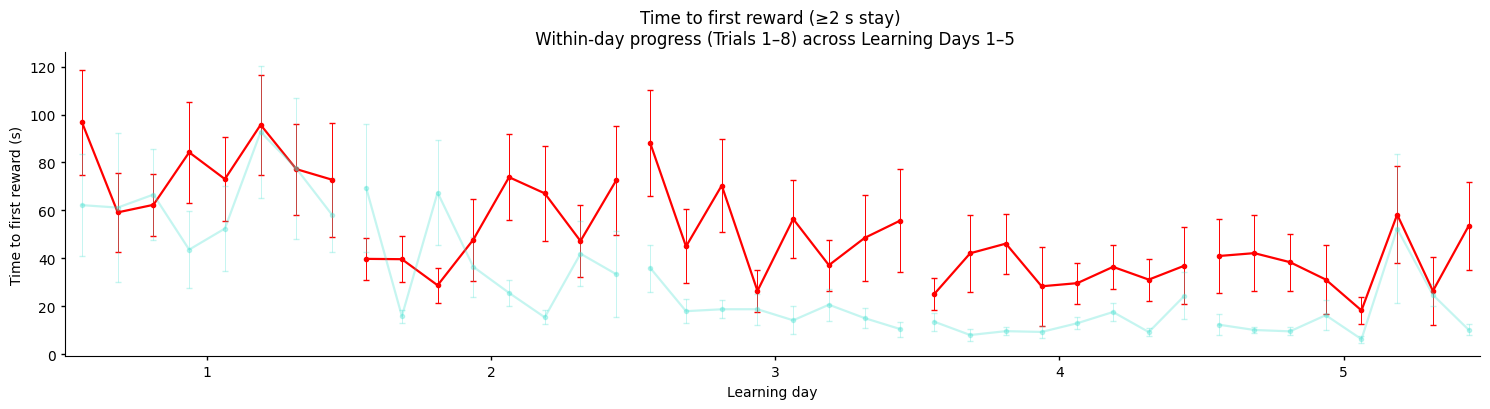

In [ ]:

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    #(metadata['genotype'].isin(['F231A', 'F231A_wt'])) & ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)
        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,        # <-- add this
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# Split by genotype
meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()

# Wider figure so Day 5 curve isn't clipped
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red', alpha=1.0)
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # <-- more faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Centered day ticks
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure Day 5 curve fully visible

ax.set_xlim(1.0, 5.98)

ax.set_title('Time to first reward (≥2 s stay) \n Within-day progress (Trials 1–8) across Learning Days 1–5', fontsize=12)
#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


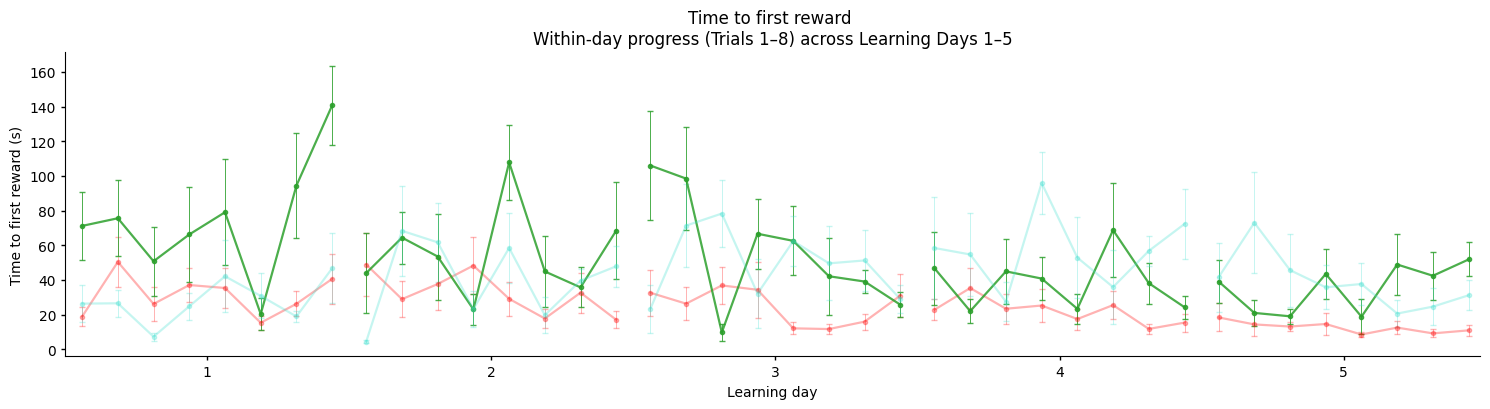

In [ ]:
# Plot ChR2 vs eYFP_ChR2 vs Hp learning trials

# ------------------------------------------------------------
# 1) Filter: usable animals, include 3 genotypes, L only, days 1–5
#    exclude short_duration==1 and exclude missing t_to_trigger (==0)
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'] == 'L') &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    # fallback: infer by order within (sub, ses)
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        # keep subject if they have at least 1 trial that day
        if np.all(np.isnan(vals)):
            continue

        rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
#    (group mean ± SEM; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points inside each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0  # ms -> s
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,   # thinner SEM bars
            capsize=2,
            markersize=3
        )

# ------------------------------------------------------------
# 5) Nature-style axes (no top/right box)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (3 groups)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
print("  Hp:", meta_Hp['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day ticks; extra room for day 5 curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

plot_within_day_curves(ax, meta_ChR2, color='red',       alpha=0.3)
plot_within_day_curves(ax, meta_Hp,   color='#2ca02c',   alpha=0.85)  # Hp in green
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)  # control faded

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# Center x tick labels under each day's curve (middle of the curve)
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Tighten left space + ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

#(≥2 s stay)

style_nature(ax)

plt.tight_layout()
plt.show()

Animals included (n):
  ChR2 long (L, short_duration=0): 12
  eYFP_ChR2 (L): 5
  ChR2 short (SL, short_duration=1): 4


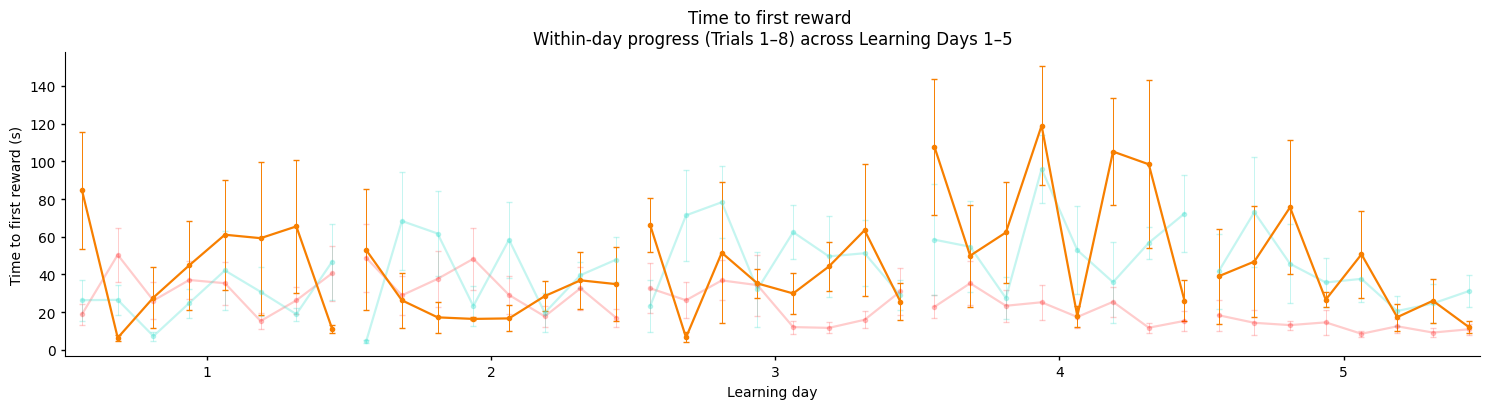

In [ ]:
# Plot ChR2 long L vs eYFP L vs ChR2 short SL learning trials
# ------------------------------------------------------------
# 0) Base filter: usable, relevant genotypes, L/SL learning days 1–5
#    (exclude missing t_to_trigger == 0)
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['t_to_trigger'] != 0)
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 1) trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_all.columns), None)

if trial_col is not None:
    meta_all['trial_in_day'] = meta_all[trial_col].astype(int)
else:
    meta_all = meta_all.sort_values(['sub', 'ses']).copy()
    meta_all['trial_in_day'] = meta_all.groupby(['sub', 'ses']).cumcount() + 1

meta_all = meta_all[meta_all['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 2) Helper: subject×trial matrix for a given day (allow missing trials)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in sorted(md['sub'].unique()):
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if np.all(np.isnan(vals)):
            continue
        rows.append(vals)

    if len(rows) == 0:
        return None
    return np.vstack(rows)

# ------------------------------------------------------------
# 3) Build per-group meta for within-day curves
#    (Group 1: ChR2 long L; Group 2: eYFP L; Group 3: ChR2 short SL)
# ------------------------------------------------------------
def select_group(meta_all, genotype, learning_type='L', short_duration_val=None):
    m = meta_all[
        (meta_all['genotype'] == genotype) &
        (meta_all['trial_type'] == learning_type)
    ].copy()
    if short_duration_val is not None:
        m = m[m['short_duration'] == short_duration_val].copy()
    return m

meta_ChR2_long = select_group(meta_all, 'ChR2', learning_type='L',  short_duration_val=0)
meta_eYFP      = select_group(meta_all, 'eYFP_ChR2', learning_type='L', short_duration_val=None)
meta_ChR2_short= select_group(meta_all, 'ChR2', learning_type='SL', short_duration_val=1)

print("Animals included (n):")
print("  ChR2 long (L, short_duration=0):", meta_ChR2_long['sub'].nunique())
print("  eYFP_ChR2 (L):", meta_eYFP['sub'].nunique())
print("  ChR2 short (SL, short_duration=1):", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 4) Plot helper: day on x-axis; within-day curve uses x-offsets
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0) / 1000.0
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = (np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))) / 1000.0

        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            elinewidth=0.7,
            capsize=2,
            markersize=3
        )

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 5) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# ChR2 long – red
plot_within_day_curves(ax, meta_ChR2_long, color='red', alpha=0.2)

# eYFP control – turquoise, faded
plot_within_day_curves(ax, meta_eYFP, color='turquoise', alpha=0.3)

# ChR2 short (SL) – orange
plot_within_day_curves(ax, meta_ChR2_short, color='#f77f00', alpha=1)

ax.set_xlabel('Learning day')
ax.set_ylabel('Time to first reward (s)')

# center day labels under each day's curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Time to first reward \n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)
#(≥2 s stay)


style_nature(ax)
plt.tight_layout()
plt.show()

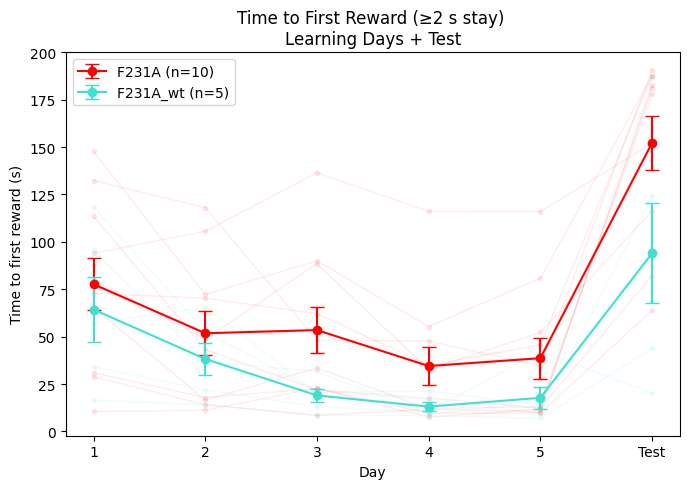

In [59]:
# time to arrive at new reward Ingo Greger animals - F231A vs wt and stayed there for at least 2 sec

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
             ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata['t_to_trigger'] != 0)          # <-- exclude animals/trials with no data yet
].copy()

# Create "plot_day": learning = 1–5, test = 6 (assigned later)
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. Assign FIRST TEST SESSION after the last learning session → plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # this animal has no test day

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect 6 days: L1–L5 + Test
plot_days = np.arange(1, 7)

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean time to first reward per plot_day
        mean_by_day = ms.groupby('plot_day')['t_to_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_F231A = meta_LT[meta_LT['genotype'] == 'F231A']
meta_F231A_wt = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_F231A, subs_F231A = build_genotype_matrix(meta_F231A)
mat_F231A_wt, subs_F231A_wt = build_genotype_matrix(meta_F231A_wt)



# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ---- ChR2 (red) ----
if mat_F231A is not None:
    # individual traces
    for row in mat_F231A:
        plt.plot(x_vals, row / 1000, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    # mean ± SEM
    mean_c = np.nanmean(mat_F231A, axis=0)
    sem_c  = np.nanstd(mat_F231A, axis=0) / np.sqrt(mat_F231A.shape[0])
    plt.errorbar(
        x_vals, mean_c / 1000, yerr=sem_c / 1000,
        fmt='-o', color='red', capsize=5,
        label=f'F231A (n={len(subs_F231A)})'
    )

# ---- eYFP (turquoise) ----
if mat_F231A_wt is not None:
    for row in mat_F231A_wt:
        plt.plot(x_vals, row / 1000, '-o', color='turquoise', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')

    mean_y = np.nanmean(mat_F231A_wt, axis=0)
    sem_y  = np.nanstd(mat_F231A_wt, axis=0) / np.sqrt(mat_F231A_wt.shape[0])
    plt.errorbar(
        x_vals, mean_y / 1000, yerr=sem_y / 1000,
        fmt='-o', color='turquoise', capsize=5,
        label=f'F231A_wt (n={len(subs_F231A_wt)})'
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward (s)')
plt.title('Time to First Reward (≥2 s stay) \nLearning Days + Test')
#(≥2 s stay)
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()




Using: t_to_trigger (all visits)
Groups used for plotting/stats: ['ChR2', 'NAc', 'Control']
Original genotypes loaded: ['CA1_control', 'ChR2', 'NAc', 'NAc_control', 'eYFP_ChR2']
Control pooled from: ['eYFP_ChR2', 'CA1_control', 'NAc_control']

Animals:
  VTA (ChR2)
    animals in dataset: 12
    animals plotted:    12
    ids plotted:        ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc)
    animals in dataset: 7
    animals plotted:    7
    ids plotted:        ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control)
    animals in dataset: 11
    animals plotted:    11
    ids plotted:        ['E (eYFP_ChR2)', 'EE (eYFP_ChR2)', 'EF (eYFP_ChR2)', 'F (eYFP_ChR2)', 'G (eYFP_ChR2)', 'C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']


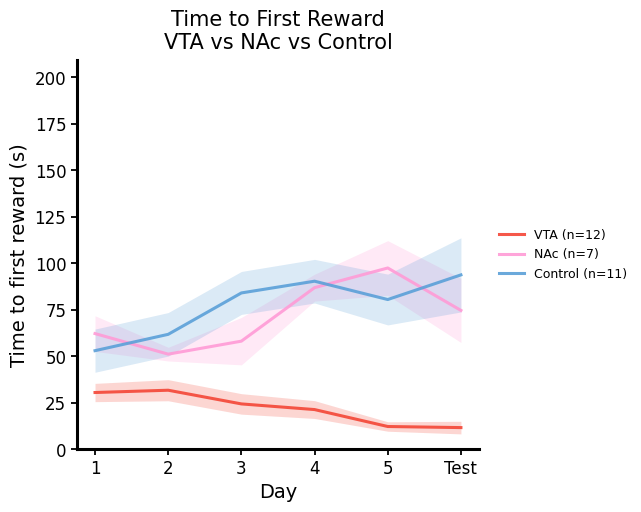


Boxplot: learning days 1-5 average
Using: t_to_trigger (all visits)
Animals plotted:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 11, ids = ['E (eYFP_ChR2)', 'EE (eYFP_ChR2)', 'EF (eYFP_ChR2)', 'F (eYFP_ChR2)', 'G (eYFP_ChR2)', 'C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Per-animal values:
      group  sub                 id     value_s
0      ChR2    1                  A    9.507600
1      ChR2    3                  C   25.916325
2      ChR2    4                  D   26.672350
3      ChR2    6                 AB    9.269800
4      ChR2    7                 AC   13.854125
5      ChR2    8                 AD   36.994225
6      ChR2    9                 AE   42.381100
7      ChR2   10                 AF   44.295225
8      ChR2   11                 AG    6.010500
9

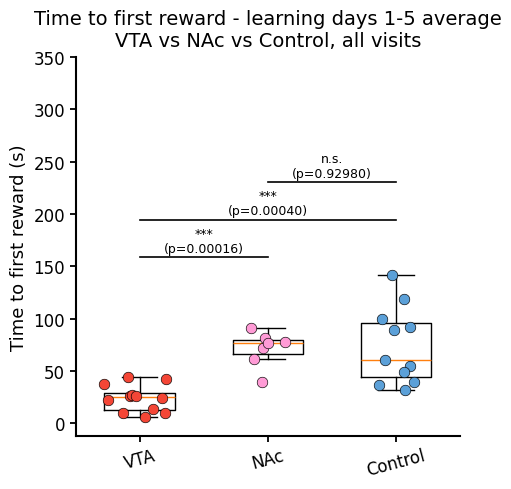


Boxplot: test day
Using: t_to_trigger (all visits)
Animals plotted:
  VTA (ChR2): n = 12, ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  NAc (NAc): n = 7, ids = ['N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7']
  Control (Control): n = 11, ids = ['E (eYFP_ChR2)', 'EE (eYFP_ChR2)', 'EF (eYFP_ChR2)', 'F (eYFP_ChR2)', 'G (eYFP_ChR2)', 'C9 (CA1_control)', 'C10 (CA1_control)', 'C11 (CA1_control)', 'N8 (NAc_control)', 'N9 (NAc_control)', 'N10 (NAc_control)']

Per-animal values:
      group  sub                 id  value_s
0      ChR2    1                  A    5.182
1      ChR2    3                  C    8.237
2      ChR2    4                  D    0.278
3      ChR2    6                 AB    7.985
4      ChR2    7                 AC    4.357
5      ChR2    8                 AD   11.808
6      ChR2    9                 AE   20.986
7      ChR2   10                 AF   42.870
8      ChR2   11                 AG   16.059
9      ChR2   12                 AH    2.218
10 

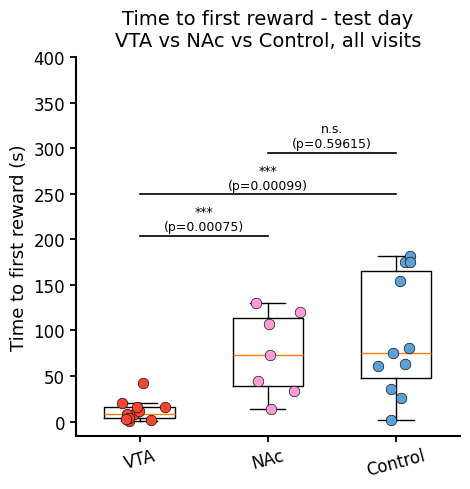

In [172]:
# ============================================================
# Time to first reward across L1-L5 + Test
#
# Adds pooled control group:
#   'Control' = eYFP_ChR2 + CA1_control + NAc_control
#
# Produces:
#   1) Line plot across L1-L5 + Test
#   2) Boxplot: learning days 1-5 average
#   3) Boxplot: test day
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# OPTIONS
# ============================================================
USE_LONG_VISITS = False       # False -> t_to_trigger; True -> t_to_trigger_long
PLOT_INDIVIDUAL = False       # True -> faded individual animal lines
REQUIRE_COMPLETE = False      # True -> only animals with all L1-L5 + Test

SHOW_ANIMAL_IDS = False       # True -> label each dot with animal ID

# Example group choices:
# GROUPS = ['Control']
# GROUPS = ['ChR2', 'Control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']
GROUPS = ['ChR2', 'NAc', 'Control']
# GROUPS = ['ChR2', 'CA1', 'CA3', 'Control']

# These original genotypes will be pooled into genotype == 'Control'
POOLED_CONTROL_ORIGINAL_GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
    'Control': 'Control',
}

EXCLUDE_ID = ['AS', 'AN']
EXCLUDE_SUBS = []

# Use 'all' to compare every group pair
COMPARISONS = 'all'
# Or manually define:
# COMPARISONS = [('ChR2', 'Control'), ('CA1', 'Control')]

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all visits'

# Boxplot dot/stat options
JITTER = 0.12
DOT_SIZE = 58
DOT_EDGE_COLOR = 'black'
DOT_EDGE_WIDTH = 0.45
P_DECIMALS = 5

# p-value line spacing
P_LINE_START_FRAC = 0.12
P_LINE_STEP_FRAC = 0.25
P_TEXT_OFFSET_FRAC = 0.015
P_TOP_PAD_FRAC = 0.25

# y-axis options
LINE_YMIN = 0
LINE_YMAX = None        # None = auto; or set manually, e.g. 200

# For boxplots:
# BOX_YMIN = None means auto negative padding below 0, so tiny values are visible.
# Set BOX_YMIN = 0 if you really want the x-axis exactly at 0.
BOX_YMIN = None
BOX_YMAX = None         # None = auto; or set manually, e.g. 200
BOX_Y_BOTTOM_PAD_FRAC = 0.04   # larger = more space between 0 and x-axis
BOX_Y_TICK_STEP = None         # e.g. 20, 50, 100, or None for auto

np.random.seed(1)

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# Helper functions
# ============================================================
def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=P_DECIMALS):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def get_comparisons(groups, comparisons):
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs
    return comparisons


def get_animal_label(ms, sub):
    """
    Keeps original group visible for pooled Control animals.
    Example: A1 (eYFP_ChR2), N8 (NAc_control), X3 (CA1_control)
    """
    if 'id' in ms.columns and ms['id'].notna().any():
        animal_id = str(ms['id'].dropna().iloc[0])
    else:
        animal_id = str(sub)

    if 'genotype_original' in ms.columns and ms['genotype'].iloc[0] == 'Control':
        original = str(ms['genotype_original'].dropna().iloc[0])
        return f'{animal_id} ({original})'

    return animal_id


def style_nature(ax, linewidth=2.0):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(linewidth)
    ax.spines['left'].set_linewidth(linewidth)
    ax.tick_params(direction='out', length=4, width=1.3)
    ax.grid(False)


def apply_box_y_axis(ax, y_top):
    """
    Boxplot y-axis:
      - actual lower limit is slightly below 0
      - tick labels start at 0
      - this makes very low positive values visible above the x-axis
    """
    if not np.isfinite(y_top) or y_top <= 0:
        y_top = 1.0

    if BOX_YMAX is not None:
        y_top = BOX_YMAX

    if BOX_YMIN is not None:
        y_bottom = BOX_YMIN
    else:
        y_bottom = -BOX_Y_BOTTOM_PAD_FRAC * y_top

    ax.set_ylim(y_bottom, y_top)

    if BOX_Y_TICK_STEP is not None:
        yticks = np.arange(0, y_top + BOX_Y_TICK_STEP, BOX_Y_TICK_STEP)
        ax.set_yticks(yticks)
    else:
        ticks = ax.get_yticks()
        ticks = ticks[ticks >= 0]
        if len(ticks) == 0 or ticks[0] != 0:
            ticks = np.insert(ticks, 0, 0)
        ax.set_yticks(ticks)


def assign_learning_and_test_days(meta_df):
    """
    Assign:
      L trial_type_day 1-5 -> plot_day 1-5
      first T session after last L session -> plot_day 6
    """
    meta_df = meta_df.copy()
    meta_df['plot_day'] = np.nan

    mask_L = meta_df['trial_type'] == 'L'
    meta_df.loc[mask_L, 'plot_day'] = meta_df.loc[mask_L, 'trial_type_day']

    meta_df = meta_df[
        (~mask_L) | (meta_df['trial_type_day'].isin([1, 2, 3, 4, 5]))
    ].copy()

    for sub in meta_df['sub'].unique():
        ms = meta_df[meta_df['sub'] == sub]

        L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
        if len(L_ses) == 0:
            continue

        last_L_ses = L_ses.max()

        T_after = ms[
            (ms['trial_type'] == 'T') &
            (ms['ses'] > last_L_ses)
        ]

        if len(T_after) == 0:
            continue

        first_T_ses = T_after['ses'].min()

        idx = meta_df.index[
            (meta_df['sub'] == sub) &
            (meta_df['trial_type'] == 'T') &
            (meta_df['ses'] == first_T_ses)
        ]

        meta_df.loc[idx, 'plot_day'] = 6

    meta_df = meta_df[meta_df['plot_day'].isin(plot_days)].copy()

    return meta_df


def build_genotype_matrix(meta_group, value_col):
    """
    Build animal x day matrix.
    One row = one animal.
    Columns = L1, L2, L3, L4, L5, Test.
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    meta_group = meta_group[meta_group[value_col].notna()].copy()

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)
        animal_ids.append(get_animal_label(ms, sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids


def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem


def values_from_matrix(g, mode):
    """
    Uses the exact same matrix as the line plot.

    mode:
      'learning_mean' -> mean of days 1-5 = mat[:, 0:5]
      'test'          -> test day = mat[:, 5]
    """
    mat = group_data[g]['mat']
    subs = group_data[g]['subs']
    ids = group_data[g]['ids']

    if mat is None or len(subs) == 0:
        return pd.DataFrame(columns=['sub', 'id', 'value_s'])

    rows = []

    for i, sub in enumerate(subs):
        row = mat[i, :]

        if mode == 'learning_mean':
            value_ms = np.nanmean(row[0:5])
        elif mode == 'test':
            value_ms = row[5]
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if not np.isfinite(value_ms):
            continue

        rows.append({
            'sub': sub,
            'id': ids[i],
            'value_s': float(value_ms) / 1000.0
        })

    return pd.DataFrame(rows)


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + P_TEXT_OFFSET_FRAC * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})" if np.isfinite(p) else "p = NaN",
        ha='center',
        va='bottom',
        fontsize=9
    )


# ============================================================
# 1) Prepare metadata with pooled Control
# ============================================================
groups_to_load = []
for g in GROUPS:
    if g == 'Control':
        groups_to_load.extend(POOLED_CONTROL_ORIGINAL_GROUPS)
    else:
        groups_to_load.append(g)

groups_to_load = sorted(set(groups_to_load))

meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(groups_to_load)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

meta_LT['genotype_original'] = meta_LT['genotype']

if 'Control' in GROUPS:
    meta_LT.loc[
        meta_LT['genotype_original'].isin(POOLED_CONTROL_ORIGINAL_GROUPS),
        'genotype'
    ] = 'Control'

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

meta_LT = assign_learning_and_test_days(meta_LT)

print("\nUsing:", TIME_COL, f"({STAY_TAG})")
print("Groups used for plotting/stats:", GROUPS)
print("Original genotypes loaded:", groups_to_load)
if 'Control' in GROUPS:
    print("Control pooled from:", POOLED_CONTROL_ORIGINAL_GROUPS)

# ============================================================
# 2) Build group matrices
# ============================================================
group_data = {}

print("\nAnimals:")
for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g, ids_g = build_genotype_matrix(meta_g, TIME_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
        'ids': ids_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g})")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    ids plotted:        {ids_g}")

# ============================================================
# 3) Line plot: L1-L5 + Test
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5.5))

def plot_group_shaded(
    ax,
    mat,
    subs,
    genotype_key,
    label,
    alpha_fill=0.22,
    alpha_line=0.9,
    alpha_individual=0.12
):
    if mat is None or len(subs) == 0:
        return

    col = get_genotype_color(genotype_key)

    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row / 1000.0,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms = sem_by_day(mat)

    mean_s = mean_ms / 1000.0
    sem_s = sem_ms / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )


for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Time to first reward (s)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

style_nature(ax, linewidth=2.2)

title = 'Time to First Reward'
if USE_LONG_VISITS:
    title += ' (≥2 s stay)'

display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])
ax.set_title(
    f'{title}\n{display_groups}',
    fontsize=15,
    pad=8
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5)
)

if LINE_YMAX is not None:
    ax.set_ylim(LINE_YMIN, LINE_YMAX)
else:
    all_mats = [
        group_data[g]['mat']
        for g in GROUPS
        if group_data[g]['mat'] is not None
    ]

    if len(all_mats) > 0:
        all_vals_s = np.concatenate([
            m[np.isfinite(m)].ravel() / 1000.0
            for m in all_mats
            if np.any(np.isfinite(m))
        ])

        if len(all_vals_s) > 0:
            ymax = np.nanmax(all_vals_s)
            ax.set_ylim(LINE_YMIN, ymax * 1.15)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

# ============================================================
# 4) Boxplot helper
# ============================================================
def plot_boxplot_from_matrix(mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = values_from_matrix(g, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value_s'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Using: {TIME_COL} ({STAY_TAG})")
    print("Animals plotted:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    print("\nPer-animal values:")
    meta_animal = pd.concat(
        [
            group_dfs[g].assign(group=g)
            for g in GROUPS
            if len(group_dfs[g]) > 0
        ],
        ignore_index=True
    ) if any(len(group_dfs[g]) > 0 for g in GROUPS) else pd.DataFrame()

    if len(meta_animal) > 0:
        print(meta_animal[['group', 'sub', 'id', 'value_s']])
    else:
        print("No data.")

    fig, ax = plt.subplots(figsize=(max(4.8, 1.4 * len(GROUPS)), 5))

    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    for i, g in enumerate(GROUPS):
        df_g = group_dfs[g]
        vals = df_g['value_s'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=DOT_SIZE,
            color=get_genotype_color(g),
            edgecolor=DOT_EDGE_COLOR,
            linewidth=DOT_EDGE_WIDTH,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)
    stats_to_draw = []

    print("\nMann–Whitney U tests:")
    for g1, g2 in comparisons_to_run:
        if g1 not in GROUPS or g2 not in GROUPS:
            print(
                f"  Skipping {DISPLAY_NAME.get(g1, g1)} vs "
                f"{DISPLAY_NAME.get(g2, g2)}: group not in GROUPS"
            )
            continue

        vals1 = group_dfs[g1]['value_s'].values.astype(float)
        vals2 = group_dfs[g2]['value_s'].values.astype(float)

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={len(vals1)} vs {len(vals2)}, "
                f"U={stat:.1f}, p={format_p(p)}"
            )
        else:
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"p = NaN"
            )

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        current_y = ymax + P_LINE_START_FRAC * yrng
        y_step = P_LINE_STEP_FRAC * yrng

        for x1, x2, p in stats_to_draw:
            draw_sig_bar(ax, x1, x2, current_y, p, yrng)
            current_y += y_step

        y_top_auto = current_y + P_TOP_PAD_FRAC * yrng

        apply_box_y_axis(ax, y_top_auto)

    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=12,
        rotation=15
    )

    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax, linewidth=1.5)

    display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

    ax.set_title(
        f'Time to first reward - {title_suffix}\n{display_groups}, {STAY_TAG}',
        fontsize=14,
        pad=8
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 5) Produce boxplots
# ============================================================
plot_boxplot_from_matrix(
    mode='learning_mean',
    title_suffix='learning days 1-5 average'
)

plot_boxplot_from_matrix(
    mode='test',
    title_suffix='test day'
)

Using: t_to_trigger_long
Groups: ['eYFP_ChR2', 'CA1_control', 'NAc_control']

Animals:
  VTA control (eYFP_ChR2)
    animals in dataset: 5
    animals plotted:    5
    subjects plotted:   [np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
  CA1 control (CA1_control)
    animals in dataset: 3
    animals plotted:    3
    subjects plotted:   [np.int64(79), np.int64(80), np.int64(81)]
  NAc control (NAc_control)
    animals in dataset: 3
    animals plotted:    3
    subjects plotted:   [np.int64(87), np.int64(88), np.int64(89)]


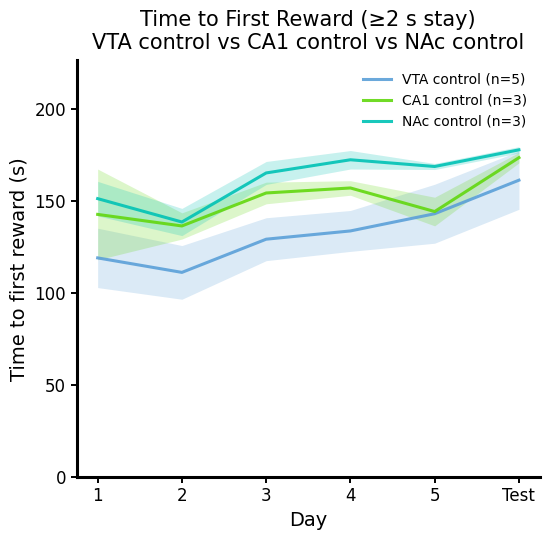

In [152]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Time to first reward across L1-L5 + Test
# Flexible group comparison
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
USE_LONG_VISITS = True       # False -> t_to_trigger; True -> t_to_trigger_long
PLOT_INDIVIDUAL = False      # True -> faded individual animal lines
REQUIRE_COMPLETE = False     # True -> only animals with all L1-L5 + Test
EXCLUDE_ID = ['AS','AN']          # manually exclude subjects; use [] for none

# Define groups directly here.
# These names must match metadata['genotype'].
# GROUPS = ['ChR2', 'eYFP_ChR2', 'ChR2_short']
GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA1_control']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']
# GROUPS = ['ChR2', 'CA1', 'eYFP_ChR2']

# Display names for legend/title
DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
}

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all entries'

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ---------------------------------------------------------------------
# 1. Filter metadata
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GROUPS)) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# optional exclusions
if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

# Create plot_day: learning = 1–5, test = 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep learning days 1–5 only
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# ---------------------------------------------------------------------
# 1b. Assign first test session after last learning session -> day 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ---------------------------------------------------------------------
# 2. Build genotype matrix
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group, value_col):
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')[value_col].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


group_data = {}

print("Using:", TIME_COL)
print("Groups:", GROUPS)
print("\nAnimals:")

for g in GROUPS:
    meta_g = meta_LT[meta_LT['genotype'] == g].copy()
    mat_g, subs_g = build_genotype_matrix(meta_g, TIME_COL)

    group_data[g] = {
        'meta': meta_g,
        'mat': mat_g,
        'subs': subs_g,
    }

    print(f"  {DISPLAY_NAME.get(g, g)} ({g})")
    print(f"    animals in dataset: {meta_g['sub'].nunique()}")
    print(f"    animals plotted:    {len(subs_g)}")
    print(f"    subjects plotted:   {subs_g}")

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.6, 5.5))

def plot_group_shaded(ax, mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9,
                      alpha_individual=0.12):
    if mat is None or len(subs) == 0:
        return

    col = get_genotype_color(genotype_key)

    # individual animal traces
    if PLOT_INDIVIDUAL:
        for row in mat:
            ax.plot(
                x_vals,
                row / 1000.0,
                '-',
                color=col,
                alpha=alpha_individual,
                linewidth=1.0,
                label='_nolegend_',
                zorder=1
            )

    # mean ± SEM
    mean_ms = np.nanmean(mat, axis=0)

    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_ms = np.nanstd(mat, axis=0) / np.sqrt(n_per_day)
    sem_ms[n_per_day <= 1] = 0

    mean_s = mean_ms / 1000.0
    sem_s = sem_ms / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=col,
        alpha=alpha_fill,
        linewidth=0,
        zorder=2
    )

    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})',
        zorder=3
    )

for g in GROUPS:
    plot_group_shaded(
        ax,
        group_data[g]['mat'],
        group_data[g]['subs'],
        genotype_key=g,
        label=DISPLAY_NAME.get(g, g)
    )

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
ax.set_xlabel('Day', fontsize=14)
ax.set_ylabel('Time to first reward (s)', fontsize=14)

ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=4, width=1.4)

title = 'Time to First Reward'
if USE_LONG_VISITS:
    title += ' (≥2 s stay)'

display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])
ax.set_title(
    f'{title}\n{display_groups}',
    fontsize=15,
    pad=8
)

ax.legend(frameon=False)

# ---------------------------------------------------------------------
# Auto y-limit
# ---------------------------------------------------------------------
all_mats = [
    group_data[g]['mat']
    for g in GROUPS
    if group_data[g]['mat'] is not None
]

if len(all_mats) > 0:
    all_vals_s = np.concatenate([
        m[np.isfinite(m)].ravel() / 1000.0
        for m in all_mats
        if np.any(np.isfinite(m))
    ])

    if len(all_vals_s) > 0:
        ymax = np.nanmax(all_vals_s)
        ax.set_ylim(0, ymax * 1.15)

plt.tight_layout()
plt.show()

Using: t_to_trigger_long (≥2 s stay)
VTA short animals plotted: n = 8
Animal IDs: ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']


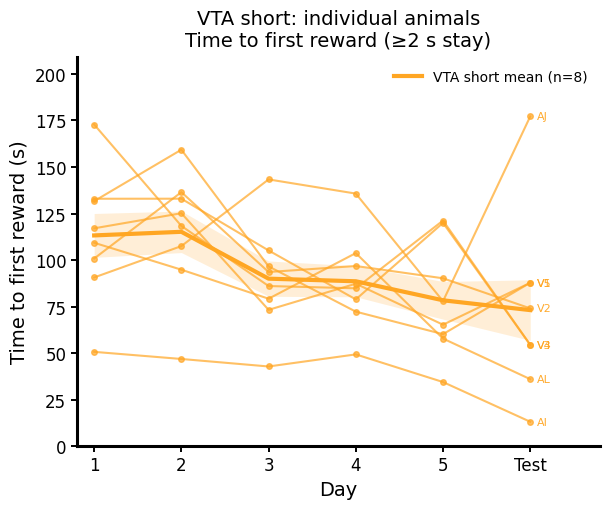

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Individual animal lines: ChR2_short
# Time to first reward across L1-L5 + Test
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
USE_LONG_VISITS = True        # False -> t_to_trigger ; True -> t_to_trigger_long
REQUIRE_COMPLETE = False      # True -> only animals with all L1-L5 + Test
EXCLUDE_ID = ['AS', 'AN']     # manually exclude animals by id; use [] for none
SHOW_ANIMAL_IDS = True        # label each animal line
SHOW_GROUP_MEAN = True        # overlay group mean ± SEM

GROUP_TO_PLOT = 'ChR2_short'

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
}

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all entries'

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ------------------------------------------------------------
# 1. Filter metadata
# ------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'] == GROUP_TO_PLOT) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

# ------------------------------------------------------------
# 2. Assign plot_day: learning = 1–5, first post-learning test = 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep learning days 1–5 only
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 3. Build animal × day matrix
# ------------------------------------------------------------
rows = []
subs = []
animal_ids = []

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub].copy()

    mean_by_day = ms.groupby('plot_day')[TIME_COL].mean()

    vals = np.array(
        [mean_by_day.get(d, np.nan) for d in plot_days],
        dtype=float
    )

    if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
        continue

    if np.all(np.isnan(vals)):
        continue

    rows.append(vals)
    subs.append(sub)

    if 'id' in ms.columns and ms['id'].notna().any():
        animal_ids.append(str(ms['id'].dropna().iloc[0]))
    else:
        animal_ids.append(str(sub))

if len(rows) == 0:
    print(f"No animals found for {GROUP_TO_PLOT} using {TIME_COL}.")
else:
    mat = np.vstack(rows)

    print("Using:", TIME_COL, f"({STAY_TAG})")
    print(f"{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} animals plotted: n = {len(subs)}")
    print("Animal IDs:", animal_ids)

    # --------------------------------------------------------
    # 4. Plot individual animal lines clearly
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    col = get_genotype_color(GROUP_TO_PLOT)

    for i, row in enumerate(mat):
        y = row / 1000.0

        ax.plot(
            x_vals,
            y,
            '-o',
            color=col,
            alpha=0.70,
            linewidth=1.5,
            markersize=4,
            zorder=2
        )

        if SHOW_ANIMAL_IDS:
            finite_idx = np.where(np.isfinite(y))[0]
            if len(finite_idx) > 0:
                last_i = finite_idx[-1]
                ax.text(
                    x_vals[last_i] + 0.08,
                    y[last_i],
                    animal_ids[i],
                    fontsize=8,
                    color=col,
                    alpha=0.95,
                    ha='left',
                    va='center'
                )

    # --------------------------------------------------------
    # Optional group mean ± SEM
    # --------------------------------------------------------
    if SHOW_GROUP_MEAN:
        mean_ms = np.nanmean(mat, axis=0)

        n_per_day = np.sum(~np.isnan(mat), axis=0)
        sem_ms = np.nanstd(mat, axis=0) / np.sqrt(n_per_day)
        sem_ms[n_per_day <= 1] = 0

        mean_s = mean_ms / 1000.0
        sem_s = sem_ms / 1000.0

        ax.fill_between(
            x_vals,
            mean_s - sem_s,
            mean_s + sem_s,
            color=col,
            alpha=0.18,
            linewidth=0,
            zorder=1
        )

        ax.plot(
            x_vals,
            mean_s,
            '-',
            color=col,
            linewidth=3.0,
            alpha=1.0,
            label=f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)} mean (n={len(subs)})',
            zorder=4
        )

    # --------------------------------------------------------
    # Axes + style
    # --------------------------------------------------------
    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=4, width=1.4)

    ax.set_title(
        f'{DISPLAY_NAME.get(GROUP_TO_PLOT, GROUP_TO_PLOT)}: individual animals\n'
        f'Time to first reward ({STAY_TAG})',
        fontsize=14,
        pad=8
    )

    if SHOW_GROUP_MEAN:
        ax.legend(frameon=False)

    # auto y-limit
    all_vals_s = mat[np.isfinite(mat)].ravel() / 1000.0
    if len(all_vals_s) > 0:
        ymax = np.nanmax(all_vals_s)
        ax.set_ylim(0, ymax * 1.18)

    # leave space for labels
    if SHOW_ANIMAL_IDS:
        ax.set_xlim(-0.2, 5.8)
    else:
        ax.set_xlim(-0.2, 5.2)

    plt.tight_layout()
    plt.show()


Boxplot: learning days 1-5 average
Using: t_to_trigger_long (≥2 s stay)
Animals plotted:
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']
  NAc control (NAc_control): n = 3, ids = ['N8', 'N9', 'N10']
Mann–Whitney U tests:
  VTA control vs CA1 control: n=5 vs 3, U=4.0, p=0.39286
  VTA control vs NAc control: n=5 vs 3, U=2.0, p=0.14286
  CA1 control vs NAc control: n=3 vs 3, U=2.0, p=0.40000


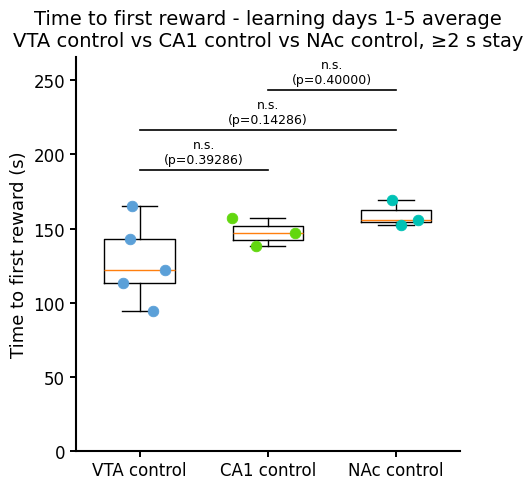


Boxplot: test day
Using: t_to_trigger_long (≥2 s stay)
Animals plotted:
  VTA control (eYFP_ChR2): n = 5, ids = ['E', 'EE', 'EF', 'F', 'G']
  CA1 control (CA1_control): n = 3, ids = ['C9', 'C10', 'C11']
  NAc control (NAc_control): n = 3, ids = ['N8', 'N9', 'N10']
Mann–Whitney U tests:
  VTA control vs CA1 control: n=5 vs 3, U=9.0, p=0.78571
  VTA control vs NAc control: n=5 vs 3, U=8.0, p=1.00000
  CA1 control vs NAc control: n=3 vs 3, U=3.0, p=0.70000


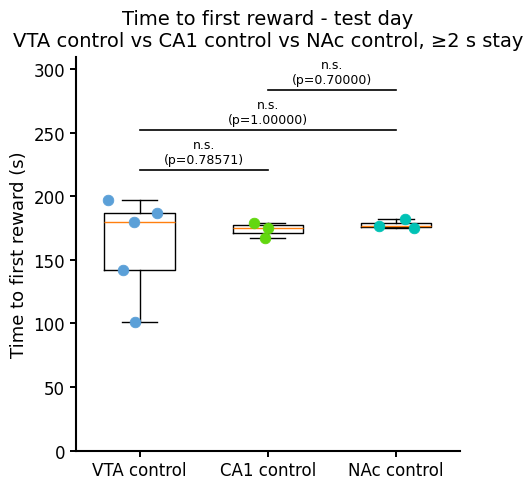

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================================================
# Time to first reward boxplots:
#   1) Learning days 1-5 average
#   2) Test day
#
# Stats: Mann–Whitney U / rank-sum test
# ============================================================

# ------------------------------------------------------------
# OPTIONS
# ------------------------------------------------------------
USE_LONG_VISITS = True       # False -> t_to_trigger ; True -> t_to_trigger_long
SHOW_ANIMAL_IDS = False      # True -> label each dot with animal ID

GROUPS = ['eYFP_ChR2', 'CA1_control', 'NAc_control']
# GROUPS = ['ChR2', 'ChR2_short', 'eYFP_ChR2']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA3']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'CA1_control']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
    'CA1': 'CA1',
    'CA3': 'CA3',
    'CA1_control': 'CA1 control',
}

# Use 'all' to compare every group pair
COMPARISONS = 'all'

# Or manually define:
# COMPARISONS = [
#     ('ChR2', 'eYFP_ChR2'),
#     ('ChR2_short', 'eYFP_ChR2'),
#     ('ChR2_short', 'ChR2'),
# ]

EXCLUDE_ID = ['AS', 'AN']    # use [] for none
EXCLUDE_SUBS = []            # e.g. [43]

TIME_COL = 't_to_trigger_long' if USE_LONG_VISITS else 't_to_trigger'
STAY_TAG = '≥2 s stay' if USE_LONG_VISITS else 'all visits'

JITTER = 0.12
np.random.seed(1)

plot_days = np.arange(1, 7)

# ============================================================
# 1) Prepare metadata
# ============================================================
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(GROUPS)) &
    (metadata['trial_type'].isin(['L', 'T'])) &
    (metadata[TIME_COL].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    meta_LT = meta_LT[
        ~meta_LT['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    meta_LT = meta_LT[
        ~meta_LT['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ------------------------------------------------------------
# Assign plot_day: L1-L5 + first post-learning Test = day 6
# ------------------------------------------------------------
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# keep learning days 1-5 only
meta_LT = meta_LT[
    (~mask_L) | (meta_LT['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]

    meta_LT.loc[idx, 'plot_day'] = 6

meta_LT = meta_LT[meta_LT['plot_day'].isin(plot_days)].copy()

# ============================================================
# 2) Helpers
# ============================================================
def p_to_stars(p):
    if not np.isfinite(p):
        return "n.s."
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def format_p(p, decimals=5):
    if not np.isfinite(p):
        return "NaN"
    return f"{p:.{decimals}f}"


def get_animal_values(meta_LT, genotype, value_col, mode):
    """
    mode:
      'learning_mean' -> one value per animal = mean over plot_day 1-5
      'test'          -> one value per animal = mean over plot_day 6

    returns:
      DataFrame with sub, id, value_s
    """
    md = meta_LT[
        (meta_LT['genotype'] == genotype) &
        (meta_LT[value_col].notna())
    ].copy()

    rows = []

    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub].copy()

        if mode == 'learning_mean':
            ms_use = ms[ms['plot_day'].isin([1, 2, 3, 4, 5])].copy()
        elif mode == 'test':
            ms_use = ms[ms['plot_day'] == 6].copy()
        else:
            raise ValueError("mode must be 'learning_mean' or 'test'")

        if len(ms_use) == 0:
            continue

        val_ms = np.nanmean(ms_use[value_col].values.astype(float))

        if not np.isfinite(val_ms):
            continue

        if 'id' in ms_use.columns and ms_use['id'].notna().any():
            animal_id = str(ms_use['id'].dropna().iloc[0])
        else:
            animal_id = str(sub)

        rows.append({
            'sub': sub,
            'id': animal_id,
            'value_s': val_ms / 1000.0
        })

    return pd.DataFrame(rows)


def get_comparisons(groups, comparisons):
    """
    If comparisons == 'all', create all pairwise group comparisons.
    Otherwise use the manually defined list.
    """
    if comparisons == 'all':
        pairs = []
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                pairs.append((groups[i], groups[j]))
        return pairs

    return comparisons


def draw_sig_bar(ax, x1, x2, y, p, yrng):
    # simple horizontal line, no downward edges
    ax.plot(
        [x1, x2],
        [y, y],
        color='black',
        linewidth=1.2
    )

    ax.text(
        (x1 + x2) / 2,
        y + 0.015 * yrng,
        f"{p_to_stars(p)}\n(p={format_p(p)})" if np.isfinite(p) else "p = NaN",
        ha='center',
        va='bottom',
        fontsize=9
    )


def plot_boxplot_for_mode(meta_LT, mode, title_suffix):
    group_dfs = {}
    vals_groups = []

    for g in GROUPS:
        df_g = get_animal_values(meta_LT, g, TIME_COL, mode)
        group_dfs[g] = df_g
        vals_groups.append(df_g['value_s'].values.astype(float))

    print("\n============================================================")
    print(f"Boxplot: {title_suffix}")
    print(f"Using: {TIME_COL} ({STAY_TAG})")
    print("Animals plotted:")

    for g in GROUPS:
        print(
            f"  {DISPLAY_NAME.get(g, g)} ({g}): "
            f"n = {len(group_dfs[g])}, ids = {list(group_dfs[g]['id'])}"
        )

    fig, ax = plt.subplots(figsize=(max(4.8, 1.4 * len(GROUPS)), 5))

    # -----------------------------
    # Boxplot
    # -----------------------------
    ax.boxplot(
        vals_groups,
        positions=np.arange(len(GROUPS)),
        widths=0.55,
        patch_artist=False,
        showfliers=False
    )

    # -----------------------------
    # Jittered dots
    # -----------------------------
    for i, g in enumerate(GROUPS):
        df_g = group_dfs[g]
        vals = df_g['value_s'].values.astype(float)

        if len(vals) == 0:
            continue

        x = np.random.normal(i, JITTER, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=58,
            color=get_genotype_color(g),
            linewidth=0.6,
            zorder=3
        )

        if SHOW_ANIMAL_IDS:
            for xi, yi, animal_id in zip(x, vals, df_g['id'].values):
                ax.text(
                    xi + 0.04,
                    yi,
                    str(animal_id),
                    fontsize=7,
                    color=get_genotype_color(g),
                    ha='left',
                    va='center',
                    alpha=0.9,
                    zorder=4
                )

    # -----------------------------
    # Mann–Whitney U tests
    # -----------------------------
    comparisons_to_run = get_comparisons(GROUPS, COMPARISONS)

    stats_to_draw = []

    print("Mann–Whitney U tests:")
    for g1, g2 in comparisons_to_run:
        if g1 not in GROUPS or g2 not in GROUPS:
            print(
                f"  Skipping {DISPLAY_NAME.get(g1, g1)} vs "
                f"{DISPLAY_NAME.get(g2, g2)}: group not in GROUPS"
            )
            continue

        vals1 = group_dfs[g1]['value_s'].values.astype(float)
        vals2 = group_dfs[g2]['value_s'].values.astype(float)

        if len(vals1) > 0 and len(vals2) > 0:
            stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')
        else:
            stat, p = np.nan, np.nan

        if np.isfinite(p):
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"n={len(vals1)} vs {len(vals2)}, "
                f"U={stat:.1f}, p={format_p(p)}"
            )
        else:
            print(
                f"  {DISPLAY_NAME.get(g1, g1)} vs {DISPLAY_NAME.get(g2, g2)}: "
                f"p = NaN"
            )

        if np.isfinite(p):
            x1 = GROUPS.index(g1)
            x2 = GROUPS.index(g2)
            stats_to_draw.append((x1, x2, p))

    # -----------------------------
    # Draw significance bars
    # -----------------------------
    nonempty_vals = [v for v in vals_groups if len(v) > 0]

    if len(nonempty_vals) > 0:
        all_vals = np.concatenate(nonempty_vals)
        ymax = np.nanmax(all_vals)
        yrng = ymax if ymax > 0 else 1.0

        for k, (x1, x2, p) in enumerate(stats_to_draw):
            y = ymax + (0.12 + 0.16 * k) * yrng
            draw_sig_bar(ax, x1, x2, y, p, yrng)

        ax.set_ylim(
            0,
            ymax + (0.45 + 0.12 * max(0, len(stats_to_draw) - 2)) * yrng
        )

    # -----------------------------
    # Axes / labels / style
    # -----------------------------
    ax.set_ylabel('Time to first reward (s)', fontsize=13)

    ax.set_xticks(np.arange(len(GROUPS)))
    ax.set_xticklabels(
        [DISPLAY_NAME.get(g, g) for g in GROUPS],
        fontsize=12
    )

    ax.tick_params(axis='y', labelsize=12)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(direction='out', width=1.4, length=4)

    display_groups = ' vs '.join([DISPLAY_NAME.get(g, g) for g in GROUPS])

    ax.set_title(
        f'Time to first reward - {title_suffix}\n{display_groups}, {STAY_TAG}',
        fontsize=14,
        pad=8
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 3) Produce the two boxplots
# ============================================================
plot_boxplot_for_mode(
    meta_LT,
    mode='learning_mean',
    title_suffix='learning days 1-5 average'
)

plot_boxplot_for_mode(
    meta_LT,
    mode='test',
    title_suffix='test day'
)

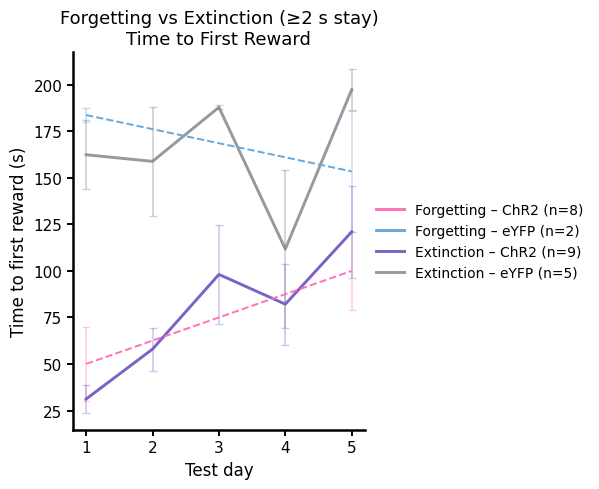

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---- 1. Restrict to TEST trials, desired genotypes, and NOT short_duration ----
meta_T = metadata[
    (metadata['trial_type'] == 'T') &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['short_duration'] != 1) &
    (metadata['t_to_trigger'].notna())
].copy()

max_day = 5
day_values = np.arange(1, max_day + 1)


# ---- 2. Build subject × test-day matrix (TIME TO FIRST REWARD) ----
def build_subject_matrix(meta_group):
    """
    For each subject, compute mean time-to-first-reward (t_to_trigger)
    for each test day (trial_type_day = 1..5).
    Returns matrix: n_subjects x max_day (values in ms).
    """
    performance_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        m = meta_group[meta_group['sub'] == sub]

        # average per test day for this subject
        mean_d = m.groupby('trial_type_day')['t_to_trigger'].mean()

        vec = np.full(max_day, np.nan)
        for i, d in enumerate(day_values):
            if d in mean_d.index:
                vec[i] = mean_d.loc[d]

        if np.isnan(vec).all():
            continue

        performance_mat.append(vec)
        subjects.append(sub)

    if len(performance_mat) == 0:
        return None, []

    return np.vstack(performance_mat), subjects


def mean_and_sem(mat):
    """
    Robust mean/SEM:
    - returns NaN for days where all animals are NaN
    - avoids RuntimeWarnings from nanmean / nanstd
    """
    if mat is None or mat.size == 0:
        return None, None

    n_days = mat.shape[1]
    mean = np.full(n_days, np.nan)
    sem  = np.full(n_days, np.nan)

    for j in range(n_days):
        col = mat[:, j]
        valid = ~np.isnan(col)
        n = valid.sum()
        if n == 0:
            continue
        mean[j] = col[valid].mean()
        if n > 1:
            sem[j] = col[valid].std(ddof=1) / np.sqrt(n)

    return mean, sem


# ---- 3. Split by genotype × test_type ----
meta_ChR2 = meta_T[meta_T['genotype'] == 'ChR2']
meta_YFP  = meta_T[meta_T['genotype'] == 'eYFP_ChR2']

# forgetting
perf_f_ChR2, subs_f_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'forgetting']
)
perf_f_YFP,  subs_f_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'forgetting']
)

# extinction
perf_e_ChR2, subs_e_ChR2 = build_subject_matrix(
    meta_ChR2[meta_ChR2['test_type'] == 'extinction']
)
perf_e_YFP,  subs_e_YFP  = build_subject_matrix(
    meta_YFP[meta_YFP['test_type'] == 'extinction']
)


# ---- 4. Plot TIME TO FIRST REWARD ----
plt.figure(figsize=(7.5, 5))

col_f_ChR2 = "#FF72B8"   # pink (forgetting)
col_e_ChR2 = '#7b62c5ff'   # pastel purple (extinction)
col_f_YFP  = "#65a8deff"
col_e_YFP  = "#76787EC1"


def plot_group(mat, color, label):
    """
    Plot mean ± faded SEM for one group.
    mat is in ms → convert to s when plotting.
    """
    if mat is None or mat.size == 0:
        return
    mean_ms, sem_ms = mean_and_sem(mat)
    if mean_ms is None:
        return

    mean = mean_ms / 1000.0
    sem  = sem_ms / 1000.0

    # mean line
    plt.plot(
        day_values, mean,
        '-', color=color,
        linewidth=2.1,
        label=label
    )

    # faded SEM
    plt.errorbar(
        day_values, mean, yerr=sem,
        fmt='none',
        ecolor=color,
        alpha=0.35,
        elinewidth=1.2,
        capsize=3
    )


def plot_forgetting_trend(mat, color):
    """
    Optional dashed line from Day1 → Day5 for forgetting groups.
    """
    if mat is None or mat.size == 0:
        return
    mean_ms, _ = mean_and_sem(mat)
    if mean_ms is None:
        return

    mean = mean_ms / 1000.0
    if np.isnan(mean[0]) or np.isnan(mean[-1]):
        return

    plt.plot(
        [day_values[0], day_values[-1]],
        [mean[0], mean[-1]],
        '--',
        color=color,
        alpha=1,
        linewidth=1.4
    )


# forgetting
plot_group(perf_f_ChR2, col_f_ChR2, f'Forgetting – ChR2 (n={len(subs_f_ChR2)})')
plot_group(perf_f_YFP,  col_f_YFP,  f'Forgetting – eYFP (n={len(subs_f_YFP)})')

# extinction
plot_group(perf_e_ChR2, col_e_ChR2, f'Extinction – ChR2 (n={len(subs_e_ChR2)})')
plot_group(perf_e_YFP,  col_e_YFP,  f'Extinction – eYFP (n={len(subs_e_YFP)})')

# optional dashed trend for forgetting groups
plot_forgetting_trend(perf_f_ChR2, col_f_ChR2)
plot_forgetting_trend(perf_f_YFP,  col_f_YFP)


# ---- Axes: publication style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(day_values, [str(d) for d in day_values], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Forgetting vs Extinction (≥2 s stay)\nTime to First Reward', fontsize=13, pad=6)
# (≥2 s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()

In [125]:
# COMPUTE time to arrive for each trigger separately
# ----- COMPUTE TIME TO TRIGGER (ANY) + PER-TRIGGER TIMES -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # only recruit usable trials

# ------------------------------------------------------------------
# OPTION: minimum dwell time in trigger zone (in ms)
#   - 2000 → must stay ≥ 2 s
#   - 0    → any entry counts
# ------------------------------------------------------------------
DWELL_MIN_MS = 0   # <--- change here if you want to relax/tighten criterion

# Define columns in metadata
metadata['t_to_trigger'] = 0        # time to first trigger (any trigger) meeting criterion
metadata['learned']      = False      # ever met criterion in any trigger?

R_TRIGGER = (10/1.2)  # radius defining trigger zone

# store per-trigger times here
trigger_rows = []  # each row: {trial_id, trigger_id, t_to_trigger_trig}

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue

    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(
            position_,
            R_TRIGGER,
            ti=i+1
        )
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

        # per-trigger: if we know nothing, set all triggers to trial duration
        for trig_id in range(1, trigger_num + 1):
            trigger_rows.append({
                'trial_id': trial_id,
                'trigger_id': trig_id,
                't_to_trigger_trig': t_to_trigger
            })
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    
    # ------------------------------------------------------------------
    # Apply dwell-time criterion here ONLY
    # ------------------------------------------------------------------
    if DWELL_MIN_MS > 0:
        df_all_triggers_long = df_all_triggers[df_all_triggers['duration'] >= DWELL_MIN_MS]
    else:
        df_all_triggers_long = df_all_triggers

    # ---- original "first reward anywhere" metric ----
    if len(df_all_triggers_long) == 0:
        # never met criterion in any trigger → use trial duration
        t_to_trigger = position_.iloc[-1]['t']
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

    # ---- per-trigger times (first entry meeting criterion in each trigger) ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers_long[df_all_triggers_long['trigger_id'] == trig_id]
        if len(df_t) == 0:
            # never met criterion in THIS trigger → use trial duration
            t_trig = position_.iloc[-1]['t']
        else:
            t_trig = df_t.iloc[0]['t_enter']

        trigger_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            't_to_trigger_trig': t_trig
        })

# Build long-format per-trigger DataFrame and attach metadata columns
df_trig = pd.DataFrame(trigger_rows)

meta_trig = df_trig.merge(
    metadata,
    left_on='trial_id',   # integer from the loop
    right_index=True,     # metadata index 0..len-1
    how='left'
)

 11%|█▏        | 709/6195 [00:08<01:00, 91.17it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 19%|█▉        | 1176/6195 [00:13<00:49, 102.08it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 42%|████▏     | 2600/6195 [00:27<00:26, 134.52it/s]

...

 82%|████████▏ | 5061/6195 [00:50<00:11, 99.86it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-071_id-C1/ses-01_date-20260326/behav/sub-071_ses-01_trial-06_data-position.csv' does not exist.


 87%|████████▋ | 5418/6195 [00:54<00:08, 93.94it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-077_id-C7/ses-01_date-20260326/behav/sub-077_ses-01_trial-06_data-position.csv' does not exist.


100%|██████████| 6195/6195 [01:03<00:00, 97.57it/s]


ChR2 – Reward zone 1: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
ChR2 – Reward zone 2: n animals plotted = 12
  Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


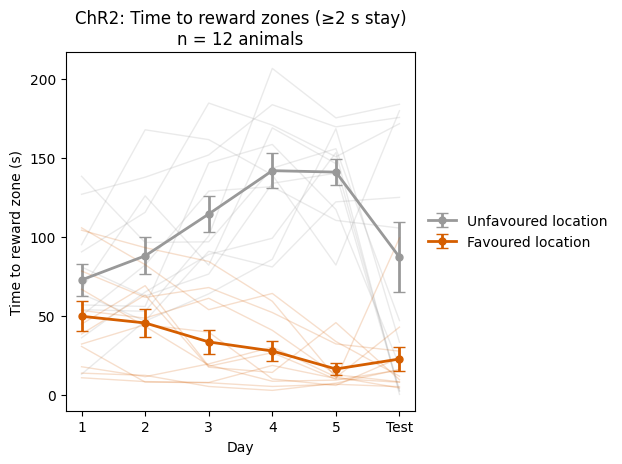

In [38]:

# ============================================================
# Time to reward zone (L1–L5 + first T as Test day 6)
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Zones: trigger_id 1 & 2
#  - Plot individual animals (faded) + group mean ± SEM
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'ChR2'   # 'ChR2', 'ChR2_short', 'Hp'
genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- optional "≥2 s stay" tag in the title ----
SHOW_STAY_TAG = True   # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L/T, usable
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# assign plot_day
mt['plot_day'] = np.nan

# L days: 1–5 from trial_type_day
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))].copy()

# For each animal, find first T session AFTER last L session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)   # days 1–5 + Test(6)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Build subject × day matrices per reward zone
# ------------------------------------------------------------
def build_zone_matrix(mt_all, trigger_id):
    """
    For a given trigger_id, return:
      - matrix shape (n_animals, n_days)
      - list of subject IDs
    Animals are kept as long as they have SOME non-NaN across days.
    """
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]
    if mt_zone.empty:
        return None, []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days],
                        dtype=float)

        # keep animal if it has at least one valid day
        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


zone_ids = [1, 2]  # only 2 reward zones

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"{genotype_label} – Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"  Animal IDs:", subs)
    print("-" * 50)

# ------------------------------------------------------------
# 3) Plot: per reward zone, individual + mean ± SEM
# ------------------------------------------------------------
plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.size == 0:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,   # ms → s
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM (nan-aware)
    mean_vals = np.nanmean(mat, axis=0)
    n_per_day = np.sum(~np.isnan(mat), axis=0)
    sem_vals  = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(np.maximum(n_per_day, 1))

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

plt.xlabel('Day')
plt.ylabel('Time to reward zone (s)')
plt.title(
    f'{genotype_label}: Time to reward zones{STAY_TAG}\n'
    f'n = {n_animals} animals',
    fontsize=12
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

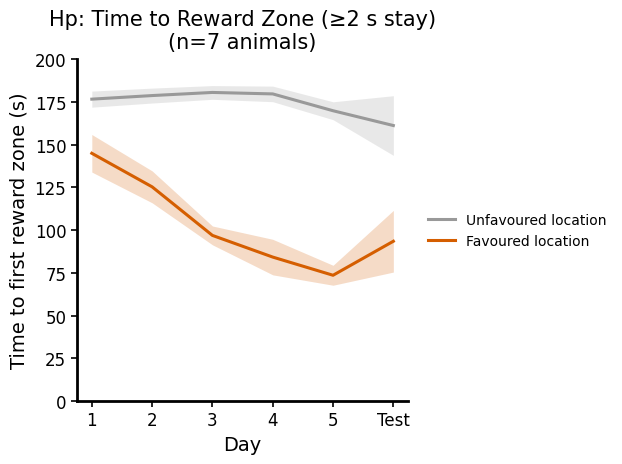

In [16]:
# ----- PLOT: ChR2, PER REWARD ZONE, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM (in seconds)
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )

    # ---- mean line (no individual traces) ----
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'Hp: Time to Reward Zone (≥2 s stay)\n'
    f'(n={n_animals} animals)',
    fontsize=15,
    pad=8
)
# (≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.ylim(0, 200)
plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

Animals included:
  VTA (ChR2), Unfavoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA (ChR2), Favoured location:
    n animals plotted = 12
    ids = ['A', 'C', 'D', 'AB', 'AC', 'AD', 'AE', 'AF', 'AG', 'AH', 'AM', 'AO']
  VTA short (ChR2_short), Unfavoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  VTA short (ChR2_short), Favoured location:
    n animals plotted = 8
    ids = ['AI', 'AJ', 'AL', 'V1', 'V2', 'V3', 'V4', 'V5']
  CA1 (CA1), Unfavoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA1 (CA1), Favoured location:
    n animals plotted = 7
    ids = ['AP', 'AQ', 'AR', 'AT', 'AU', 'AV', 'C8']
  CA3 (CA3), Unfavoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']
  CA3 (CA3), Favoured location:
    n animals plotted = 7
    ids = ['C1', 'C2', 'C3', 'C4', 'C5', 'C

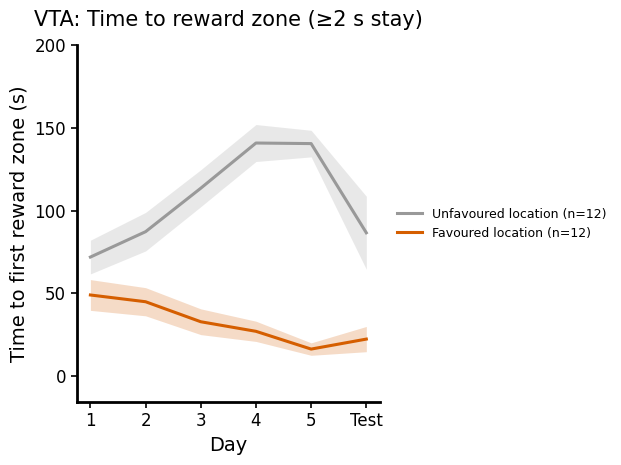

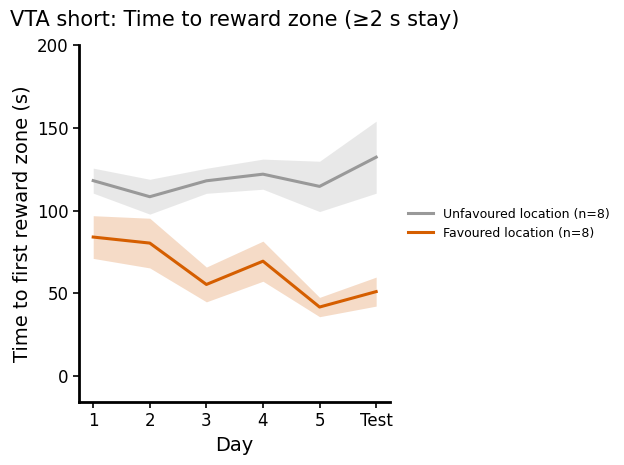

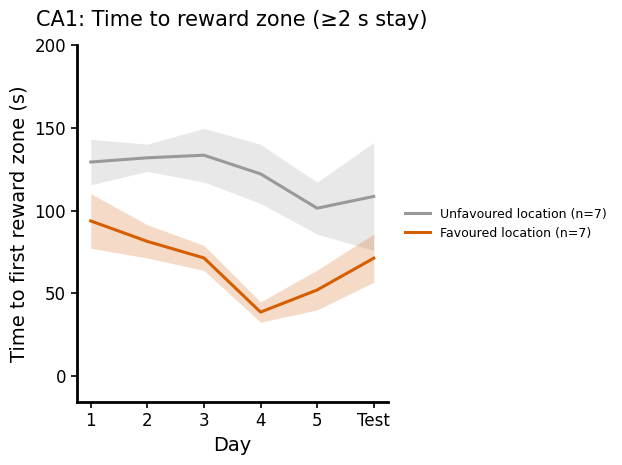

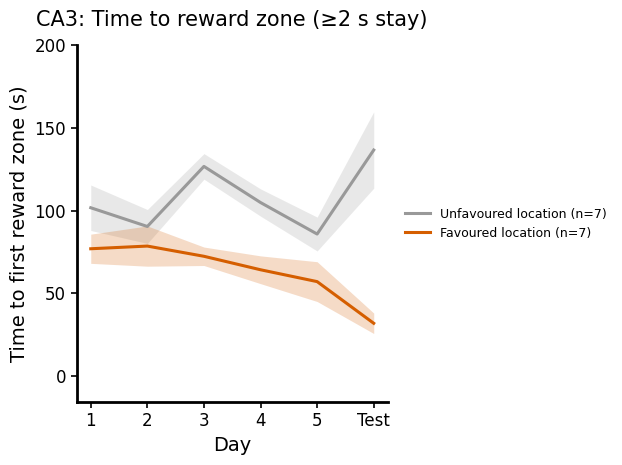

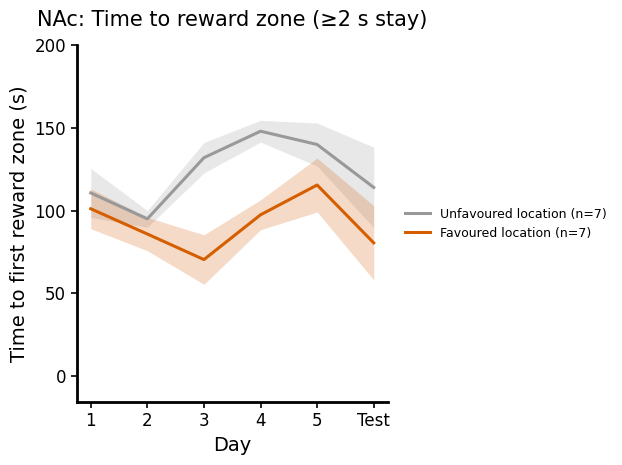

In [128]:
# ============================================================
# Time to reward zone across L1-L5 + Test
# Flexible groups
# Zones: trigger_id 1 & 2
# Plot group mean ± SEM, with optional shading and individual traces
# Requires meta_trig with:
#   - trigger_id
#   - t_to_trigger_trig
# ============================================================

# ============================================================
# OPTIONS
# ============================================================

GROUPS = ['ChR2', 'ChR2_short', 'CA1', 'CA3', 'NAc']
# GROUPS = ['ChR2', 'eYFP_ChR2', 'NAc']
# GROUPS = ['ChR2', 'NAc', 'NAc_control']
# GROUPS = ['CA1', 'CA3', 'CA1_control']

EXCLUDE_ID = ['AS', 'AN']      # e.g. ['AS', 'AN']
EXCLUDE_SUBS = []              # e.g. [43]

ZONE_IDS = [1, 2]

ZONE_LABELS = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

ZONE_COLORS = {
    1: '#999999',
    2: '#D55E00',
}

DISPLAY_NAME = {
    'ChR2': 'VTA',
    'eYFP_ChR2': 'VTA control',
    'ChR2_short': 'VTA short',
    'Hp': 'Hp',
    'CA1': 'CA1',
    'CA1_control': 'CA1 control',
    'CA3': 'CA3',
    'CA3_control': 'CA3 control',
    'NAc': 'NAc',
    'NAc_control': 'NAc control',
}

PLOT_MODE = 'separate_figures'   # 'separate_figures' or 'same_figure'

REQUIRE_COMPLETE = False         # True -> only animals with all L1-L5 + Test
PLOT_INDIVIDUAL = False          # True -> faded individual animal traces
SHOW_SEM_SHADING = True          # False -> no shaded SEM band
SHOW_SEM_ERRORBARS = False       # True -> SEM error bars on mean line

SHOW_STAY_TAG = True             # set True if t_to_trigger_trig uses ≥2 s stay
STAY_TAG = ' (≥2 s stay)' if SHOW_STAY_TAG else ''

# Y-axis options
YMIN = None                      # None -> automatically below 0
YMAX = 200                       # e.g. 200, or None for auto
Y_BOTTOM_PAD_FRAC = 0.08         # used if YMIN is None; larger raises 0 more
Y_TICK_STEP = 50                 # e.g. 20, 50, etc.

plot_days = np.arange(1, 7)
x_vals = plot_days - 1

# ============================================================
# 1. Filter metadata
# ============================================================

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'].isin(GROUPS)) &
    (meta_trig['trial_type'].isin(['L', 'T'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

if len(EXCLUDE_ID) > 0:
    mt = mt[
        ~mt['id'].astype(str).isin([str(x) for x in EXCLUDE_ID])
    ].copy()

if len(EXCLUDE_SUBS) > 0:
    mt = mt[
        ~mt['sub'].astype(str).isin([str(x) for x in EXCLUDE_SUBS])
    ].copy()

# ============================================================
# 2. Assign plot_day: L1-L5 + first post-learning T = Test day 6
# ============================================================

mt['plot_day'] = np.nan

mask_L = mt['trial_type'] == 'L'
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5
mt = mt[
    (~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))
].copy()

# assign first T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[
        (ms['trial_type'] == 'T') &
        (ms['ses'] > last_L_ses)
    ]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]

    mt.loc[idx, 'plot_day'] = 6

mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ============================================================
# 3. Helpers
# ============================================================

def sem_by_day(mat):
    sem = np.zeros(mat.shape[1], dtype=float)

    for i in range(mat.shape[1]):
        vals = mat[:, i]
        vals = vals[np.isfinite(vals)]

        if len(vals) <= 1:
            sem[i] = 0.0
        else:
            sem[i] = np.nanstd(vals, ddof=1) / np.sqrt(len(vals))

    return sem

def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.tick_params(direction='out', length=4, width=1.2)

def apply_y_axis(ax, ymax_candidates=None):
    if YMAX is not None:
        ymax = YMAX
    else:
        if ymax_candidates is None or len(ymax_candidates) == 0:
            ymax = 200
        else:
            ymax = np.nanmax(ymax_candidates)
            if not np.isfinite(ymax) or ymax <= 0:
                ymax = 200
            else:
                ymax = ymax * 1.20

    if YMIN is not None:
        ymin = YMIN
    else:
        ymin = -Y_BOTTOM_PAD_FRAC * ymax

    ax.set_ylim(ymin, ymax)

    # integer tick labels
    yticks = np.arange(0, int(np.ceil(ymax)) + 1, Y_TICK_STEP)
    if len(yticks) == 0 or yticks[0] != 0:
        yticks = np.insert(yticks, 0, 0)

    ax.set_yticks(yticks)

def build_zone_matrix(mt_all, genotype, trigger_id):
    """
    Returns:
      - matrix: animal x day, in ms
      - subjects
      - animal_ids
    """
    perf_mat = []
    subjects = []
    animal_ids = []

    mt_zone = mt_all[
        (mt_all['genotype'] == genotype) &
        (mt_all['trigger_id'] == trigger_id)
    ].copy()

    if mt_zone.empty:
        return None, [], []

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub].copy()

        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        vals = np.array(
            [mean_by_day.get(d, np.nan) for d in plot_days],
            dtype=float
        )

        if REQUIRE_COMPLETE and np.any(np.isnan(vals)):
            continue

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

        if 'id' in ms.columns and ms['id'].notna().any():
            animal_ids.append(str(ms['id'].dropna().iloc[0]))
        else:
            animal_ids.append(str(sub))

    if len(perf_mat) == 0:
        return None, [], []

    return np.vstack(perf_mat), subjects, animal_ids

# ============================================================
# 4. Build matrices
# ============================================================

zone_data = {}

print("Animals included:")
for g in GROUPS:
    zone_data[g] = {}

    for zid in ZONE_IDS:
        mat, subs, ids = build_zone_matrix(mt, g, zid)

        zone_data[g][zid] = {
            'mat': mat,
            'subs': subs,
            'ids': ids,
        }

        print(f"  {DISPLAY_NAME.get(g, g)} ({g}), {ZONE_LABELS.get(zid, f'Zone {zid}')}:")
        print(f"    n animals plotted = {len(subs)}")
        print(f"    ids = {ids}")

# ============================================================
# 5A. Plot: one figure per genotype, zone 1 vs zone 2
# ============================================================

if PLOT_MODE == 'separate_figures':

    for g in GROUPS:
        fig, ax = plt.subplots(figsize=(7.5, 5))

        ymax_candidates = []

        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            # ms -> s
            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = ZONE_COLORS.get(zid, get_genotype_color(g))
            label = ZONE_LABELS.get(zid, f'Reward zone {zid}')

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        '-',
                        color=col,
                        alpha=0.12,
                        linewidth=1.0,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.22,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                '-',
                color=col,
                linewidth=2.2,
                label=f'{label} (n={len(subs)})',
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.2,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

        ax.set_xlabel('Day', fontsize=14)
        ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

        ax.set_xticks(np.arange(6))
        ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
        ax.tick_params(axis='y', labelsize=12)

        style_nature(ax)

        ax.set_title(
            f'{DISPLAY_NAME.get(g, g)}: Time to reward zone{STAY_TAG}',
            fontsize=15,
            pad=14
        )

        ax.legend(
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            fontsize=9
        )

        apply_y_axis(ax, ymax_candidates)

        plt.tight_layout(rect=[0, 0, 0.85, 0.95])
        plt.show()

# ============================================================
# 5B. Plot: all groups/zones on same figure
# ============================================================

elif PLOT_MODE == 'same_figure':

    fig, ax = plt.subplots(figsize=(8, 5.2))

    line_styles = {
        1: '-',
        2: '--',
    }

    ymax_candidates = []

    for g in GROUPS:
        for zid in ZONE_IDS:
            mat = zone_data[g][zid]['mat']
            subs = zone_data[g][zid]['subs']

            if mat is None or len(subs) == 0:
                continue

            mean_ms = np.nanmean(mat, axis=0)
            sem_ms = sem_by_day(mat)

            mean_s = mean_ms / 1000.0
            sem_s = sem_ms / 1000.0

            col = get_genotype_color(g)
            label = (
                f'{DISPLAY_NAME.get(g, g)} '
                f'{ZONE_LABELS.get(zid, f"Zone {zid}")} '
                f'(n={len(subs)})'
            )

            if PLOT_INDIVIDUAL:
                for row in mat:
                    ax.plot(
                        x_vals,
                        row / 1000.0,
                        line_styles.get(zid, '-'),
                        color=col,
                        alpha=0.08,
                        linewidth=0.9,
                        zorder=1
                    )

            if SHOW_SEM_SHADING:
                ax.fill_between(
                    x_vals,
                    mean_s - sem_s,
                    mean_s + sem_s,
                    color=col,
                    alpha=0.08,
                    linewidth=0,
                    zorder=2
                )

            ax.plot(
                x_vals,
                mean_s,
                line_styles.get(zid, '-'),
                color=col,
                linewidth=2.1,
                label=label,
                zorder=3
            )

            if SHOW_SEM_ERRORBARS:
                ax.errorbar(
                    x_vals,
                    mean_s,
                    yerr=sem_s,
                    fmt='none',
                    ecolor=col,
                    elinewidth=1.0,
                    capsize=3,
                    alpha=0.9,
                    zorder=4
                )

            ymax_candidates.append(np.nanmax(mean_s + sem_s))

    ax.set_xlabel('Day', fontsize=14)
    ax.set_ylabel('Time to first reward zone (s)', fontsize=14)

    ax.set_xticks(np.arange(6))
    ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)

    style_nature(ax)

    ax.set_title(
        f'Time to reward zone{STAY_TAG}',
        fontsize=15,
        pad=10
    )

    ax.legend(
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=8
    )

    apply_y_axis(ax, ymax_candidates)

    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()

else:
    raise ValueError("PLOT_MODE must be 'separate_figures' or 'same_figure'")

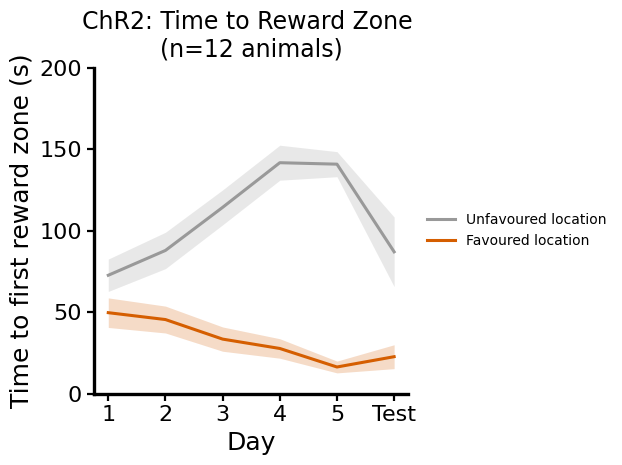

In [39]:
# ChR2 per reward zone - clean figure (larger axes, legend right, vector export)
import os

out_dir = "/Users/stella/Desktop/vector_files"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.5, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or mat.shape[0] == 0:
        continue

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[zid],
        alpha=0.22,
        linewidth=0
    )
    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[zid],
        linewidth=2.2,
        label=f'{labels[zid]}'
    )

# Axes + style (bigger axis text)
ax.set_xlabel('Day', fontsize=18)
ax.set_ylabel('Time to first reward zone (s)', fontsize=18)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.4)
ax.spines['left'].set_linewidth(2.4)
ax.tick_params(direction='out', length=5, width=1.6)

ax.set_title(
    f'ChR2: Time to Reward Zone \n'
    f'(n={n_animals} animals)',
    fontsize=17,
    pad=8
 )
ax.set_ylim(0, 200)

# Legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.tight_layout(rect=[0, 0, 0.85, 0.95])
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.svg'), bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_clean.pdf'), bbox_inches='tight')
plt.show()

Hp – animals included per reward zone (L days 1–5):
  Reward zone 1: 7 animals
  Reward zone 2: 7 animals

Total unique animals included (any zone): 7
Animal IDs: [np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46)]


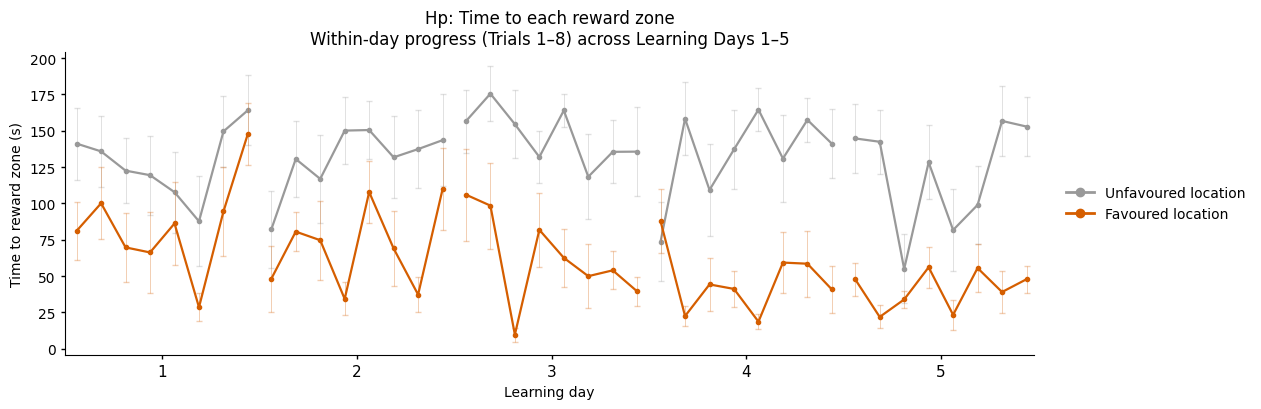

In [ ]:

from matplotlib.lines import Line2D

# ============================================================
# Trial-by-trial time to reward (L-only)
#  - Genotype: choose 'ChR2_short', 'ChR2', or 'Hp'
#  - 5 learning days (1–5)
#  - 8 trials per day
#  - Zones: trigger_id 1 & 2
# ============================================================

# ---- choose genotype ----
GENOTYPE = 'Hp'   # 'ChR2_short', 'ChR2', 'Hp'
genotype_label = {
    'ChR2_short': 'ChR2_short',
    'ChR2':       'ChR2',
    'Hp':         'Hp'
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

days   = np.arange(1, 6)
trials = np.arange(1, 9)
zone_ids = [1,2]


# ------------------------------------------------------------
# 1) Filter meta_trig for chosen genotype, L only, days 1–5
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Ensure we have a per-trial index (trial_in_day = 1..8)
# ------------------------------------------------------------
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index': 'trial_id'})

trial_table = (
    mt[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub', 'ses', 'trial_type_day']
).cumcount() + 1
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

mt = mt.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for one day & one zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id):
    md = mt_all[
        (mt_all['trial_type_day'] == day) &
        (mt_all['trigger_id'] == zone_id)
    ]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['t_to_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials],
                        dtype=float)
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, mt_all, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(mt_all, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_ / 1000.0,     # ms → s
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_ / 1000.0, yerr=sem_ / 1000.0,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Plot for chosen genotype
# ------------------------------------------------------------
colors = {
    1: '#999999',  # Unfavoured location
    2: '#D55E00',  # Favoured location
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        mt,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

# ---- X/Y labels, ticks, style ----
ax.set_xlabel('Learning day')
ax.set_ylabel('Time to reward zone (s)')

# center ticks under each day block
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days], fontsize=11)

ax.set_xlim(1.0, 5.98)


ax.set_title(
    f'{genotype_label}: Time to each reward zone{STAY_TAG}\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

# journal / NN style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(direction='out', length=3, width=1)
ax.grid(False)

legend_handles = [
    Line2D([0], [0], color=colors[1], lw=2, marker='o', label=labels[1]),
    Line2D([0], [0], color=colors[2], lw=2, marker='o', label=labels[2]),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# animal counts (info)
subs_zone = {
    zid: sorted(mt.loc[mt['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}
print(f"{genotype_label} – animals included per reward zone (L days 1–5):")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

Hp – First-choice analysis (L trials only)

Total L-trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 58 trials
  Day 5: 56 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1 (unfav)=35, Zone2 (fav)=21
  Day 2:  Zone1 (unfav)=30, Zone2 (fav)=26
  Day 3:  Zone1 (unfav)=17, Zone2 (fav)=39
  Day 4:  Zone1 (unfav)=10, Zone2 (fav)=48
  Day 5:  Zone1 (unfav)=10, Zone2 (fav)=46

Proportions (% of trials):
  Day 1:  Zone1 (unfav)=62.5%, Zone2 (fav)=37.5%
  Day 2:  Zone1 (unfav)=53.6%, Zone2 (fav)=46.4%
  Day 3:  Zone1 (unfav)=30.4%, Zone2 (fav)=69.6%
  Day 4:  Zone1 (unfav)=17.2%, Zone2 (fav)=82.8%
  Day 5:  Zone1 (unfav)=17.9%, Zone2 (fav)=82.1%



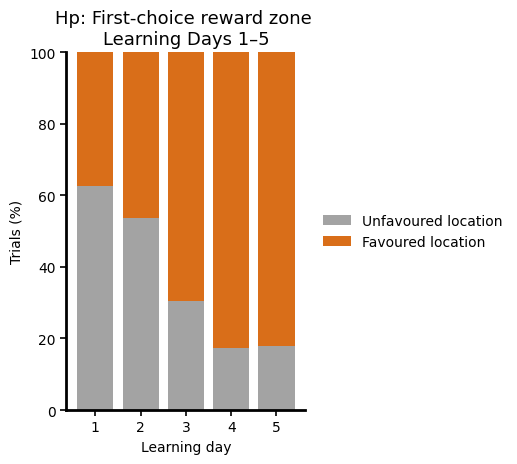

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# First-choice zone (% of trials) for L trials only
#  - Genotype: choose 'ChR2', 'ChR2_short', or 'Hp'
#  - Days: L1–L5 (trial_type_day 1–5)
#  - Zones: 1 = unfavoured, 2 = favoured
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'Hp'      # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ---- toggle whether to display (≥2 s stay) ----
SHOW_STAY_TAG = False            # <--- change this
STAY_TAG = " (≥2 s stay)" if SHOW_STAY_TAG else ""

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L only, not short
# ------------------------------------------------------------
days = np.arange(1, 6)   # L1–L5

mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# Use trial_type_day directly as "plot_day"
mt['plot_day'] = mt['trial_type_day'].astype(int)

plot_days = days  # [1..5]

# ------------------------------------------------------------
# 2) First-choice per trial: earliest t_to_trigger_trig
# ------------------------------------------------------------
mt_use = mt.copy()

# one row per trial = the trigger_id with minimal latency
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# ------------------------------------------------------------
# 3) Count choices per day × trigger
#    (only zones 1 & 2 – unfavoured / favoured)
# ------------------------------------------------------------
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2], fill_value=0)
)

# Total L trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)   # 0 if no trials that day

# ------------------------------------------------------------
# 4) Print summary
# ------------------------------------------------------------
print("====================================")
print(f"{genotype_label} – First-choice analysis (L trials only)")
print("====================================")

print("\nTotal L-trials per day:")
for d in plot_days:
    print(f"  Day {d}: {int(total_trials.loc[d])} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={int(row.get(1, 0))}, "
        f"Zone2 (fav)={int(row.get(2, 0))}"
    )

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(
        f"  Day {d}:  "
        f"Zone1 (unfav)={row[1]*100:.1f}%, "
        f"Zone2 (fav)={row[2]*100:.1f}%"
    )
print("====================================\n")

# ------------------------------------------------------------
# 5) Plot stacked bars (Zone1 vs Zone2)
# ------------------------------------------------------------
colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}
labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

fig, ax = plt.subplots(figsize=(6.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2]:
    vals = proportions[trig_id].values * 100  # to %
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.9,
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in plot_days])
ax.set_xlabel('Learning day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title(
    f'{genotype_label}: First-choice reward zone {STAY_TAG}\n'
    'Learning Days 1–5',
    fontsize=13
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.82, 0.95])
plt.show()

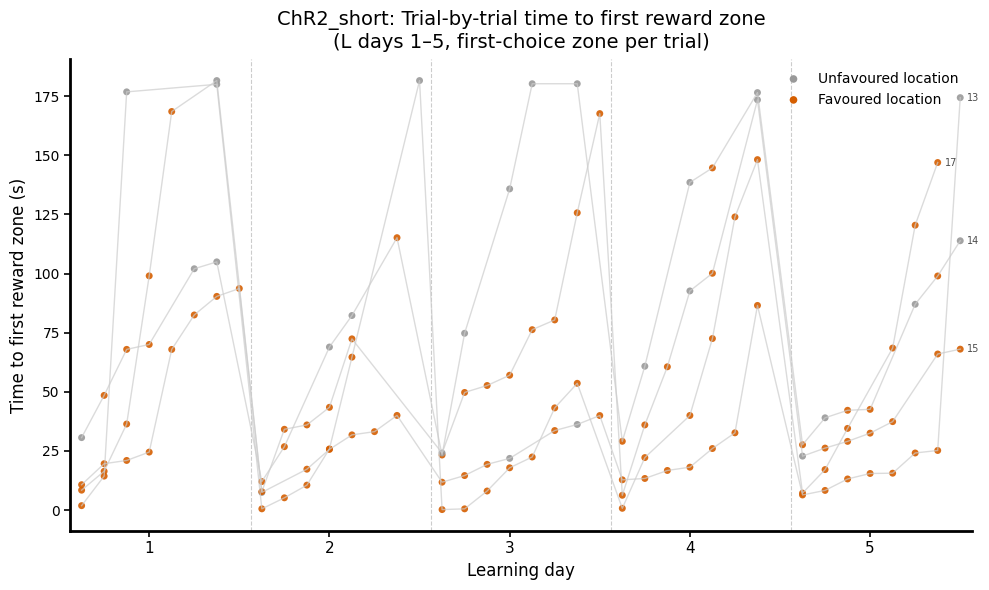

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trial-by-trial time to first reward zone (L only)
# Genotype: 'ChR2', 'ChR2_short', or 'Hp'
# Zone 1 = unfavoured, Zone 2 = favoured
# Days: L1–L5, 8 trials/day → 40 trials total
# ============================================================

# ---- choose genotype here ----
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', or 'Hp'

genotype_label = {
    'ChR2':       'ChR2',
    'ChR2_short': 'ChR2_short',
    'Hp':         'Hp',
}[GENOTYPE]

# ------------------------------------------------------------
# 1) Filter: chosen genotype, L-only, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L')
].copy()

# Use L days 1–5 from trial_type_day
mt = mt[mt['trial_type_day'].isin([1, 2, 3, 4, 5])].copy()
mt['plot_day'] = mt['trial_type_day'].astype(int)

# Keep only zones 1 & 2 (unfavoured / favoured)
mt = mt[mt['trigger_id'].isin([1, 2])].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses) by time
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
group_key = 'trial_id'
if group_key not in mt.columns:
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..40)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (
    (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']
)

# Only L days 1–5 are used
mt_use = first_choice[first_choice['plot_day'].between(1, 5)].copy()

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',   # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured location',
    2: 'Favoured location',
}

# plot each animal
for sub in sorted(mt_use['sub'].unique()):
    ms = mt_use[mt_use['sub'] == sub].sort_values(['plot_day', 'trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0  # ms → s

    # grey animal-wise trajectory
    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    # coloured points by first-choice zone
    for zid in [1, 2]:
        ms_z = ms[ms['trigger_id'] == zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values) / 1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    # label animal at last trial
    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 L days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators between days
for d in range(1, max_day):
    ax.axvline(d * trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x-tick labels at center of each day block
day_centers = [(d - 0.5) * trials_per_day for d in range(1, max_day + 1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day + 1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Learning day', fontsize=12)
ax.set_ylabel('Time to first reward zone (s)', fontsize=12)

# legend for zones
handles = []
labels = []
for zid in [1, 2]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title(
    f'{genotype_label}: Trial-by-trial time to first reward zone\n'
    '(L days 1–5, first-choice zone per trial)',
    fontsize=14,
    pad=8
)

plt.tight_layout()
plt.show()

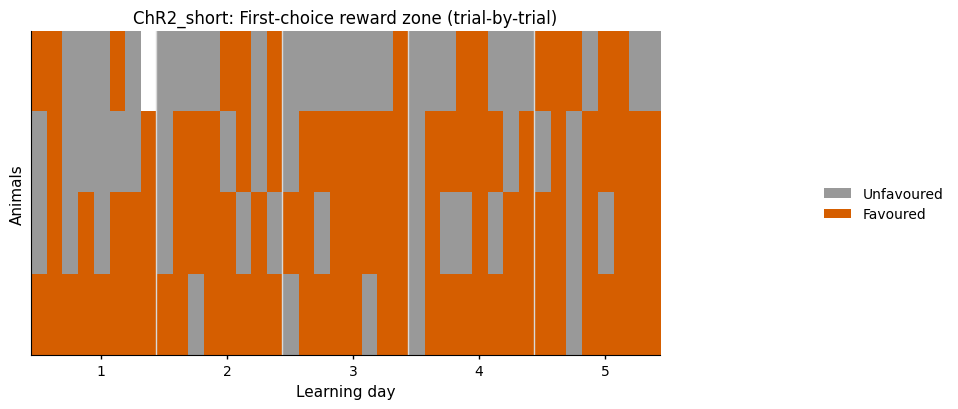

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm

# =======================================
# SETTINGS
# =======================================
GENOTYPE = 'ChR2_short'   # 'ChR2', 'ChR2_short', 'Hp'
days = np.arange(1, 6)    # L1–L5
trials_per_day = 8

zone_colors = {
    1: '#999999',  # unfavoured
    2: '#D55E00',   # favoured
}

zone_labels = {
    1: 'Unfavoured',
    2: 'Favoured',
}

# =======================================
# 1) Filter L-only for genotype
# =======================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == GENOTYPE) &
    (meta_trig['trial_type'] == 'L') &
    (meta_trig['trial_type_day'].isin(days)) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

# =======================================
# 2) Per-trial index (1..8)
# =======================================
if 'trial_id' not in mt.columns:
    mt = mt.reset_index().rename(columns={'index':'trial_id'})

trial_table = (
    mt[['trial_id','sub','ses','trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub','ses','trial_type_day','trial_id'])
)

trial_table['trial_in_day'] = trial_table.groupby(
    ['sub','ses','trial_type_day']
).cumcount() + 1

trial_table = trial_table[trial_table['trial_in_day'].between(1, trials_per_day)]
mt = mt.merge(trial_table[['trial_id','trial_in_day']], on='trial_id', how='inner')

# =======================================
# 3) first-choice zone = min t_to_trigger_trig per trial
# =======================================
idx_first = mt.groupby('trial_id')['t_to_trigger_trig'].idxmin()
fc = mt.loc[idx_first].copy()

fc = fc[fc['trigger_id'].isin([1,2])]   # only two zones

# global trial index = 1..40
fc['trial_idx_global'] = (
    (fc['trial_type_day'] - 1)*trials_per_day + fc['trial_in_day']
)

max_idx = len(days)*trials_per_day   # = 40

# =======================================
# 4) Build animal × trial matrix
# =======================================
animals = sorted(fc['sub'].unique())
n_animals = len(animals)

mat = np.zeros((n_animals, max_idx), dtype=int)

for i, sub in enumerate(animals):
    ms = fc[fc['sub'] == sub]
    for _, r in ms.iterrows():
        ti = int(r['trial_idx_global'])-1
        mat[i, ti] = int(r['trigger_id'])

# =======================================
# 5) sort animals by early preference
# =======================================
early = mat[:, :2*trials_per_day].astype(float)
late  = mat[:, -2*trials_per_day:].astype(float)
early[early==0]=np.nan
late[late==0]=np.nan
mE = np.nanmean(early, axis=1)
mL = np.nanmean(late, axis=1)

order = np.lexsort((mL, mE))
mat = mat[order]
animals_sorted = [animals[i] for i in order]

# =======================================
# 6) PLOT (publication style)
# =======================================
fig, ax = plt.subplots(figsize=(8, 4.2))

cmap = ListedColormap(['white', zone_colors[1], zone_colors[2]])
norm = BoundaryNorm([-0.5,0.5,1.5,2.5], cmap.N)

im = ax.imshow(mat, aspect='auto', cmap=cmap, norm=norm)

# day separators
for d in range(1, len(days)):
    ax.axvline(d*trials_per_day-0.5, color='0.85', lw=1.0)

# x ticks centered on each day
centers = [(d-0.5)*trials_per_day for d in days]
ax.set_xticks(centers)
ax.set_xticklabels([str(d) for d in days], fontsize=10)

# y axis: small, no clutter
ax.set_yticks([])
ax.set_ylabel('Animals', fontsize=11)
ax.set_xlabel('Learning day', fontsize=11)

# title
ax.set_title(
    f'{GENOTYPE}: First-choice reward zone (trial-by-trial)',
    fontsize=12,
    pad=6
)

# spines minimal
for s in ['top','right']:
    ax.spines[s].set_visible(False)

ax.tick_params(direction='out', length=3, width=1)

# legend outside
handles = [
    Patch(facecolor=zone_colors[1], label=zone_labels[1]),
    Patch(facecolor=zone_colors[2], label=zone_labels[2]),
]
fig.legend(
    handles=handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,1])
plt.show()

/var/folders/6_/_2_s91650739bx8dhlrpf8qc0000gn/T/ipykernel_80366/2320800996.py:51: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(mat,0)
/opt/anaconda3/envs/2p-analysis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


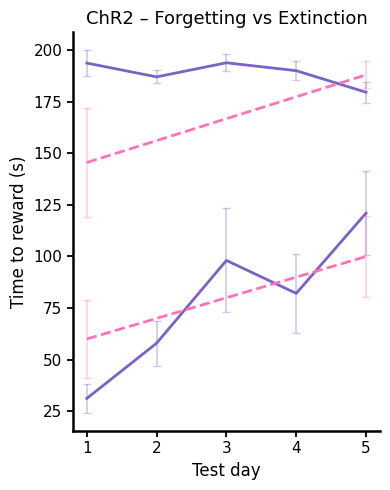

In [16]:
import numpy as np
import matplotlib.pyplot as plt

col_f = "#FF72B8"   # pink (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)

# ------------------------------------------------------------
# Filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction']))
].copy()

max_day = 5
day_values = np.arange(1, max_day+1)

# ------------------------------------------------------------
# helper: subject × day matrix per trigger
# ------------------------------------------------------------
def build_mat(df, trig):
    df = df[df['trigger_id']==trig]
    
    mats = []
    subs = []
    
    for sub in df['sub'].unique():
        ms = df[df['sub']==sub]
        m = ms.groupby('trial_type_day')['t_to_trigger_trig'].mean()
        
        # build 5-day vector (may contain NaNs)
        v = np.array([m.get(d, np.nan) for d in day_values], dtype=float)
        
        # NEW: keep animal if at least 1 valid day
        if np.isnan(v).all():
            continue
        
        mats.append(v)
        subs.append(sub)
    
    if len(mats)==0:
        return None, []
    
    return np.vstack(mats), subs

def mean_sem(mat):
    if mat is None or mat.size==0: return None,None
    mean = np.nanmean(mat,0)
    sem  = np.nanstd(mat,0)/np.sqrt(mat.shape[0])
    return mean, sem

# ------------------------------------------------------------
# Build matrices
# ------------------------------------------------------------
m_f_z1, s_f_z1 = build_mat(meta[meta['test_type']=='forgetting'],1)
m_f_z2, s_f_z2 = build_mat(meta[meta['test_type']=='forgetting'],2)

m_e_z1, s_e_z1 = build_mat(meta[meta['test_type']=='extinction'],1)
m_e_z2, s_e_z2 = build_mat(meta[meta['test_type']=='extinction'],2)

# ------------------------------------------------------------
# Plot single panel
# ------------------------------------------------------------
plt.figure(figsize=(4,5))

# extinction curves full 1-5
for mat,color,label in [(m_e_z1,col_e,'Zone1 extinction'),
                        (m_e_z2,col_e,'Zone2 extinction')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    mean_s = mean_ms/1000; sem_s=sem_ms/1000
    plt.plot(day_values, mean_s, '-', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(day_values, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

# forgetting dashed 1→5
for mat,color,label in [(m_f_z1,col_f,'Zone1 forgetting'),
                        (m_f_z2,col_f,'Zone2 forgetting')]:
    mean_ms,sem_ms = mean_sem(mat)
    if mean_ms is None: continue
    x = np.array([day_values[0], day_values[-1]])
    mean_s = np.array([mean_ms[0], mean_ms[-1]])/1000
    sem_s  = np.array([sem_ms[0], sem_ms[-1]])/1000
    plt.plot(x, mean_s, '--', color=color, linewidth=2.0, alpha=1)
    plt.errorbar(x, mean_s, yerr=sem_s, fmt='none',
                 ecolor=color, alpha=0.35, capsize=3, elinewidth=1.2)

plt.xlabel('Test day', fontsize=12)
plt.ylabel('Time to reward (s)', fontsize=12)
plt.xticks(day_values, fontsize=11)
plt.yticks(fontsize=11)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.title('ChR2 – Forgetting vs Extinction', fontsize=13, pad=6)
#(>2s stay)

plt.tight_layout()
plt.show()

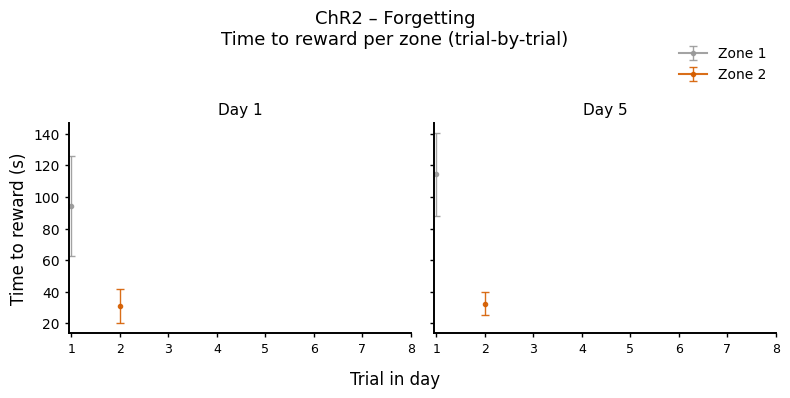

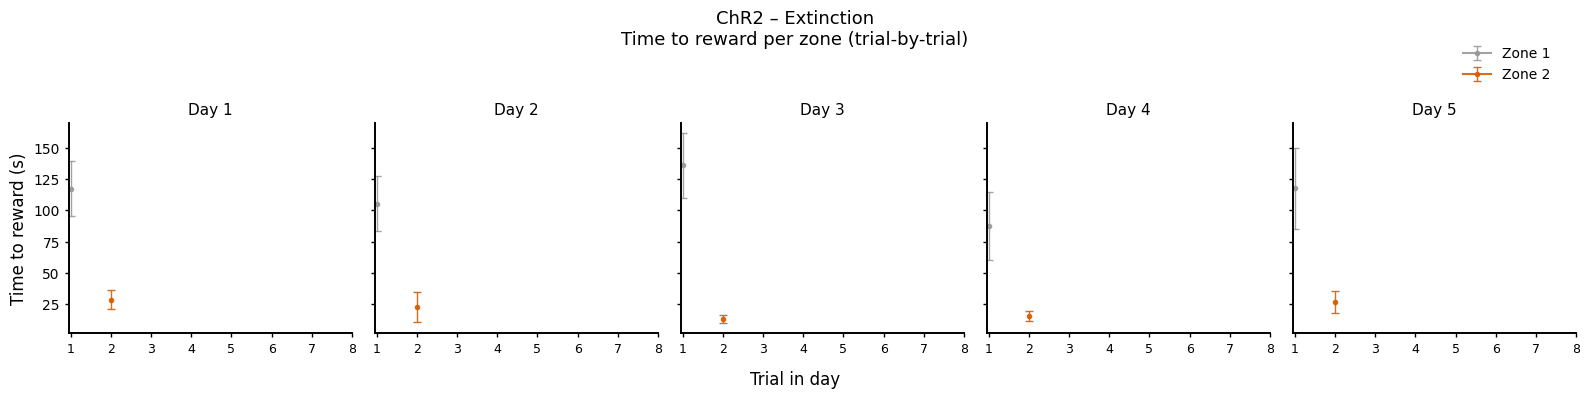

In [ ]:
# revise later - tried to plot for trial to trial progress

# ------------------------------------------------------------
# Base filter: ChR2, TEST, usable, not short, forgetting/extinction
# ------------------------------------------------------------
meta = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting', 'extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

max_day    = 5
day_values = np.arange(1, max_day + 1)
trial_vals = np.arange(1, 9)  # trials 1–8

# ------------------------------------------------------------
# Ensure trial_in_day exists (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial',
    'trial_idx', 'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta.columns), None)

if trial_col is not None:
    meta['trial_in_day'] = meta[trial_col].astype(int)
else:
    meta = meta.sort_values(['sub', 'ses']).copy()
    meta['trial_in_day'] = meta.groupby(['sub', 'ses']).cumcount() + 1

meta = meta[meta['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# Build mean ± SEM per (day, trial) for each trigger
# ------------------------------------------------------------
def build_day_trial_stats(meta_df, trigger_id):
    """
    For given meta subset (forgetting / extinction) and trigger_id,
    returns:
        stats[day] = (mean_s, sem_s)  # arrays of length = 8 trials
    where units are seconds.
    """
    stats = {}

    df_trig = meta_df[meta_df['trigger_id'] == trigger_id].copy()
    if df_trig.empty:
        return stats

    for day in day_values:
        df_day = df_trig[df_trig['trial_type_day'] == day]
        if df_day.empty:
            continue

        # 1) Average within each animal × trial_in_day
        #    (in case there are multiple T trials per day)
        per_sub_trial = (
            df_day
            .groupby(['sub', 'trial_in_day'])['t_to_trigger_trig']
            .mean()
            .reset_index()
        )

        if per_sub_trial.empty:
            continue

        # 2) Across animals: mean & SEM for each trial_in_day
        g = per_sub_trial.groupby('trial_in_day')['t_to_trigger_trig']
        mean_series = g.mean()
        std_series  = g.std(ddof=1)
        n_series    = g.count()

        mean_ms = np.full(len(trial_vals), np.nan)
        sem_ms  = np.full(len(trial_vals), np.nan)

        for i, t in enumerate(trial_vals):
            if t in mean_series.index:
                mean_ms[i] = mean_series.loc[t]
                n = n_series.loc[t]
                if (n > 1) and not np.isnan(std_series.loc[t]):
                    sem_ms[i] = std_series.loc[t] / np.sqrt(n)

        # store in seconds
        stats[day] = (mean_ms / 1000.0, sem_ms / 1000.0)

    return stats

# ------------------------------------------------------------
# Split forgetting vs extinction and compute stats per zone
# ------------------------------------------------------------
meta_f = meta[meta['test_type'] == 'forgetting'].copy()
meta_e = meta[meta['test_type'] == 'extinction'].copy()

stats_f_z1 = build_day_trial_stats(meta_f, trigger_id=1)
stats_f_z2 = build_day_trial_stats(meta_f, trigger_id=2)

stats_e_z1 = build_day_trial_stats(meta_e, trigger_id=1)
stats_e_z2 = build_day_trial_stats(meta_e, trigger_id=2)

colors = {
    1: '#999999',  # Zone 1 (grey)
    2: '#D55E00',  # Zone 2 (orange)
}

# ============================================================
# FIGURE 1 – FORGETTING: ONLY DAY 1 AND DAY 5
# ============================================================
forget_days = [1, 5]
fig_f, axes_f = plt.subplots(1, len(forget_days), figsize=(8, 3.5), sharey=True)

if len(forget_days) == 1:
    axes_f = [axes_f]

for ax, day in zip(axes_f, forget_days):
    # Zone 1
    if day in stats_f_z1:
        mean_s, sem_s = stats_f_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_f_z2:
        mean_s, sem_s = stats_f_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    # NN-style axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_f[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_f.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_f[0].get_legend_handles_labels()
if handles:
    fig_f.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_f.suptitle('ChR2 – Forgetting\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

# ============================================================
# FIGURE 2 – EXTINCTION: DAYS 1–5
# ============================================================
ext_days = day_values
fig_e, axes_e = plt.subplots(1, len(ext_days), figsize=(16, 3.5), sharey=True)

if len(ext_days) == 1:
    axes_e = [axes_e]

for ax, day in zip(axes_e, ext_days):
    # Zone 1
    if day in stats_e_z1:
        mean_s, sem_s = stats_e_z1[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[1],
            ecolor=colors[1],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 1'
        )

    # Zone 2
    if day in stats_e_z2:
        mean_s, sem_s = stats_e_z2[day]
        ax.errorbar(
            trial_vals, mean_s, yerr=sem_s,
            fmt='-o',
            color=colors[2],
            ecolor=colors[2],
            alpha=0.9,
            elinewidth=1.0,
            capsize=3,
            markersize=3,
            label='Zone 2'
        )

    ax.set_title(f'Day {day}', fontsize=11)
    ax.set_xticks(trial_vals)
    ax.set_xticklabels([str(t) for t in trial_vals], fontsize=9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.4)
    ax.spines['left'].set_linewidth(1.4)
    ax.tick_params(direction='out', length=3, width=1)

axes_e[0].set_ylabel('Time to reward (s)', fontsize=12)
fig_e.text(0.5, -0.02, 'Trial in day', ha='center', fontsize=12)

handles, labels_ = axes_e[0].get_legend_handles_labels()
if handles:
    fig_e.legend(handles, labels_, frameon=False, loc='upper right', bbox_to_anchor=(0.98, 0.98))

fig_e.suptitle('ChR2 – Extinction\nTime to reward per zone (trial-by-trial)', fontsize=13, y=1.05)
plt.tight_layout(rect=[0, 0.02, 1, 0.98])
plt.show()

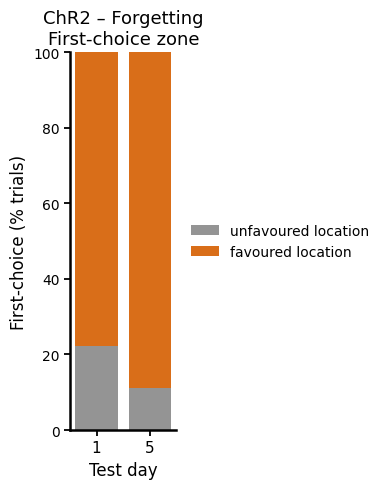

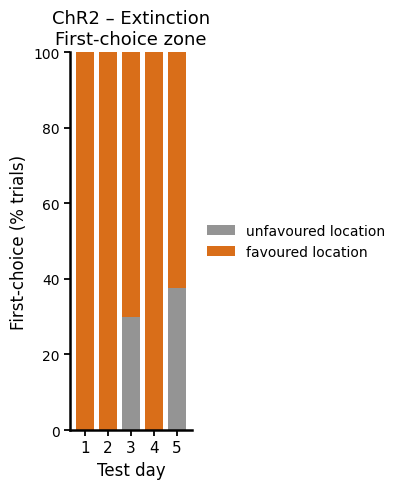

In [ ]:

# ============================================================
# Fade setting (0=transparent, 1=opaque)
# ============================================================
alpha = 0.9   # <-- adjust here

# ============================================================
# Base filter for first-choice analysis
# ============================================================
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

colors = {
    1: '#888888',   # zone 1 (unfavoured)
    2: '#D55E00',   # zone 2 (favoured)
}
labels = {
    1: 'unfavoured location',
    2: 'favoured location',
}

# ------------------------------------------------------------
# Helper: compute first-choice proportions
# ------------------------------------------------------------
def first_choice_props(mt_sub, day_vals):
    mt_sub = mt_sub[mt_sub['trial_type_day'].isin(day_vals)].copy()

    idx_first = mt_sub.groupby('trial_id')['t_to_trigger_trig'].idxmin()
    tmp = mt_sub.loc[idx_first].copy()

    total_trials = (
        tmp.groupby('trial_type_day').size()
           .reindex(day_vals, fill_value=0)
    )

    counts = (
        tmp.groupby(['trial_type_day','trigger_id']).size()
            .unstack('trigger_id')
            .reindex(index=day_vals, fill_value=0)
    )

    for zid in [1,2]:
        if zid not in counts.columns:
            counts[zid] = 0

    counts = counts[[1,2]]

    props = counts.div(total_trials.replace(0,np.nan),axis=0).fillna(0)*100

    return props, total_trials, counts


# ------------------------------------------------------------
# FIGURE 1 — FORGETTING: Days 1 & 5
# ------------------------------------------------------------
days_forget = [1,5]
mt_forget = mt[mt['test_type']=='forgetting']

props_f, total_f, counts_f = first_choice_props(mt_forget, days_forget)

plt.figure(figsize=(5,5))
x = np.arange(len(days_forget))
bottom = np.zeros(len(days_forget))

for zid in [1,2]:
    vals = props_f[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_forget],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Forgetting\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()


# ------------------------------------------------------------
# FIGURE 2 — EXTINCTION: Days 1–5
# ------------------------------------------------------------
days_ext = [1,2,3,4,5]
mt_ext = mt[mt['test_type']=='extinction']

props_e, total_e, counts_e = first_choice_props(mt_ext, days_ext)

plt.figure(figsize=(5.2,5))
x = np.arange(len(days_ext))
bottom = np.zeros(len(days_ext))

for zid in [1,2]:
    vals = props_e[zid].values
    plt.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[zid],
        alpha=alpha,               # <-- fade applied
        edgecolor='none',
        label=labels[zid]
    )
    bottom += vals

plt.xticks(x,[str(d) for d in days_ext],fontsize=11)
plt.xlabel('Test day',fontsize=12)
plt.ylabel('First-choice (% trials)',fontsize=12)
plt.ylim(0,100)

ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out',length=4,width=1.3)

plt.title('ChR2 – Extinction\nFirst-choice zone',fontsize=13,pad=6)

plt.legend(frameon=False,loc='center left',bbox_to_anchor=(1.02,0.5))
plt.tight_layout(rect=[0,0,0.8,1])
plt.show()

First-choice analysis summary (RL/T)

Total trials per day:
  Day 1: 56 trials
  Day 2: 56 trials
  Day 3: 56 trials
  Day 4: 56 trials
  Day 5: 56 trials
  Day 6: 7 trials

Trials choosing each trigger zone (raw counts):
  Day 1:  Zone1=2, Zone2=5, Zone3=49
  Day 2:  Zone1=5, Zone2=14, Zone3=37
  Day 3:  Zone1=11, Zone2=19, Zone3=26
  Day 4:  Zone1=12, Zone2=21, Zone3=23
  Day 5:  Zone1=11, Zone2=34, Zone3=11
  Day 6:  Zone1=1, Zone2=4, Zone3=2

Proportions (% of trials):
  Day 1:  Zone1=3.6%, Zone2=8.9%, Zone3=87.5%
  Day 2:  Zone1=8.9%, Zone2=25.0%, Zone3=66.1%
  Day 3:  Zone1=19.6%, Zone2=33.9%, Zone3=46.4%
  Day 4:  Zone1=21.4%, Zone2=37.5%, Zone3=41.1%
  Day 5:  Zone1=19.6%, Zone2=60.7%, Zone3=19.6%
  Day 6:  Zone1=14.3%, Zone2=57.1%, Zone3=28.6%



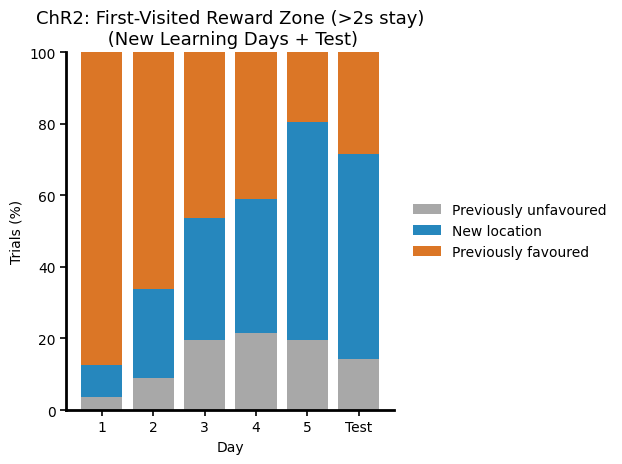

In [386]:

# ------------------------------------------------------------
# Filter: ChR2, RL/T, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5, T = 6
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign T=6 after last RL per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]

# ------------------------------------------------------------
# First-choice counting
# ------------------------------------------------------------
mt_use = mt.copy()

# Determine first trigger per trial
idx_first = mt_use.groupby('trial_id')['t_to_trigger_trig'].idxmin()
first_choice = mt_use.loc[idx_first].copy()

# Count per day × trigger
counts = (
    first_choice
    .groupby(['plot_day', 'trigger_id'])
    .size()
    .unstack('trigger_id')
    .reindex(index=plot_days, fill_value=0)
    .reindex(columns=[1, 2, 3], fill_value=0)
)

# Total trials per day
total_trials = (
    first_choice.groupby('plot_day').size()
    .reindex(plot_days, fill_value=0)
)

# Proportions
proportions = counts.div(total_trials.replace(0, np.nan), axis=0)
proportions = proportions.fillna(0)

print("====================================")
print("First-choice analysis summary (RL/T)")
print("====================================")

print("\nTotal trials per day:")
for d in plot_days:
    print(f"  Day {d}: {total_trials.loc[d]} trials")

print("\nTrials choosing each trigger zone (raw counts):")
for d in plot_days:
    row = counts.loc[d]
    print(f"  Day {d}:  Zone1={row.get(1,0)}, Zone2={row.get(2,0)}, Zone3={row.get(3,0)}")

print("\nProportions (% of trials):")
for d in plot_days:
    row = proportions.loc[d]
    print(f"  Day {d}:  Zone1={row[1]*100:.1f}%, Zone2={row[2]*100:.1f}%, Zone3={row[3]*100:.1f}%")
print("====================================\n")

# ------------------------------------------------------------
# Plot stacked bars
# ------------------------------------------------------------
colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}
labels = {
    1: 'Previously unfavoured',
    2: 'New location',
    3: 'Previously favoured',
}

fig, ax = plt.subplots(figsize=(7.5, 5))
x = np.arange(len(plot_days))
bottom = np.zeros(len(plot_days))

for trig_id in [1, 2, 3]:
    vals = proportions[trig_id].values * 100
    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=colors[trig_id],
        edgecolor='none',
        alpha=0.85, 
        label=labels[trig_id]
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','Test'])
ax.set_xlabel('Day')
ax.set_ylabel('Trials (%)')
ax.set_ylim(0, 100)

ax.set_title('ChR2: First-Visited Reward Zone (>2s stay)\n (New Learning Days + Test)', fontsize=13)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0,0,0.85,0.95])
plt.show()

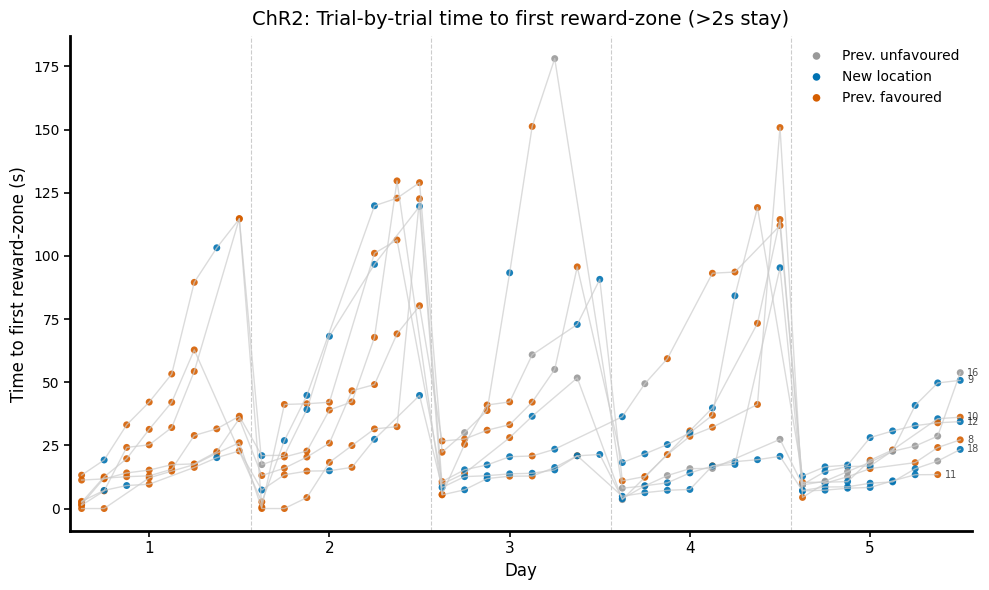

In [ ]:


# ------------------------------------------------------------
# 1) Filter: ChR2, RL/T, usable, not short
# ------------------------------------------------------------
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL = 1..5 from trial_type_day; T = 6 (first T after RL)
mt['plot_day'] = np.nan

mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# Keep only RL days 1–5 for RL
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# Assign test day (6) as first T session after last RL session, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)].copy()

# ------------------------------------------------------------
# 2) Make sure we have a trial-in-day index (1..8)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in mt.columns), None)

if trial_col is not None:
    mt['trial_in_day'] = mt[trial_col].astype(int)
else:
    # Fallback: infer within each (sub, ses)
    mt = mt.sort_values(['sub', 'ses', 't_to_trigger_trig']).copy()
    mt['trial_in_day'] = mt.groupby(['sub', 'ses']).cumcount() + 1

# Keep trials 1–8
mt = mt[mt['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) For each trial, find the FIRST reward zone entered
#    (minimum t_to_trigger_trig across trigger_id)
# ------------------------------------------------------------
# We assume 'trial_id' uniquely identifies a trial; if not, you can use
# ['sub','ses','trial_in_day'] as an alternative key.
group_key = 'trial_id'
if group_key not in mt.columns:
    # Fallback key if trial_id is not present
    group_key = ['sub', 'ses', 'trial_in_day']

idx_first = mt.groupby(group_key)['t_to_trigger_trig'].idxmin()
first_choice = mt.loc[idx_first].copy()

# ------------------------------------------------------------
# 4) Build a "global trial index" across days for plotting:
#    trial_idx_global = (plot_day - 1) * 8 + trial_in_day   (1..48)
# ------------------------------------------------------------
first_choice['trial_idx_global'] = (first_choice['plot_day'] - 1) * 8 + first_choice['trial_in_day']

# ---- Remove test day (plot_day = 6) ----
mt_noT = first_choice[first_choice['plot_day'] <= 5].copy()

# ---- Recompute global trial index for only RL days ----
mt_noT['trial_idx_global'] = (mt_noT['plot_day'] - 1) * 8 + mt_noT['trial_in_day']

fig, ax = plt.subplots(figsize=(10, 6))

zone_colors = {
    1: '#999999',
    2: '#0072B2',
    3: '#D55E00',
}

zone_labels = {
    1: 'Prev. unfavoured',
    2: 'New location',
    3: 'Prev. favoured',
}

# plot each animal as before
for sub in sorted(mt_noT['sub'].unique()):
    ms = mt_noT[mt_noT['sub'] == sub].sort_values(['plot_day','trial_in_day'])

    x = ms['trial_idx_global'].values
    y = ms['t_to_trigger_trig'].values / 1000.0

    ax.plot(
        x, y,
        '-', color='0.8',
        linewidth=1.0,
        alpha=0.7,
        label='_nolegend_'
    )

    for zid in [1,2,3]:
        ms_z = ms[ms['trigger_id']==zid]
        if len(ms_z):
            ax.scatter(
                ms_z['trial_idx_global'].values,
                (ms_z['t_to_trigger_trig'].values)/1000.0,
                s=25,
                color=zone_colors[zid],
                edgecolor='none',
                alpha=0.9,
                label='_nolegend_'
            )

    ax.text(
        x[-1] + 0.3,
        y[-1],
        str(sub),
        fontsize=7,
        alpha=0.7,
        va='center'
    )

# ---- Cosmetics for 5 RL days only ----
max_day = 5
trials_per_day = 8
max_trial_idx = max_day * trials_per_day   # 40

# vertical separators
for d in range(1, max_day):
    ax.axvline(d*trials_per_day + 0.5, color='0.8', linestyle='--', linewidth=0.8)

# x tick labels at center of each day block
day_centers = [(d-0.5)*trials_per_day for d in range(1, max_day+1)]
ax.set_xticks(day_centers)
ax.set_xticklabels([str(d) for d in range(1, max_day+1)], fontsize=11)

ax.set_xlim(0.5, max_trial_idx + 0.5)
ax.set_xlabel('Day', fontsize=12)
ax.set_ylabel('Time to first reward-zone (s)', fontsize=12)

# legend
handles = []
labels = []
for zid in [1,2,3]:
    h = ax.scatter([], [], color=zone_colors[zid], s=30, edgecolor='none')
    handles.append(h)
    labels.append(zone_labels[zid])
ax.legend(handles, labels, frameon=False, loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.0)
ax.spines['left'].set_linewidth(2.0)
ax.tick_params(direction='out', length=4, width=1.2)

ax.set_title('ChR2: Trial-by-trial time to first reward-zone (>2s stay)', fontsize=14, pad=8)

plt.tight_layout()
plt.show()

Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


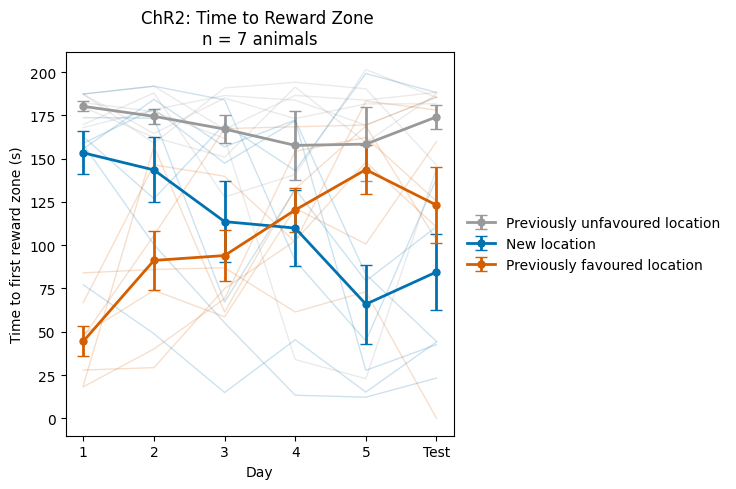

In [34]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, INDIVIDUAL + MEAN -----

plt.figure(figsize=(7.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly, “paper” style colors (similar to ggplot2 palette)
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location (highlighted)
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row / 1000.0,                # ms → s
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals / 1000.0,
        yerr=sem_vals / 1000.0,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

plt.xlabel('Day')
plt.ylabel('Time to first reward zone (s)')
plt.title(
    f'ChR2: Time to Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=12
)

#(≥2 s stay)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout()
plt.show()




Trigger 1: n animals plotted = 7
Trigger 1 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs:
[np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


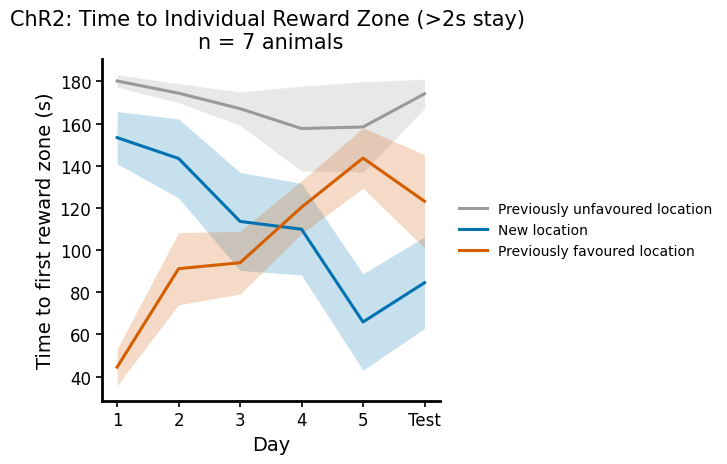

In [35]:
# PLOT time to arrive for remapping group

# ----- FILTER FOR ChR2, RL/T, NOT SHORT, AND ASSIGN DAYS -----

import numpy as np
import matplotlib.pyplot as plt

# Filter: usable already applied above; now restrict further
mt = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# plot_day: RL days = 1–5 from trial_type_day; Test (T) = 6
mt['plot_day'] = np.nan

# RL days: use trial_type_day (assuming it is 1..5)
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 (for RL)
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# For each animal, find first T session AFTER last RL session → plot_day = 6
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

# Keep only days 1–6
plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER -----

def build_trigger_matrix(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['t_to_trigger_trig'].mean()

        # vector [day1..day6]
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:")
    print(subs)
    print("-" * 50)


# ----- PLOT: ChR2, PER TRIGGER, MEAN ± SHADED SEM ONLY -----

plt.figure(figsize=(9, 5))

x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#0072B2',  # New location
    3: '#D55E00',  # Previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    # mean ± SEM in seconds
    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )

    # mean line (no individual traces)
    plt.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# ----- axes + style -----
plt.xlabel('Day', fontsize=14)
plt.ylabel('Time to first reward zone (s)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.tick_params(direction='out', length=4, width=1.2)

plt.title(
    f'ChR2: Time to Individual Reward Zone (>2s stay) \n'
    f'n = {n_animals} animals',
    fontsize=15,
    pad=8
)
#(≥2 s stay)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.8, 0.95])
plt.show()

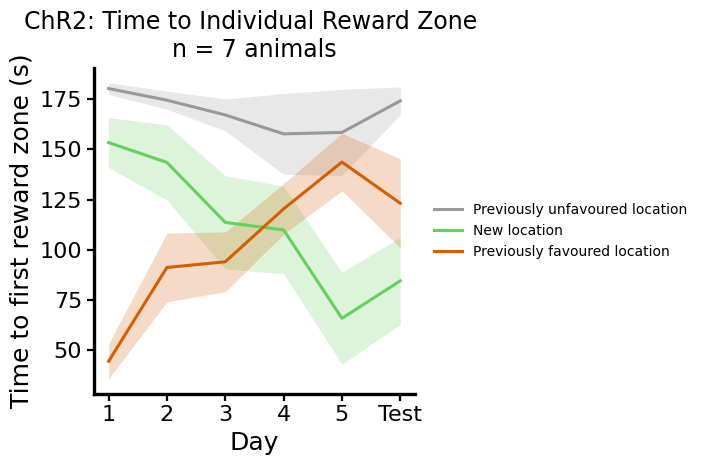

In [40]:
# ChR2 per trigger - clean figure (larger axes, legend right, vector export)
import os

out_dir = "/Users/stella/Desktop/vector_files"
os.makedirs(out_dir, exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 5))
x_vals = plot_days - 1  # 0..5

colors = {
    1: '#999999',  # Previously unfavoured
    2: '#63D15Aff',  # New location
    3: '#D55E00',  # Previously favoured
}
labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or mat.shape[0] == 0:
        continue

    mean_ms = np.nanmean(mat, axis=0)
    sem_ms  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    mean_s = mean_ms / 1000.0
    sem_s  = sem_ms  / 1000.0

    ax.fill_between(
        x_vals,
        mean_s - sem_s,
        mean_s + sem_s,
        color=colors[trig_id],
        alpha=0.22,
        linewidth=0
    )
    ax.plot(
        x_vals,
        mean_s,
        '-',
        color=colors[trig_id],
        linewidth=2.2,
        label=f'{labels[trig_id]}'
    )

# Axes + style (bigger axis text)
ax.set_xlabel('Day', fontsize=18)
ax.set_ylabel('Time to first reward zone (s)', fontsize=18)
ax.set_xticks(np.arange(6))
ax.set_xticklabels(['1', '2', '3', '4', '5', 'Test'], fontsize=16)
ax.tick_params(axis='y', labelsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.4)
ax.spines['left'].set_linewidth(2.4)
ax.tick_params(direction='out', length=5, width=1.6)

ax.set_title(
    f'ChR2: Time to Individual Reward Zone \n'
    f'n = {n_animals} animals',
    fontsize=17,
    pad=8
 )

# Legend to the right
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

fig.tight_layout(rect=[0, 0, 0.8, 0.95])
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_triggers_clean.svg'), bbox_inches='tight')
fig.savefig(os.path.join(out_dir, 'time_to_reward_zone_triggers_clean.pdf'), bbox_inches='tight')
plt.show()

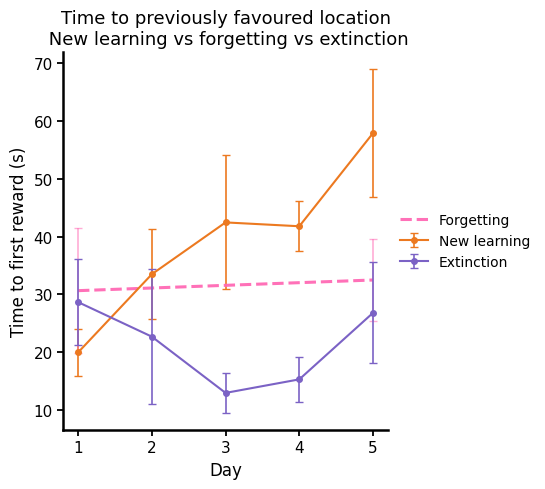

In [25]:

# ============================================================
# 1) RL stage – time to first entry into previously favoured location (trigger 3)
# ============================================================

# Start from your RL/T filter
mt_rl = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'].isin(['RL', 'T']))
].copy()

# Assign plot_day: RL days = 1–5, Test (T) = 6
mt_rl['plot_day'] = np.nan

mask_RL = (mt_rl['trial_type'] == 'RL')
mt_rl.loc[mask_RL, 'plot_day'] = mt_rl.loc[mask_RL, 'trial_type_day']

# keep only RL 1–5 for RL
mt_rl = mt_rl[(~mask_RL) | (mt_rl['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# (We don't really need the T=6 assignment for this analysis, but it won't hurt)
for sub in mt_rl['sub'].unique():
    ms = mt_rl[mt_rl['sub'] == sub]
    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue
    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue
    first_T_ses = T_after['ses'].min()
    idx = mt_rl.index[
        (mt_rl['sub'] == sub) &
        (mt_rl['trial_type'] == 'T') &
        (mt_rl['ses'] == first_T_ses)
    ]
    mt_rl.loc[idx, 'plot_day'] = 6

# We only care about RL days 1–5 here
rl_days = np.arange(1, 6)

def rl_fav_stats(mt_rl, trigger_id=3):
    """
    Time to first entry into 'previously favoured' trigger for RL days 1–5.
    Returns mean_s, sem_s (seconds), each length 5.
    """
    df = mt_rl[
        (mt_rl['trigger_id'] == trigger_id) &
        (mt_rl['trial_type'] == 'RL') &
        (mt_rl['plot_day'].isin(rl_days))
    ].copy()

    mean_ms = np.full(len(rl_days), np.nan)
    sem_ms  = np.full(len(rl_days), np.nan)

    for i, d in enumerate(rl_days):
        df_day = df[df['plot_day'] == d]
        if df_day.empty:
            continue

        # average per animal first, then across animals
        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0  # seconds

mean_rl_s, sem_rl_s = rl_fav_stats(mt_rl, trigger_id=3)


# ============================================================
# 2) Forgetting / extinction – time to first entry into favoured zone (trigger 2)
# ============================================================

# Filter: ChR2, TEST, usable, not short, forgetting/extinction
meta_T = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['test_type'].isin(['forgetting','extinction'])) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

test_days = np.arange(1, 6)  # test days 1–5

def build_time_to_zone2(meta_df):
    """
    For a meta_df subset (forgetting or extinction),
    compute time to trigger_id=2 per test day (1–5):

    1) mean per subject per day
    2) mean & SEM across subjects

    Returns mean_s, sem_s (seconds), length 5.
    """
    df = meta_df[meta_df['trigger_id'] == 2].copy()
    mean_ms = np.full(len(test_days), np.nan)
    sem_ms  = np.full(len(test_days), np.nan)

    for i, d in enumerate(test_days):
        df_day = df[df_day['trial_type_day'] == d] if False else df[df['trial_type_day'] == d]  # keep logic clear
        if df_day.empty:
            continue

        per_sub = (
            df_day.groupby('sub')['t_to_trigger_trig']
            .mean()
        )
        vals = per_sub.values.astype(float)
        if vals.size == 0:
            continue

        mean_ms[i] = np.nanmean(vals)
        if vals.size > 1:
            sem_ms[i] = np.nanstd(vals, ddof=1) / np.sqrt(vals.size)

    return mean_ms / 1000.0, sem_ms / 1000.0   # seconds


meta_forg = meta_T[meta_T['test_type'] == 'forgetting'].copy()
meta_ext  = meta_T[meta_T['test_type'] == 'extinction'].copy()

mean_forg_s, sem_forg_s = build_time_to_zone2(meta_forg)
mean_ext_s,  sem_ext_s  = build_time_to_zone2(meta_ext)


# ============================================================
# 3) Combined plot: RL + forgetting/extinction favoured zone
# ============================================================

plt.figure(figsize=(7, 5))

# ---- RL previously favoured location (solid, orange) ----
plt.errorbar(
    rl_days, mean_rl_s, yerr=sem_rl_s,
    fmt='-o',
    color="#EC7920",         # unchanged
    ecolor="#EC7920",
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='New learning'
)

# ---- colours for test trials ----
col_f = '#FF69B4'   # pastel green (forgetting)
col_e = '#7b62c5ff'   # pastel purple (extinction)


# ---- Forgetting (only day 1 & 5, dashed) ----
forget_days = np.array([1, 5])
x_f = forget_days
y_f = np.array([mean_forg_s[0], mean_forg_s[4]])
e_f = np.array([sem_forg_s[0],  sem_forg_s[4]])

plt.plot(
    x_f, y_f,
    '--',
    color=col_f,
    linewidth=2.2,
    alpha=0.95,
    label='Forgetting'
)
plt.errorbar(
    x_f, y_f, yerr=e_f,
    fmt='none',
    ecolor=col_f,
    alpha=0.55,
    capsize=3,
    elinewidth=1.2
)

# ---- Extinction (day 1–5, solid) ----
plt.errorbar(
    test_days, mean_ext_s, yerr=sem_ext_s,
    fmt='-o',
    color=col_e,
    ecolor=col_e,
    elinewidth=1.2,
    capsize=3,
    markersize=4,
    label='Extinction'
)

# ---- Axes, style ----
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.3)

plt.xlabel('Day', fontsize=12)
plt.ylabel('Time to first reward (s)', fontsize=12)
plt.xticks(rl_days, [str(d) for d in rl_days], fontsize=11)
plt.yticks(fontsize=11)

plt.title('Time to previously favoured location\n New learning vs forgetting vs extinction', fontsize=13, pad=6)
#(>2s stay)

plt.legend(
    frameon=False,
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.
)

plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

N per group (day 5):
  RL (RL day 5, trig3):          7
  Forgetting (Test day 5, trig2): 8
  Extinction (Test day 5, trig2): 7
RL vs Forg: raw p = 0.152
RL vs Ext: raw p = 0.62
Forg vs Ext: raw p = 0.397

FDR-corrected p-values (Benjamini–Hochberg):
  RL vs Forg: p_FDR = 0.456
  RL vs Ext: p_FDR = 0.62
  Forg vs Ext: p_FDR = 0.595


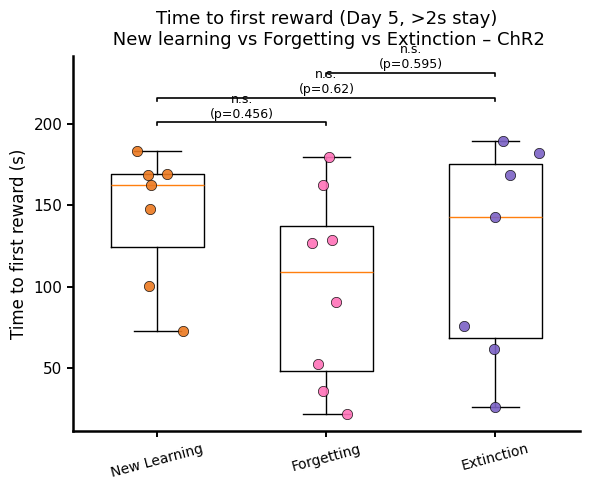

In [ ]:

from scipy.stats import mannwhitneyu

# Try to import statsmodels for FDR correction
try:
    from statsmodels.stats.multitest import multipletests
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print("Warning: statsmodels not installed → FDR correction skipped (raw p-values used).")

# ------------------------------------------------------------
# 1) Extract data for the three groups (all ChR2)
#    - RL day 5, trigger_id = 3  (previously favoured)
#    - Forgetting test day 5, trigger_id = 2
#    - Extinction test day 5, trigger_id = 2
#    Using time to trigger per animal (mean across trials)
# ------------------------------------------------------------

# ---- RL day 5 (RL, trig=3, day=5) ----
rl_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'RL') &
    (meta_trig['trigger_id'] == 3) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

rl_per_sub = (
    rl_df.groupby('sub')['t_to_trigger_trig']
         .mean()
         .astype(float)
)
vals_rl = (rl_per_sub.values / 1000.0)  # ms → s

# ---- Forgetting day 5 (T, trig=2, day=5) ----
forg_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'forgetting') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

forg_per_sub = (
    forg_df.groupby('sub')['t_to_trigger_trig']
           .mean()
           .astype(float)
)
vals_forg = (forg_per_sub.values / 1000.0)  # ms → s

# ---- Extinction day 5 (T, trig=2, day=5) ----
ext_df = meta_trig[
    (meta_trig['usable'] == 1) &
    (meta_trig['short_duration'] != 1) &
    (meta_trig['genotype'] == 'ChR2') &
    (meta_trig['trial_type'] == 'T') &
    (meta_trig['test_type'] == 'extinction') &
    (meta_trig['trigger_id'] == 2) &
    (meta_trig['trial_type_day'] == 5) &
    (meta_trig['t_to_trigger_trig'].notna())
].copy()

ext_per_sub = (
    ext_df.groupby('sub')['t_to_trigger_trig']
          .mean()
          .astype(float)
)
vals_ext = (ext_per_sub.values / 1000.0)  # ms → s

print("N per group (day 5):")
print("  RL (RL day 5, trig3):         ", len(vals_rl))
print("  Forgetting (Test day 5, trig2):", len(vals_forg))
print("  Extinction (Test day 5, trig2):", len(vals_ext))

# ------------------------------------------------------------
# 2) Prepare boxplot data
# ------------------------------------------------------------
groups = ["New Learning", "Forgetting", "Extinction"]
data   = [vals_rl, vals_forg, vals_ext]
positions = np.arange(len(groups))

# simple colour scheme (consistent with earlier line plots)
colors = {
    "New Learning":         "#EC7920",  # orange
    "Forgetting": '#FF72B8', # pink
    "Extinction": '#7b62c5ff'   #  purple
}

# ------------------------------------------------------------
# 3) Boxplot + jittered individual points
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

# plain black boxes, no fliers
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.55,
    patch_artist=False,
    showfliers=False
)

# jittered animal points
for i, g in enumerate(groups):
    vals = data[i]
    if len(vals) == 0:
        continue
    jitter = 0.10
    x = np.random.normal(positions[i], jitter, size=len(vals))
    ax.scatter(
        x, vals,
        s=55,
        color=colors[g],
        edgecolor='k',
        linewidth=0.5,
        alpha=0.9,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Mann–Whitney tests + FDR + significance stars
# ------------------------------------------------------------
def mannwhitney_safe(a, b):
    if (len(a) < 1) or (len(b) < 1):
        return np.nan
    stat, p = mannwhitneyu(a, b, alternative='two-sided')
    return p

p_raw = []

comparisons = [
    ("RL vs Forg",      0, 1, vals_rl,  vals_forg),
    ("RL vs Ext",       0, 2, vals_rl,  vals_ext),
    ("Forg vs Ext",     1, 2, vals_forg, vals_ext)
]

for name, i1, i2, v1, v2 in comparisons:
    p = mannwhitney_safe(v1, v2)
    p_raw.append(p)
    print(f"{name}: raw p = {p:.3g}" if not np.isnan(p) else f"{name}: p = NaN")

p_raw = np.array(p_raw, dtype=float)

# FDR correction (if statsmodels available)
if HAS_SM:
    mask_valid = ~np.isnan(p_raw)
    p_adj = p_raw.copy()
    if mask_valid.any():
        rej, p_corr, _, _ = multipletests(p_raw[mask_valid], alpha=0.05, method='fdr_bh')
        p_adj[mask_valid] = p_corr
    print("\nFDR-corrected p-values (Benjamini–Hochberg):")
    for (name, *_), p_corr_val in zip(comparisons, p_adj):
        print(f"  {name}: p_FDR = {p_corr_val:.3g}")
else:
    p_adj = p_raw
    print("\nUsing raw p-values for annotation (no FDR correction).")

def p_to_stars(p):
    if np.isnan(p):   return "n.s."
    if p < 1e-4:      return "****"
    if p < 1e-3:      return "***"
    if p < 1e-2:      return "**"
    if p < 0.05:      return "*"
    return "n.s."

# Add significance bars above boxes
all_vals = np.concatenate([v for v in data if len(v) > 0])
y_max = np.nanmax(all_vals)
y_step = 0.08 * y_max  # vertical spacing

# start a bit above max
current_y = y_max * 1.05

for (name, x1, x2, _, _), p in zip(comparisons, p_adj):
    stars = p_to_stars(p)
    # draw only if we have at least a valid p
    if np.isnan(p):
        continue

    # bar
    ax.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.01 * y_max, current_y + 0.01 * y_max, current_y],
        color='k',
        linewidth=1.2
    )
    # text (stars + p)
    ax.text(
        (x1 + x2) / 2,
        current_y + 0.015 * y_max,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # move up for next comparison

# ------------------------------------------------------------
# 5) Axes, labels, style
# ------------------------------------------------------------
ax.set_xticks(positions)
ax.set_xticklabels(groups, rotation=15)
ax.set_ylabel('Time to first reward (s)', fontsize=12)
ax.set_xlabel('')
ax.set_title('Time to first reward (Day 5, >2s stay)\n New learning vs Forgetting vs Extinction – ChR2', fontsize=13, pad=8)

# Nature-ish style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.8)
ax.spines['left'].set_linewidth(1.8)
ax.tick_params(direction='out', length=4, width=1.4)
plt.yticks(fontsize=11)
plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

Pct time in trigger zone

In [361]:
# Compute pct time in trigger zone


metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    
  
    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    total_time_in_trigger = df_all_triggers['duration'].sum()

    # Trial duration: max time in this trial (same units as duration)
    trial_duration = position_['t'].max()

    if trial_duration > 0:
        pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    else:
        pct_time_in_trigger = np.nan

    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger


 11%|█▏        | 522/4609 [00:05<00:42, 96.80it/s] 


KeyboardInterrupt: 

In [20]:
# test day plot + rank sum test

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
 #  (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

#groups = ['ChR2', 'eYFP_ChR2']
groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}


# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group','animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data
data = [meta_animal.loc[meta_animal['group']==g, 'pct_time_in_trigger'].values
        for g in groups]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # keep plain black box
    showfliers=False      # <-- turn off those empty circles
)


# individual animal points
for i, g in enumerate(groups):
    vals = meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    n = len(vals)

    # wider jitter for dense groups
    jitter = 0.12 if n < 6 else 0.12  # adjust if needed

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum test (Mann–Whitney U) + stars
# ------------------------------------------------------------
vals_ch = data[0]  # ChR2
vals_yf = data[1]  # eYFP_ChR2

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax = max(np.nanmax(vals_ch), np.nanmax(vals_yf))
# put the line a bit above the max data point
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between the two boxes (x=0 and x=1)
plt.plot([0, 0, 1, 1], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

# text with stars + p-value
plt.text(0.5, y_star, f"{stars} (p={p:.3g})",
         ha='center', va='bottom', fontsize=11)

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, 45)

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

KeyError: 'pct_time_in_trigger'

ChR2 long animals plotted : 12
ChR2 short animals plotted: 3
eYFP_ChR2 animals plotted : 5
Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = 0.0357


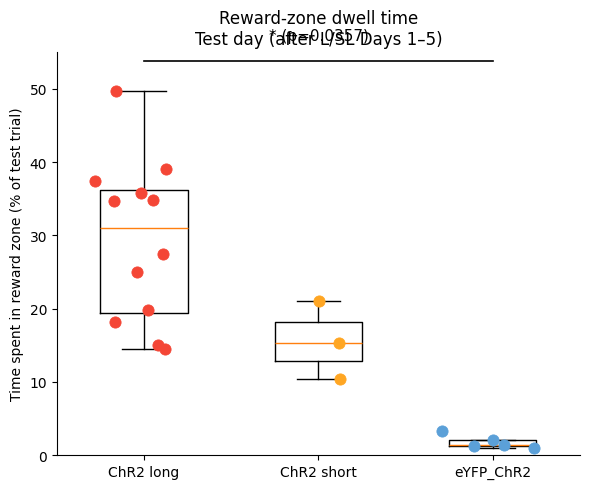

In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 0) Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T'])) &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['sub'] != 17)
].copy()

plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1) Helper: build subject × day matrix (enforces L/SL days 1–5
#    + FIRST T session AFTER last learning session as day 6)
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) pct_time_in_trigger per day
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # subset by genotype and L/SL + T
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal (L or SL)
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # assign learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # ----- KEY LINE: first T session AFTER last learning session -----
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2) Build matrices for the three groups
#    Group 1: ChR2 long (L, short_duration=0)
#    Group 2: eYFP_ChR2 (L, any short_duration)
#    Group 3: ChR2 short (SL, short_duration=1)
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long animals plotted :", len(subs_ChR2_long))
print("ChR2 short animals plotted:", len(subs_ChR2_short))
print("eYFP_ChR2 animals plotted :", len(subs_eYFP))


# ------------------------------------------------------------
# 3) Extract TEST DAY (day 6) values for each animal
#     → matrices are (n_animals x 6), index 5 = test day
# ------------------------------------------------------------
vals_ChR2_long  = mat_ChR2_long[:, 5]   # Day 6
vals_ChR2_short = mat_ChR2_short[:, 5]
vals_eYFP       = mat_eYFP[:, 5]

groups = ['ChR2 long', 'ChR2 short', 'eYFP_ChR2']
data   = [vals_ChR2_long, vals_ChR2_short, vals_eYFP]

colors = {
    'ChR2 long'  : get_genotype_color('ChR2'),
    'ChR2 short' : get_genotype_color('ChR2_short'),
    'eYFP_ChR2'  : get_genotype_color('eYFP_ChR2')
}

# ------------------------------------------------------------
# 4) Plot boxplot + jittered animal points + animal labels
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,
    showfliers=False
)

for i, g in enumerate(groups):
    vals = data[i]
    subs = [subs_ChR2_long, subs_ChR2_short, subs_eYFP][i]   # matching subject lists
    n = len(vals)

    jitter = 0.12
    x = np.random.normal(i, jitter, size=n)

    # plot points
    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )


# ------------------------------------------------------------
# 5) Rank-sum (Mann–Whitney) for ChR2_long vs eYFP_ChR2
#    (line between box 0 and box 2; ChR2_short is box 1)
# ------------------------------------------------------------
vals_ch = vals_ChR2_short
vals_yf = vals_eYFP

stat, p = mannwhitneyu(vals_ch, vals_yf, alternative='two-sided')
print(f"Mann–Whitney U (ChR2 short vs eYFP_ChR2) p = {p:.3g}")

def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

stars = p_to_stars(p)

ymax  = np.nanmax(np.concatenate([vals_ChR2_long, vals_ChR2_short, vals_eYFP]))
y_line = ymax * 1.08
y_star = ymax * 1.13

# horizontal line between x=0 (ChR2 long) and x=2 (eYFP_ChR2)
plt.plot([0, 0, 2, 2], [y_line, y_line, y_line, y_line],
         color='black', linewidth=1.2)

plt.text(
    1.0, y_star,
    f"{stars} (p={p:.3g})",
    ha='center', va='bottom', fontsize=11
)


# ------------------------------------------------------------
# 6) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups, rotation=0)
plt.ylim(0, 55)

plt.ylabel('Time spent in reward zone (% of test trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day (after L/SL Days 1–5)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

        group  animal  pct_time_in_trigger
0        ChR2       1            29.578657
1        ChR2       3            35.765130
2        ChR2       4            34.803665
3        ChR2       6            19.793126
4        ChR2       7            11.939570
5        ChR2       8            30.509764
6        ChR2       9            25.763918
7        ChR2      10            16.308726
8        ChR2      11            12.028290
9        ChR2      12            23.016142
10       ChR2      16             9.566117
11       ChR2      18            19.745282
12         Hp      40             5.255492
13         Hp      41             4.780728
14         Hp      42             1.849510
15         Hp      43             2.079009
16         Hp      44             2.451215
17         Hp      45             6.376267
18         Hp      46             6.236343
19  eYFP_ChR2      19             2.327057
20  eYFP_ChR2      20             2.105439
21  eYFP_ChR2      21             0.701039
22  eYFP_Ch

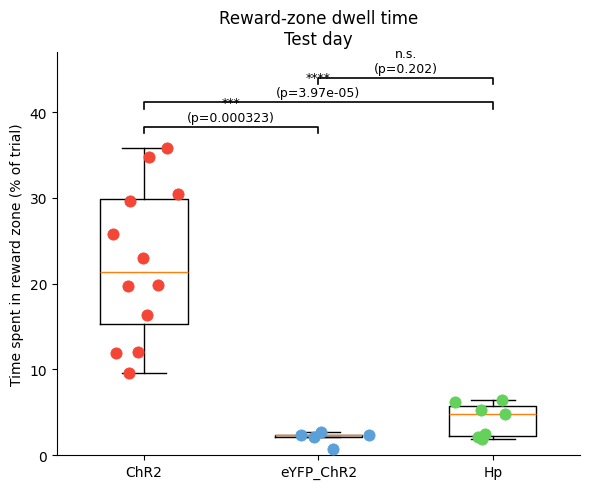

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------
# 1) Filter TEST trials only (now incl. Hp)
# ------------------------------------------------------------
meta_T = metadata[
    (metadata['usable'] == 1) &
    (metadata['trial_type'] == 'T') &
    (metadata['pct_time_in_trigger'].notna()) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].copy()

meta_T['group'] = meta_T['genotype']
meta_T['animal'] = meta_T['sub']

groups = ['ChR2', 'eYFP_ChR2', 'Hp']
colors = {g: get_genotype_color(g) for g in groups}

# ------------------------------------------------------------
# 2) Collapse to one point per animal (mean TEST dwell)
# ------------------------------------------------------------
meta_animal = (
    meta_T.groupby(['group', 'animal'])['pct_time_in_trigger']
          .mean()
          .reset_index()
)

print(meta_animal)

# prepare boxplot data in group order
data = [
    meta_animal.loc[meta_animal['group'] == g, 'pct_time_in_trigger'].values
    for g in groups
]

# ------------------------------------------------------------
# 3) Plot
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))

bp = plt.boxplot(
    data,
    positions=np.arange(len(groups)),
    widths=0.5,
    patch_artist=False,   # plain black box
    showfliers=False      # no empty circles
)

# individual animal points
for i, g in enumerate(groups):
    vals = data[i]
    n = len(vals)

    if n == 0:
        continue

    jitter = 0.12 if n < 6 else 0.12

    x = np.random.normal(i, jitter, size=n)

    plt.scatter(
        x, vals,
        s=65,
        color=colors[g],
        linewidth=0.6,
        zorder=3
    )

# ------------------------------------------------------------
# 4) Rank-sum tests (Mann–Whitney U) + stars for all pairs
# ------------------------------------------------------------
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 0.05: return "*"
    return "n.s."

# all pairs: (ChR2 vs eYFP), (ChR2 vs Hp), (eYFP vs Hp)
pairs = [(0, 1), (0, 2), (1, 2)]

# base height for annotations
all_vals = np.concatenate([d for d in data if len(d) > 0])
ymax = np.nanmax(all_vals)
y_step = ymax * 0.08
current_y = ymax * 1.05

for (i, j) in pairs:
    vals_i = data[i]
    vals_j = data[j]

    # skip if any group empty
    if len(vals_i) == 0 or len(vals_j) == 0:
        continue

    stat, p = mannwhitneyu(vals_i, vals_j, alternative='two-sided')
    print(f"{groups[i]} vs {groups[j]}: Mann–Whitney U p = {p:.3g}")

    stars = p_to_stars(p)

    x1, x2 = i, j
    x_mid = (x1 + x2) / 2.0

    # bracket line
    plt.plot(
        [x1, x1, x2, x2],
        [current_y, current_y + 0.02*ymax, current_y + 0.02*ymax, current_y],
        color='black',
        linewidth=1.2
    )

    # text (stars + p)
    plt.text(
        x_mid,
        current_y + 0.03*ymax,
        f"{stars}\n(p={p:.3g})",
        ha='center',
        va='bottom',
        fontsize=9
    )

    current_y += y_step  # stack brackets upward

# ------------------------------------------------------------
# 5) Axes / labels
# ------------------------------------------------------------
plt.xticks(np.arange(len(groups)), groups)
plt.ylim(0, max(45, current_y + y_step * 0.3))

plt.ylabel('Time spent in reward zone (% of trial)')
plt.xlabel('')
plt.title('Reward-zone dwell time\nTest day')

# clean axes (keep only left + bottom)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

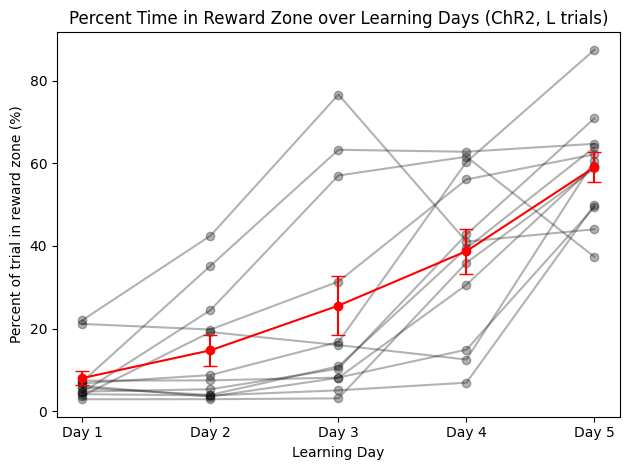

In [73]:
# Restrict to ChR2 learning trials
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2') &
    (metadata['short_duration'] != 1)  # exclude short-duration trials
].reset_index(drop=True)

performance_mat = []

plt.figure()

for sub in metadata_L['sub'].unique():
    meta_sub = metadata_L[metadata_L['sub'] == sub]

    # Mean % time in trigger zone per training day
    mean_pct_by_day = meta_sub.groupby('trial_type_day')['pct_time_in_trigger'].mean()
    mean_pct_by_day = mean_pct_by_day.sort_index()

    # Expect 5 days; skip incomplete animals
    if len(mean_pct_by_day) != 5:
        continue

    performance_mat.append(mean_pct_by_day.values)

    # Individual subject traces (thin black)
    plt.plot(range(5), mean_pct_by_day.values, '-o', color='k', alpha=0.3)

# Group mean ± SEM
performance_mat = np.vstack(performance_mat)
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])

plt.errorbar(
    range(5),
    mean_performance,
    yerr=sem_performance,
    fmt='-o',
    color='r',
    capsize=5
)

plt.xlabel('Learning Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone over Learning Days (ChR2, L trials)')
plt.xticks(range(5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 12
ChR2 animals plotted: 12
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


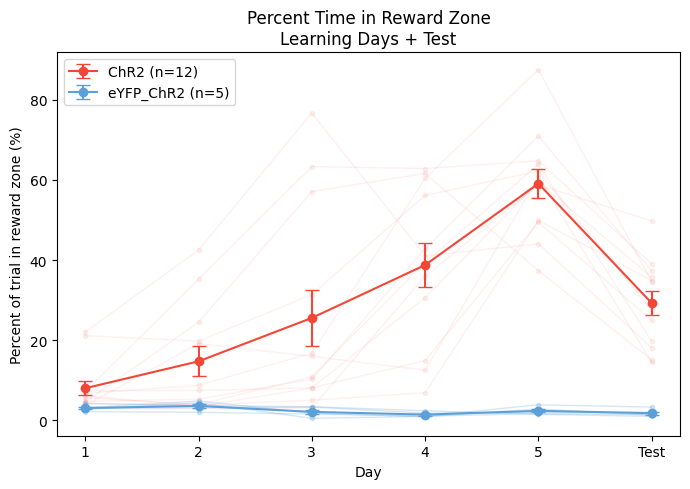

In [128]:
# plot ChR2 & eYFP_ChR2 learning trials + first test day (by session) after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2
if mat_ChR2 is not None:
    col_c = get_genotype_color('ChR2')

    # individual traces
    for row in mat_ChR2:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_c,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(
        x_vals, mean_c, yerr=sem_c,
        fmt='-o',
        color=col_c,
        capsize=5,
        label=f'ChR2 (n={len(subs_ChR2)})'
    )

# eYFP_ChR2
if mat_eYFP is not None:
    col_y = get_genotype_color('eYFP_ChR2')

    # individual traces
    for row in mat_eYFP:
        plt.plot(
            x_vals, row,
            '-o',
            color=col_y,
            alpha=0.25,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )

    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(
        x_vals, mean_y, yerr=sem_y,
        fmt='-o',
        color=col_y,
        capsize=5,
        label=f'eYFP_ChR2 (n={len(subs_eYFP)})'
    )

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

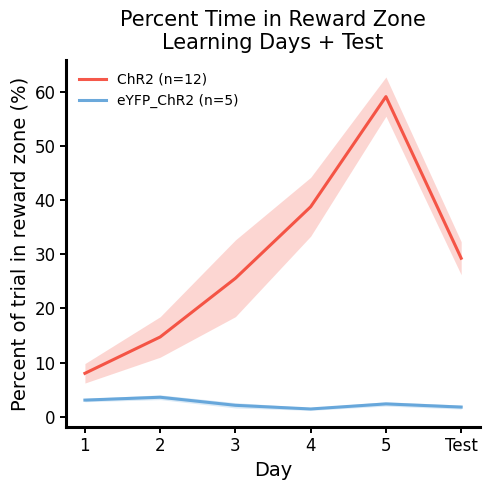

In [127]:
# ---------------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, journal-style
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5

def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) values of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individual traces)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )

# --- plot both groups using your color function ---
plot_group_shaded(
    mat_ChR2,
    subs_ChR2,
    genotype_key='ChR2',
    label='ChR2'
)

plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2'
)

# ---------------------------------------------------------------------
# Axes + style
# ---------------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(np.arange(6), ['1', '2', '3', '4', '5', 'Test'], fontsize=12)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5
  Hp: 7


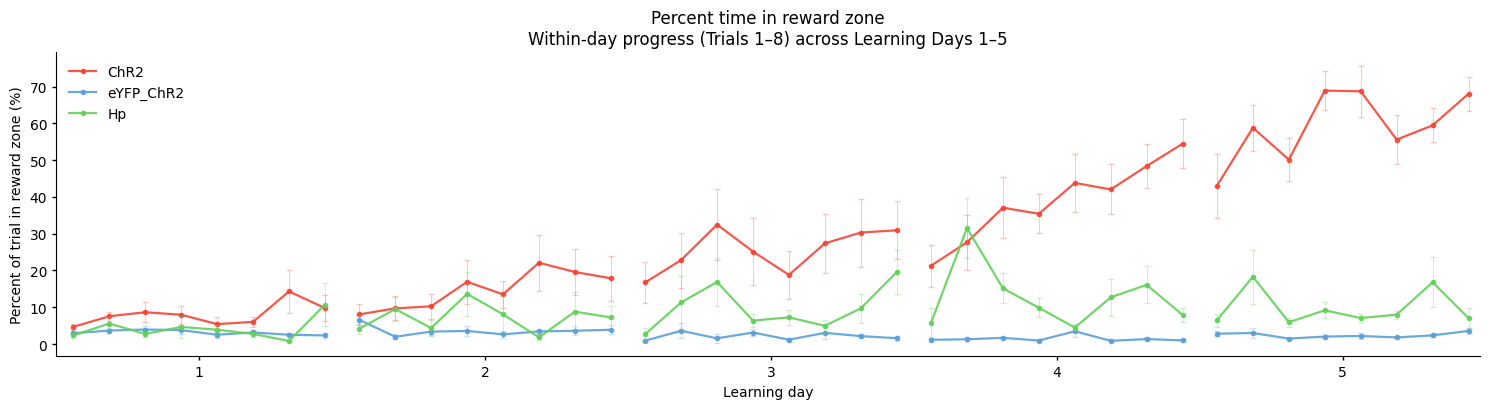

In [ ]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_time_in_trigger (% of trial in reward zone)
# Groups: ChR2 vs eYFP_ChR2  (others available via comments)
# ============================================================

# ------------------------------------------------------------
# 1) Filter: usable, not short, genotypes, L only, days 1–5
# ------------------------------------------------------------
meta_L = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    # (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    # (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &  ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'] == 'L') &
    # (metadata['trial_type'].isin(['L', 'SL'])) &
    (metadata['trial_type_day'].isin([1, 2, 3, 4, 5])) &
    (metadata['pct_time_in_trigger'].notna())
].copy()

days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 (prefer existing col else infer)
# ------------------------------------------------------------
candidate_cols = [
    'trial_in_day', 'trial_num', 'trial_number', 'trial', 'trial_idx',
    'trial_index', 'trial_in_session', 'trial_id_in_session'
]
trial_col = next((c for c in candidate_cols if c in meta_L.columns), None)

if trial_col is not None:
    meta_L['trial_in_day'] = meta_L[trial_col].astype(int)
else:
    meta_L = meta_L.sort_values(['sub', 'ses']).copy()
    meta_L['trial_in_day'] = meta_L.groupby(['sub', 'ses']).cumcount() + 1

meta_L = meta_L[meta_L['trial_in_day'].between(1, 8)].copy()

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day (allow missing)
# ------------------------------------------------------------
def subject_trial_matrix_for_day(meta_g, day):
    md = meta_g[meta_g['trial_type_day'] == day]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_time_in_trigger'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials])
        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves using color function
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key, label=None, alpha=1.0):
    """
    genotype_key: key for get_genotype_color, e.g.
                  'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp', ...
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # for showing legend label once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # ---- mean line ----
        ax.plot(
            x, mean_,
            'o-',
            color=col,
            alpha=alpha,
            linewidth=1.6,
            markersize=3,
            label=label if first_day and (label is not None) else None
        )

        # ---- SEM bars (faded) ----
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=col,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

        first_day = False

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Split by genotype (all options kept)
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
# meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
# meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
# meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# if plotting for short duration:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()
#
# meta_eYFP_L = meta_L[
#     (meta_L['genotype'] == 'eYFP_ChR2') &
#     (meta_L['trial_type'] == 'L')
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())
# print("  ChR2 long:", meta_ChR2_long['sub'].nunique())
# print("  ChR2 short:", meta_ChR2_short['sub'].nunique())

# ------------------------------------------------------------
# 7) Plot (wider; centered day labels under each day's curve)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha=0.9
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha=0.9
)

# other groups, ready to use when you want:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha=0.7
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha=0.9
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curve fully visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included (n):
  ChR2: 12
  eYFP_ChR2: 5


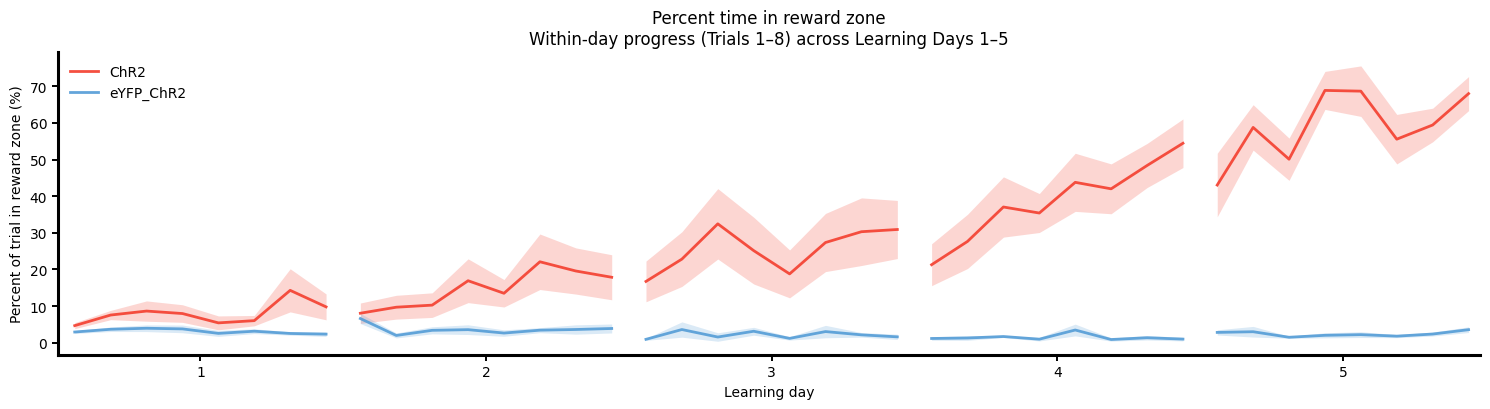

In [134]:
# ------------------------------------------------------------
# 4) Plot helper: within-day curves with shaded SEM
#    (mean ± SEM only; no individual background lines)
# ------------------------------------------------------------
def plot_within_day_curves(ax, meta_g, genotype_key,
                           label=None,
                           alpha_fill=0.22,
                           alpha_line=0.9):
    """
    meta_g:   subset of metadata for a given group
    genotype_key: key for get_genotype_color, e.g. 'ChR2', 'eYFP_ChR2', 'ChR2_short', 'Hp'
    label:    legend label (shown once per group)
    """
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin
    col = get_genotype_color(genotype_key)

    first_day = True  # to only add legend entry once

    for day in days:
        mat = subject_trial_matrix_for_day(meta_g, day)
        if mat is None:
            continue

        x = day + offsets

        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # shaded SEM band
        ax.fill_between(
            x,
            mean_ - sem_,
            mean_ + sem_,
            color=col,
            alpha=alpha_fill,
            linewidth=0
        )

        # mean line (no markers)
        ax.plot(
            x, mean_,
            '-',
            color=col,
            alpha=alpha_line,
            linewidth=2.0,
            label=label if first_day and (label is not None) else None
        )

        first_day = False


# ------------------------------------------------------------
# 5) Nature-style axes (thicker frame)
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['bottom'].set_linewidth(2.2)
    ax.spines['left'].set_linewidth(2.2)

    ax.tick_params(direction='out', length=4, width=1.4)
    ax.grid(False)


# ------------------------------------------------------------
# 6) Split by genotype
# ------------------------------------------------------------
meta_ChR2 = meta_L[meta_L['genotype'] == 'ChR2'].copy()
meta_eYFP = meta_L[meta_L['genotype'] == 'eYFP_ChR2'].copy()
#meta_Hp   = meta_L[meta_L['genotype'] == 'Hp'].copy()
#meta_ChR2 = meta_L[meta_L['genotype'] == 'F231A'].copy()
#meta_eYFP = meta_L[meta_L['genotype'] == 'F231A_wt'].copy()

# If plotting long vs short separately later:
# meta_ChR2_long = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'L') &
#     (meta_L['short_duration'] == 0)
# ].copy()
#
# meta_ChR2_short = meta_L[
#     (meta_L['genotype'] == 'ChR2') &
#     (meta_L['trial_type'] == 'SL') &
#     (meta_L['short_duration'] == 1)
# ].copy()

print("Animals included (n):")
print("  ChR2:", meta_ChR2['sub'].nunique())
print("  eYFP_ChR2:", meta_eYFP['sub'].nunique())
# print("  Hp:", meta_Hp['sub'].nunique())


# ------------------------------------------------------------
# 7) Plot (mean curves + shaded SEM)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

# main two groups
plot_within_day_curves(
    ax,
    meta_ChR2,
    genotype_key='ChR2',
    label='ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

plot_within_day_curves(
    ax,
    meta_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2',
    alpha_fill=0.22,
    alpha_line=0.95
)

# If you later want Hp:
# plot_within_day_curves(
#     ax,
#     meta_Hp,
#     genotype_key='Hp',
#     label='Hp',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

# If you later want ChR2 long vs ChR2_short:
# plot_within_day_curves(
#     ax,
#     meta_ChR2_long,
#     genotype_key='ChR2',
#     label='ChR2 long',
#     alpha_fill=0.18,
#     alpha_line=0.9
# )
#
# plot_within_day_curves(
#     ax,
#     meta_ChR2_short,
#     genotype_key='ChR2_short',
#     label='ChR2 short',
#     alpha_fill=0.22,
#     alpha_line=0.95
# )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Put day labels in the middle of each day's cluster
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Reduce left whitespace and ensure day 5 curves are visible
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'Percent time in reward zone\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in meta_ChR2: 10
ChR2 animals plotted: 10
eYFP_ChR2 animals in meta_eYFP: 5
eYFP_ChR2 animals plotted: 5


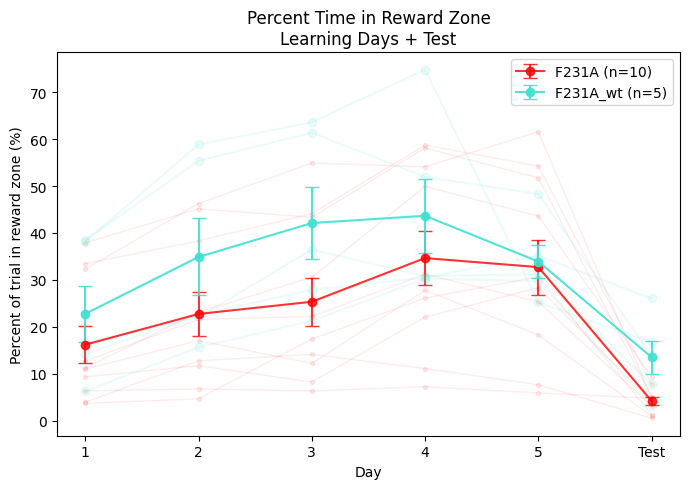

In [48]:
# plot f231a vs wt learning trials + first test day (by session) after learning


# ---------------------------------------------------------------------
# 1. Filter metadata: usable, not short, two genotypes, L or T
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['F231A', 'F231A_wt'])) &
         ~(metadata['id'].isin(['BQ', 'BP'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create a "plot_day" column:
# - For L trials: use trial_type_day (1–5)
# - For T trials: we will later set the *first test session after learning* to day 6
meta_LT['plot_day'] = np.nan

mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']

# ---------------------------------------------------------------------
# 1b. For each animal, find the first T *session* after the last L session
#      and assign plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    # learning sessions for this animal
    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    # test trials that occur in later sessions than the last learning session
    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue  # no post-learning test session for this animal

    first_T_ses = T_after['ses'].min()

    # assign plot_day = 6 to all T trials in that first post-learning test session
    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6

# We expect days 1–6 now (L1–L5 + first T-after-learning as day 6)
plot_days = np.arange(1, 7)  # [1,2,3,4,5,6]

# ---------------------------------------------------------------------
# 2. Helper to build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    For a given genotype subset (e.g. ChR2),
    returns:
      - perf_mat: array (n_subjects x 6) with NaNs for missing days
      - subjects: list of subject IDs included

    Only keeps animals that have values for *all 6 days* (1–6).
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        # mean % time in trigger zone per plot_day for this animal
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days (no NaNs)
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

# Split by genotype
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'F231A']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'F231A_wt']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)

print("ChR2 animals in meta_ChR2:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP_ChR2 animals in meta_eYFP:", meta_eYFP['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

# ---------------------------------------------------------------------
# 3. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

# ChR2: red
if mat_ChR2 is not None:
    # individual traces
    for row in mat_ChR2:
        plt.plot(x_vals, row, '-o', color='red', alpha=0.08, linewidth=1, markersize=3, label='_nolegend_')
    # group mean ± SEM
    mean_c = np.nanmean(mat_ChR2, axis=0)
    sem_c  = np.nanstd(mat_ChR2, axis=0) / np.sqrt(mat_ChR2.shape[0])
    plt.errorbar(x_vals, mean_c, yerr=sem_c, fmt='-o', color='red', alpha=0.8,
                 capsize=5, label=f'F231A (n={len(subs_ChR2)})')

# eYFP_ChR2: turquoise
if mat_eYFP is not None:
    for row in mat_eYFP:
        plt.plot(x_vals, row, '-o', color='turquoise', alpha=0.1, label='_nolegend_')
    mean_y = np.nanmean(mat_eYFP, axis=0)
    sem_y  = np.nanstd(mat_eYFP, axis=0) / np.sqrt(mat_eYFP.shape[0])
    plt.errorbar(x_vals, mean_y, yerr=sem_y, fmt='-o', color='turquoise', alpha=0.90,
                 capsize=5, label=f'F231A_wt (n={len(subs_eYFP)})')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

ChR2 long (short_duration=0) animals in data: 12
ChR2 long animals plotted: 12
eYFP_ChR2 animals in data: 5
eYFP_ChR2 animals plotted: 5
ChR2 short (short_duration=1) animals in data: 4
ChR2 short animals plotted: 4


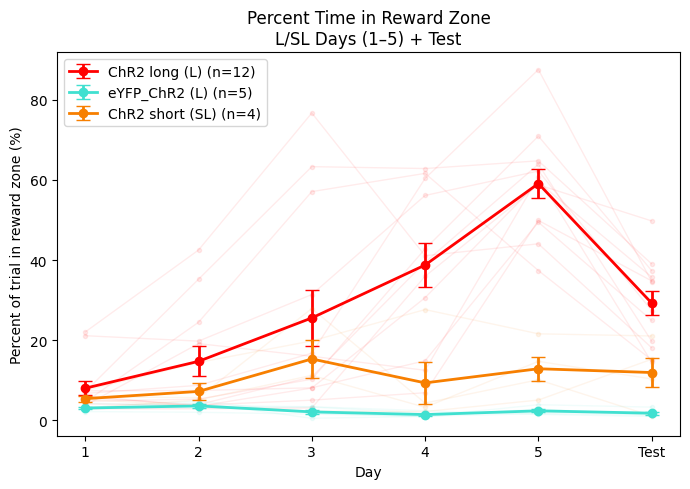

In [160]:
# =============================================================
# Build subject × day performance matrices for 3 groups:
# percent time in trigger zone over learning days + test

# ------------------------------------------------------------
# 0. Base metadata filter: usable animals, ChR2/eYFP, L/SL/T
# ------------------------------------------------------------
meta_all = metadata[
    (metadata['usable'] == 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2'])) &
    (metadata['trial_type'].isin(['L', 'SL', 'T']))
].copy()

plot_days = np.arange(1, 7)  # 1–5 learning + 6 = test


# ------------------------------------------------------------
# 1. Helper to build subject × day matrix for a group
#    learning_type: 'L' or 'SL'
# ------------------------------------------------------------
def build_group_matrix(meta_all, genotype, learning_type='L',
                       short_duration_val=None, require_complete=True):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs

    learning_type: 'L' or 'SL' (what counts as learning trials)
    short_duration_val:
        None  -> no filter on short_duration
        0 or 1 -> restrict to that short_duration
    """
    # genotype + (learning_type or T)
    mask = (meta_all['genotype'] == genotype) & \
           (meta_all['trial_type'].isin([learning_type, 'T']))

    if short_duration_val is not None:
        mask &= (meta_all['short_duration'] == short_duration_val)

    meta_g = meta_all[mask].copy()
    if len(meta_g) == 0:
        return None, []

    perf_mat = []
    subjects = []

    for sub in meta_g['sub'].unique():
        ms = meta_g[meta_g['sub'] == sub].copy()

        # reset plot_day for this animal
        ms['plot_day'] = np.nan

        # learning trials for this animal
        mL = ms[ms['trial_type'] == learning_type]
        if len(mL) == 0:
            continue

        # learning days = trial_type_day (1–5)
        ms.loc[mL.index, 'plot_day'] = mL['trial_type_day']

        # use 'ses' to find first T session after last learning session
        last_L_ses = mL['ses'].max()
        mT_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
        if len(mT_after) == 0:
            continue

        first_T_ses = mT_after['ses'].min()
        idx_T = ms.index[(ms['trial_type'] == 'T') & (ms['ses'] == first_T_ses)]
        ms.loc[idx_T, 'plot_day'] = 6

        # mean pct time in trigger per plot_day
        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        # build [day1..day6] vector
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        if require_complete and np.any(np.isnan(vals)):
            continue  # enforce full 6 days

        if np.all(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ------------------------------------------------------------
# 2. Build matrices for the three groups
#    Group 1: ChR2, short_duration == 0, learning_type = 'L'
#    Group 2: eYFP_ChR2, any short_duration, learning_type = 'L'
#    Group 3: ChR2, short_duration == 1, learning_type = 'SL'
# ------------------------------------------------------------

# Group 1: ChR2 long
mat_ChR2_long, subs_ChR2_long = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='L',
    short_duration_val=0,
    require_complete=True
)

# Group 2: eYFP_ChR2
mat_eYFP, subs_eYFP = build_group_matrix(
    meta_all,
    genotype='eYFP_ChR2',
    learning_type='L',
    short_duration_val=None,
    require_complete=True
)

# Group 3: ChR2 short (SL learning)
mat_ChR2_short, subs_ChR2_short = build_group_matrix(
    meta_all,
    genotype='ChR2',
    learning_type='SL',
    short_duration_val=1,
    require_complete=True
)

print("ChR2 long (short_duration=0) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 0)]['sub'].nunique())
print("ChR2 long animals plotted:", len(subs_ChR2_long))

print("eYFP_ChR2 animals in data:",
      meta_all[meta_all['genotype'] == 'eYFP_ChR2']['sub'].nunique())
print("eYFP_ChR2 animals plotted:", len(subs_eYFP))

print("ChR2 short (short_duration=1) animals in data:",
      meta_all[(meta_all['genotype'] == 'ChR2') & (meta_all['short_duration'] == 1)]['sub'].nunique())
print("ChR2 short animals plotted:", len(subs_ChR2_short))


# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

x_vals = plot_days - 1  # 0..5 indices

def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return
    # faded individual traces
    for row in mat:
        plt.plot(
            x_vals,
            row,
            '-o',
            color=color,
            alpha=0.08,
            linewidth=1,
            markersize=3,
            label='_nolegend_'
        )
    # group mean ± SEM
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])
    plt.errorbar(
        x_vals, mean_, yerr=sem_,
        fmt='-o', color=color,
        capsize=5,
        linewidth=2,
        markersize=6,
        label=f'{label} (n={len(subs)})'
    )

# Group 1: ChR2 long – red
plot_group(mat_ChR2_long, subs_ChR2_long, color='red', label='ChR2 long (L)')

# Group 2: eYFP_ChR2 – turquoise
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2 (L)')

# Group 3: ChR2 short – orange
plot_group(mat_ChR2_short, subs_ChR2_short, color='#f77f00', label='ChR2 short (SL)')

plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nL/SL Days (1–5) + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)
plt.legend()
plt.tight_layout()
plt.show()

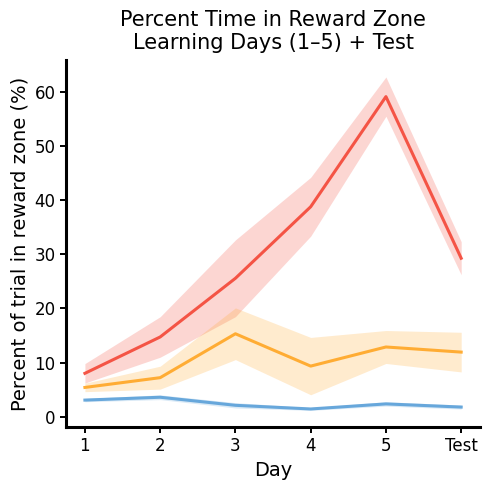

In [164]:
# ------------------------------------------------------------
# 3. Plot: mean ± shaded SEM, using colour function
# ------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) matrix of pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'ChR2_short')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no individual traces, no dots)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Group 1: ChR2 long – use 'ChR2' colour
plot_group_shaded(
    mat_ChR2_long,
    subs_ChR2_long,
    genotype_key='ChR2',
    label='ChR2 long (L)'
)

# Group 2: eYFP_ChR2 – use 'eYFP_ChR2' colour
plot_group_shaded(
    mat_eYFP,
    subs_eYFP,
    genotype_key='eYFP_ChR2',
    label='eYFP_ChR2 (L)'
)

# Group 3: ChR2 short – use 'ChR2_short' colour
plot_group_shaded(
    mat_ChR2_short,
    subs_ChR2_short,
    genotype_key='ChR2_short',
    label='ChR2 short (SL)'
)


# ------------------------------------------------------------
# Axes + style
# ------------------------------------------------------------
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days (1–5) + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

# plt.legend(frameon=False)
plt.tight_layout()
plt.show()

ChR2 animals in data: 12
ChR2 animals plotted: 12
eYFP animals in data: 5
eYFP animals plotted: 5
Hp animals in data: 7
Hp animals plotted: 7


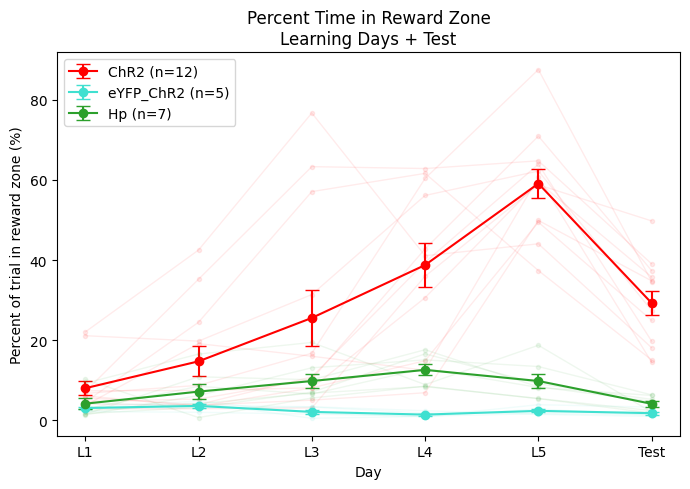

In [165]:
# plot ChR2 & eYFP_ChR2 & Hp learning trials + test after learning

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. Filter metadata: usable animals, 3 genotypes, L or T trials
# ---------------------------------------------------------------------
meta_LT = metadata[
    (metadata['usable'] == 1) &
    (metadata['short_duration'] != 1) &
    (metadata['genotype'].isin(['ChR2', 'eYFP_ChR2', 'Hp'])) &
    (metadata['trial_type'].isin(['L', 'T']))
].copy()

# Create plot_day:
# - L trials → trial_type_day 1–5
# - T trials → set later to day 6
meta_LT['plot_day'] = np.nan
mask_L = meta_LT['trial_type'] == 'L'
meta_LT.loc[mask_L, 'plot_day'] = meta_LT.loc[mask_L, 'trial_type_day']


# ---------------------------------------------------------------------
# 1b. Assign the first T *session* after the last L session to plot_day = 6
# ---------------------------------------------------------------------
for sub in meta_LT['sub'].unique():
    ms = meta_LT[meta_LT['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()

    T_after = ms[(ms['trial_type'] == 'T') &
                 (ms['ses'] > last_L_ses)]

    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()

    idx = meta_LT.index[
        (meta_LT['sub'] == sub) &
        (meta_LT['trial_type'] == 'T') &
        (meta_LT['ses'] == first_T_ses)
    ]
    meta_LT.loc[idx, 'plot_day'] = 6


plot_days = np.arange(1, 7)   # 1–5 learning + 6 = test session


# ---------------------------------------------------------------------
# 2. Helper: build subject × day matrix for each genotype
# ---------------------------------------------------------------------
def build_genotype_matrix(meta_group):
    """
    Returns:
      - perf_mat: (n_subjects x 6) matrix of pct_time_in_trigger
      - subjects: list of subject IDs
    Only keeps animals with complete 1–6 days.
    """
    perf_mat = []
    subjects = []

    for sub in meta_group['sub'].unique():
        ms = meta_group[meta_group['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_time_in_trigger'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days])

        if np.any(np.isnan(vals)):
            continue   # require complete 6 days

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# ---------------------------------------------------------------------
# 3. Build matrices for the three groups
# ---------------------------------------------------------------------
meta_ChR2 = meta_LT[meta_LT['genotype'] == 'ChR2']
meta_eYFP = meta_LT[meta_LT['genotype'] == 'eYFP_ChR2']
meta_Hp   = meta_LT[meta_LT['genotype'] == 'Hp']

mat_ChR2, subs_ChR2 = build_genotype_matrix(meta_ChR2)
mat_eYFP, subs_eYFP = build_genotype_matrix(meta_eYFP)
mat_Hp,   subs_Hp   = build_genotype_matrix(meta_Hp)

print("ChR2 animals in data:", meta_ChR2['sub'].nunique())
print("ChR2 animals plotted:", len(subs_ChR2))
print("eYFP animals in data:", meta_eYFP['sub'].nunique())
print("eYFP animals plotted:", len(subs_eYFP))
print("Hp animals in data:", meta_Hp['sub'].nunique())
print("Hp animals plotted:", len(subs_Hp))


# ---------------------------------------------------------------------
# 4. Plot
# ---------------------------------------------------------------------
plt.figure(figsize=(7, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group(mat, subs, color, label):
    if mat is None or len(subs) == 0:
        return

    # individual traces
    for row in mat:
        plt.plot(x_vals, row, '-o', color=color, alpha=0.08, linewidth=1, markersize=3,label='_nolegend_')

    # group mean ± sem
    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals, mean_, yerr=sem_, fmt='-o', color=color,
        capsize=5, label=f'{label} (n={len(subs)})'
    )


# Plot groups
plot_group(mat_ChR2, subs_ChR2, color='red',     label='ChR2')
plot_group(mat_eYFP, subs_eYFP, color='turquoise', label='eYFP_ChR2')
plot_group(mat_Hp,   subs_Hp,   color='#2ca02c', label='Hp')


plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')
plt.title('Percent Time in Reward Zone\nLearning Days + Test')
plt.xticks(
    ticks=np.arange(6),
    labels=['L1','L2','L3','L4','L5','Test']
)
plt.legend()
plt.tight_layout()
plt.show()

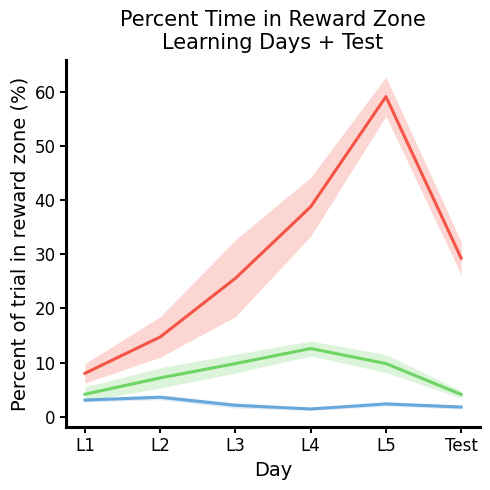

In [167]:
# ---------------------------------------------------------------------
# 4. Plot: mean ± shaded SEM, colour function, no individual traces
# ---------------------------------------------------------------------
plt.figure(figsize=(5, 5))
x_vals = plot_days - 1  # 0..5 indices


def plot_group_shaded(mat, subs, genotype_key, label,
                      alpha_fill=0.22, alpha_line=0.9):
    """
    mat:   (n_animals x n_days) pct_time_in_trigger
    subs:  list of subject IDs
    genotype_key: key for get_genotype_color (e.g. 'ChR2', 'Hp')
    """
    if mat is None or len(subs) == 0:
        return

    mean_ = np.nanmean(mat, axis=0)
    sem_  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = get_genotype_color(genotype_key)

    # shaded SEM band
    plt.fill_between(
        x_vals,
        mean_ - sem_,
        mean_ + sem_,
        color=col,
        alpha=alpha_fill,
        linewidth=0
    )

    # mean line (no markers, no individuals)
    plt.plot(
        x_vals,
        mean_,
        '-',
        color=col,
        alpha=alpha_line,
        linewidth=2.2,
        label=f'{label} (n={len(subs)})'
    )


# Plot groups with your colour scheme
plot_group_shaded(mat_ChR2, subs_ChR2,
                  genotype_key='ChR2',
                  label='ChR2')

plot_group_shaded(mat_eYFP, subs_eYFP,
                  genotype_key='eYFP_ChR2',
                  label='eYFP_ChR2')

plot_group_shaded(mat_Hp, subs_Hp,
                  genotype_key='Hp',
                  label='Hp')

# Axis labels, ticks, style
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)
plt.title('Percent Time in Reward Zone\nLearning Days + Test',
          fontsize=15, pad=8)

plt.xticks(
    ticks=np.arange(6),
    labels=['L1', 'L2', 'L3', 'L4', 'L5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', length=4, width=1.4)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Compute percentage of time spent in reward zone for REMAPPING group


In [137]:
# ----- COMPUTE PERCENT TIME IN TRIGGER ZONE (PER TRIGGER) -----

metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)

# New column: % of trial spent in ANY trigger zone (like your example)
metadata['pct_time_in_trigger'] = np.nan

R_TRIGGER = (10/1.2)  # radius defining trigger zone

pct_rows = []  # will hold per-trigger rows: trial_id, trigger_id, pct_in_trigger_trig

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])

    # Load position data
    position = dl.get_data('position')
    if position is None or len(position) == 0:
        continue

    # Load trigger locations
    triggerLoc = dl.get_data('triggerLoc')
    if triggerLoc is None or len(triggerLoc) == 0:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    # Add distance to each trigger
    position_ = add_dist_to_trigger(position, triggerLoc)

    # Trial duration (same units as df_trigger_interaction['duration'])
    trial_duration = position_['t'].max()
    if trial_duration <= 0:
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, R_TRIGGER, ti=i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)

    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        metadata.at[trial_id, 'pct_time_in_trigger'] = np.nan
        continue

    df_all_triggers = pd.concat(dfs, ignore_index=True)
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)

    # ---- ANY trigger, like your original code ----
    total_time_in_trigger = df_all_triggers['duration'].sum()
    pct_time_in_trigger = 100.0 * total_time_in_trigger / trial_duration
    metadata.at[trial_id, 'pct_time_in_trigger'] = pct_time_in_trigger

    # ---- PER TRIGGER: same logic, but restricted to each trigger_id ----
    for trig_id in range(1, trigger_num + 1):
        df_t = df_all_triggers[df_all_triggers['trigger_id'] == trig_id]
        if len(df_t) == 0:
            pct_trig = 0.0   # spent 0% of time in this trigger
        else:
            total_t_trig = df_t['duration'].sum()
            pct_trig = 100.0 * total_t_trig / trial_duration

        pct_rows.append({
            'trial_id': trial_id,
            'trigger_id': trig_id,
            'pct_in_trigger_trig': pct_trig
        })

# Long-format per-trigger table + metadata
df_pct = pd.DataFrame(pct_rows)
meta_pct = df_pct.merge(metadata, left_on='trial_id', right_index=True, how='left')

 15%|█▌        | 705/4611 [00:07<00:42, 91.59it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 26%|██▌       | 1180/4611 [00:12<00:35, 95.80it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 57%|█████▋    | 2608/4611 [00:25<00:14, 141.90it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 4611/4611 [00:44<00:00, 104.73it/s]


Reward zone 1: n animals plotted = 12
Reward zone 1 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Reward zone 2: n animals plotted = 12
Reward zone 2 animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


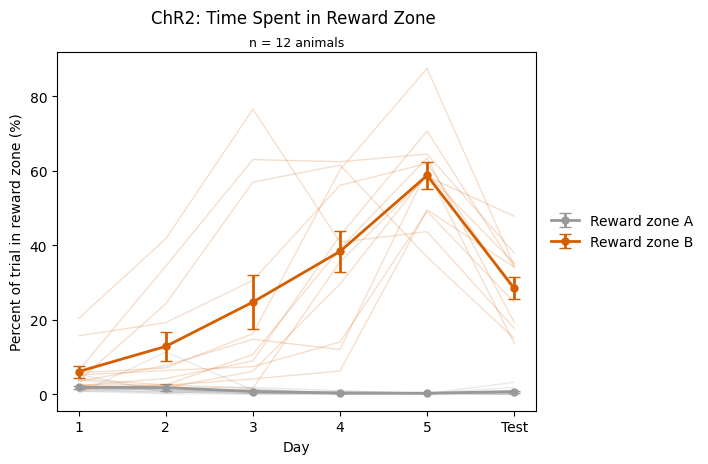

In [138]:
# ----- FILTER: ChR2, L/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['L', 'T']))
].copy()

# L days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_L = (mt['trial_type'] == 'L')
mt.loc[mask_L, 'plot_day'] = mt.loc[mask_L, 'trial_type_day']

# keep only L days 1–5 for L trials
mt = mt[(~mask_L) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last L session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    L_ses = ms.loc[ms['trial_type'] == 'L', 'ses']
    if len(L_ses) == 0:
        continue

    last_L_ses = L_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_L_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]


# ----- BUILD SUBJECT × DAY MATRIX PER REWARD ZONE (PERCENT TIME) -----

def build_zone_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_zone = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_zone['sub'].unique():
        ms = mt_zone[mt_zone['sub'] == sub]

        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects


# Only 2 reward zones: trigger_id 1 and 2
zone_ids = [1, 2]

mat_zone = {}
subs_zone = {}
for zid in zone_ids:
    mat, subs = build_zone_matrix_pct(mt, zid)
    mat_zone[zid] = mat
    subs_zone[zid] = subs
    print(f"Reward zone {zid}: n animals plotted = {len(subs)}")
    print(f"Reward zone {zid} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Paper-style colors for A/B
colors = {
    1: '#999999',  # Reward zone A
    2: '#D55E00',  # Reward zone B
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None:
        continue

    # individual animals (faded) + ID labels at end
    for row, sub in zip(mat, subs):
        plt.plot(
            x_vals,
            row,
            '-',
            color=colors[zid],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )


    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[zid],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[zid]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)
ax.text(
    0.5, 1.01,
    f'n = {n_animals} animals',
    transform=ax.transAxes,
    ha='center',
    va='bottom',
    fontsize=9
)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()

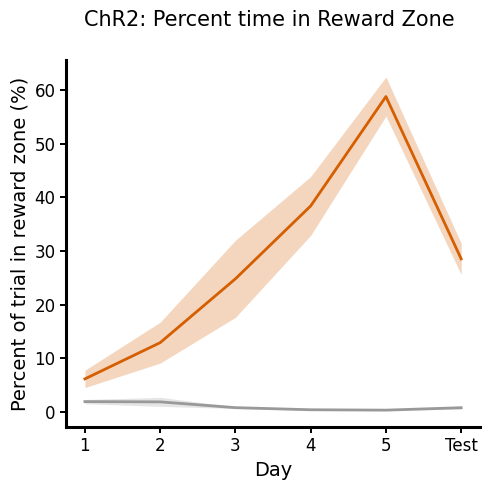

In [146]:
# ----- PLOT: PERCENT TIME IN REWARD ZONE (ChR2, ZONE A/B) -----

plt.figure(figsize=(5, 5))
x_vals = plot_days - 1   # 0..5 index for days 1–6

colors = {
    1: '#999999',  # zone A
    2: '#D55E00',  # zone B
}
#labels = {
#    1: 'Reward zone A',
#    2: 'Reward zone B',
#}

all_animals = sorted(set().union(*subs_zone.values()))
n_animals = len(all_animals)

for zid in zone_ids:
    mat = mat_zone[zid]
    subs = subs_zone[zid]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[zid]

    # ---- shaded SEM ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[zid]} (n={len(subs)})"
    )

# ----- axis + styling -----
ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1','2','3','4','5','Test'],
    fontsize=12
)

plt.yticks(fontsize=12)

# thick bottom/left, hide top/right
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent time in Reward Zone \n', fontsize=15, pad=8)

# small n info
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Animals included per reward zone:
  Reward zone 1: 12 animals
  Reward zone 2: 12 animals

Total unique animals included (any zone): 12
Animal IDs: [np.int64(1), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]


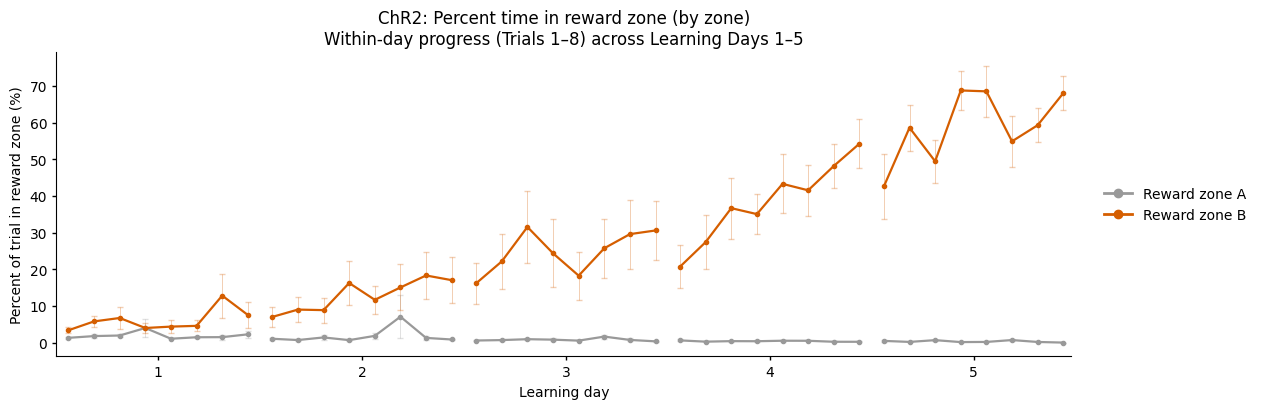

In [139]:
# ============================================================
# Within-day progress across Learning Days 1–5 (Trials 1–8)
# Metric: pct_in_trigger_trig (% of trial in reward zone)
# Group: ChR2 only
# Separate curves for trigger_id 1 and 2 (Reward zone A/B)
# Notes:
#   - excludes short_duration == 1
#   - allows missing trials within a day (curve uses available points)
#   - no individual background traces (mean ± SEM only)
# ============================================================

# ----------------------------
# SETTINGS
# ----------------------------
days = np.array([1, 2, 3, 4, 5])
trials = np.arange(1, 9)
zone_ids = [1, 2]

colors = {
    1: '#999999',  # Reward zone A (grey)
    2: '#D55E00',  # Reward zone B (orange)
}
labels = {
    1: 'Reward zone A',
    2: 'Reward zone B',
}

# ------------------------------------------------------------
# 1) Filter meta_pct: ChR2, L only, days 1–5, NOT short
# ------------------------------------------------------------
meta_L = meta_pct[
    (meta_pct['usable'] == 1) &
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'] == 'L') &
    (meta_pct['trial_type_day'].isin(days)) &
    (meta_pct['trigger_id'].isin(zone_ids)) &
    (meta_pct['pct_in_trigger_trig'].notna())
].copy()

# ------------------------------------------------------------
# 2) Create trial_in_day = 1..8 based on UNIQUE TRIALS (not rows)
#    so trigger A and B share the same trial number
# ------------------------------------------------------------

# Use a stable per-trial key
if 'trial_id' not in meta_L.columns:
    # fallback: if you don't have trial_id, use the index as trial id
    meta_L = meta_L.reset_index().rename(columns={'index': 'trial_id'})

# Build a per-trial table (one row per real trial)
trial_table = (
    meta_L[['trial_id', 'sub', 'ses', 'trial_type_day']]
    .drop_duplicates('trial_id')
    .sort_values(['sub', 'ses', 'trial_type_day', 'trial_id'])
    .copy()
)

# Assign trial numbers within each session (or within each day — see note below)
trial_table['trial_in_day'] = trial_table.groupby(['sub', 'ses']).cumcount() + 1

# Keep only trials 1..8
trial_table = trial_table[trial_table['trial_in_day'].between(1, 8)]

# Merge back so BOTH triggers get the SAME trial_in_day
meta_L = meta_L.merge(
    trial_table[['trial_id', 'trial_in_day']],
    on='trial_id',
    how='inner'
)

# ------------------------------------------------------------
# 3) Helper: subject × trial matrix for a given day AND zone
# ------------------------------------------------------------
def subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id):
    md = meta_g[(meta_g['trial_type_day'] == day) & (meta_g['trigger_id'] == zone_id)]
    if len(md) == 0:
        return None

    rows = []
    for sub in md['sub'].unique():
        ms = md[md['sub'] == sub]
        mean_by_trial = ms.groupby('trial_in_day')['pct_in_trigger_trig'].mean()
        vals = np.array([mean_by_trial.get(t, np.nan) for t in trials], dtype=float)

        if not np.all(np.isnan(vals)):
            rows.append(vals)

    if len(rows) == 0:
        return None

    return np.vstack(rows)

# ------------------------------------------------------------
# 4) Plot helper: within-day curves for ONE zone (mean ± SEM)
# ------------------------------------------------------------
def plot_within_day_curves_for_zone(ax, meta_g, zone_id, color, alpha=1.0):
    offsets = np.linspace(0.06, 0.94, len(trials))  # 8 points within each day bin

    for day in days:
        mat = subject_trial_matrix_for_day_and_zone(meta_g, day, zone_id)
        if mat is None:
            continue

        x = day + offsets
        mean_ = np.nanmean(mat, axis=0)
        n_per_trial = np.sum(~np.isnan(mat), axis=0)
        sem_ = np.nanstd(mat, axis=0) / np.sqrt(np.maximum(n_per_trial, 1))

        # mean line
        ax.plot(
            x, mean_,
            'o-',
            color=color,
            alpha=alpha,
            linewidth=1.6,
            markersize=3
        )

        # SEM bars (faded)
        ax.errorbar(
            x, mean_, yerr=sem_,
            fmt='none',
            ecolor=color,
            alpha=min(alpha, 0.3),
            elinewidth=0.7,
            capsize=2
        )

# ------------------------------------------------------------
# 5) Nature-style axes
# ------------------------------------------------------------
def style_nature(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(direction='out', length=3, width=1)
    ax.grid(False)

# ------------------------------------------------------------
# 6) Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(15, 4.2))

for zid in zone_ids:
    plot_within_day_curves_for_zone(
        ax,
        meta_L,
        zone_id=zid,
        color=colors[zid],
        alpha=1.0
    )

ax.set_xlabel('Learning day')
ax.set_ylabel('Percent of trial in reward zone (%)')

# Center ticks under each day curve
ax.set_xticks(days + 0.5)
ax.set_xticklabels([str(d) for d in days])

# Make sure day 5 curve fully visible and reduce left whitespace
ax.set_xlim(1.0, 5.98)

ax.set_title(
    'ChR2: Percent time in reward zone (by zone)\n'
    'Within-day progress (Trials 1–8) across Learning Days 1–5',
    fontsize=12
)

style_nature(ax)

from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], color='#999999', lw=2, marker='o', label='Reward zone A'),
    Line2D([0], [0], color='#D55E00', lw=2, marker='o', label='Reward zone B'),
]

plt.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Animal counts (based on *this* filtered dataset)
# ------------------------------------------------------------
subs_zone = {
    zid: sorted(meta_L.loc[meta_L['trigger_id'] == zid, 'sub'].unique())
    for zid in zone_ids
}

print("Animals included per reward zone:")
for zid in zone_ids:
    print(f"  Reward zone {zid}: {len(subs_zone[zid])} animals")

all_animals = sorted(set().union(*subs_zone.values()))
print(f"\nTotal unique animals included (any zone): {len(all_animals)}")
print("Animal IDs:", all_animals)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()


Trigger 1: n animals plotted = 7
Trigger 1 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 2: n animals plotted = 7
Trigger 2 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------
Trigger 3: n animals plotted = 7
Trigger 3 animal IDs: [np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(16), np.int64(18)]
--------------------------------------------------


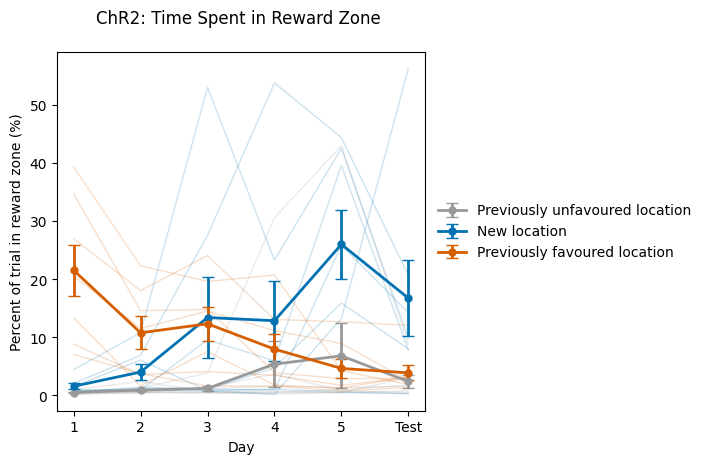

In [155]:
# ----- FILTER: ChR2, RL/T, NOT SHORT, ASSIGN DAYS 1–5 + TEST DAY 6 -----

import numpy as np
import matplotlib.pyplot as plt

mt = meta_pct[
    (meta_pct['short_duration'] != 1) &
    (meta_pct['genotype'] == 'ChR2') &
    (meta_pct['trial_type'].isin(['RL', 'T']))
].copy()

# RL days: use trial_type_day (1–5)
mt['plot_day'] = np.nan
mask_RL = (mt['trial_type'] == 'RL')
mt.loc[mask_RL, 'plot_day'] = mt.loc[mask_RL, 'trial_type_day']

# keep only RL days 1–5 for RL trials
mt = mt[(~mask_RL) | (mt['trial_type_day'].isin([1, 2, 3, 4, 5]))]

# assign FIRST T session after last RL session as day 6, per animal
for sub in mt['sub'].unique():
    ms = mt[mt['sub'] == sub]

    RL_ses = ms.loc[ms['trial_type'] == 'RL', 'ses']
    if len(RL_ses) == 0:
        continue

    last_RL_ses = RL_ses.max()
    T_after = ms[(ms['trial_type'] == 'T') & (ms['ses'] > last_RL_ses)]
    if len(T_after) == 0:
        continue

    first_T_ses = T_after['ses'].min()
    idx = mt.index[
        (mt['sub'] == sub) &
        (mt['trial_type'] == 'T') &
        (mt['ses'] == first_T_ses)
    ]
    mt.loc[idx, 'plot_day'] = 6

plot_days = np.arange(1, 7)
mt = mt[mt['plot_day'].isin(plot_days)]



# ----- BUILD SUBJECT × DAY MATRIX PER TRIGGER (PERCENT TIME) -----

def build_trigger_matrix_pct(mt_all, trigger_id):
    perf_mat = []
    subjects = []

    mt_trig = mt_all[mt_all['trigger_id'] == trigger_id]

    for sub in mt_trig['sub'].unique():
        ms = mt_trig[mt_trig['sub'] == sub]

        # mean % time per day for this subject & trigger
        mean_by_day = ms.groupby('plot_day')['pct_in_trigger_trig'].mean()

        vals = np.array([mean_by_day.get(d, np.nan) for d in plot_days], dtype=float)

        # require complete 6 days
        if np.any(np.isnan(vals)):
            continue

        perf_mat.append(vals)
        subjects.append(sub)

    if len(perf_mat) == 0:
        return None, []

    return np.vstack(perf_mat), subjects

mat_trig = {}
subs_trig = {}
for trig_id in [1, 2, 3]:
    mat, subs = build_trigger_matrix_pct(mt, trig_id)
    mat_trig[trig_id] = mat
    subs_trig[trig_id] = subs
    print(f"Trigger {trig_id}: n animals plotted = {len(subs)}")
    print(f"Trigger {trig_id} animal IDs:", subs)
    print("-" * 50)


# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(8.5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None:
        continue

    # individual animals (faded)
    for row in mat:
        plt.plot(
            x_vals,
            row,                      # already in %
            '-',
            color=colors[trig_id],
            alpha=0.2,
            linewidth=1,
            label='_nolegend_'
        )

    # group mean ± SEM
    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    plt.errorbar(
        x_vals,
        mean_vals,
        yerr=sem_vals,
        fmt='o-',
        color=colors[trig_id],
        capsize=4,
        linewidth=2,
        markersize=5,
        label=labels[trig_id]
    )

ax = plt.gca()
plt.xlabel('Day')
plt.ylabel('Percent of trial in reward zone (%)')

# Main title + smaller n-line
plt.title('ChR2: Time Spent in Reward Zone \n', fontsize=12)


plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test']
)

# Legend outside, on the right
plt.legend(
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 0.95])
plt.show()


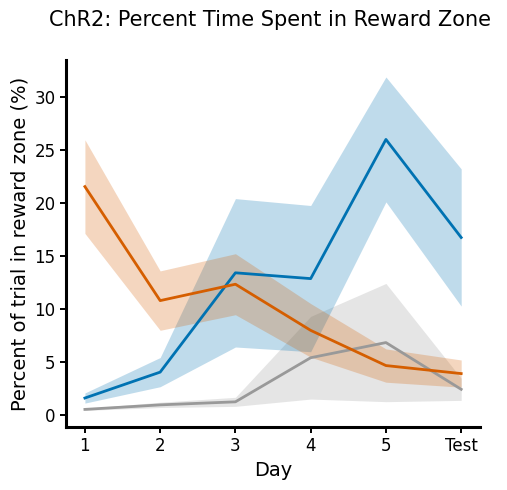

In [158]:
# ----- PLOT: PERCENT TIME IN TRIGGER ZONE (ChR2, PER TRIGGER) -----

plt.figure(figsize=(5, 5))

x_vals = plot_days - 1  # 0..5

# Colorblind-friendly “paper” colors, same as latency plot
colors = {
    1: '#999999',  # grey  - previously unfavoured
    2: '#0072B2',  # blue  - new location
    3: '#D55E00',  # orange - previously favoured
}

labels = {
    1: 'Previously unfavoured location',
    2: 'New location',
    3: 'Previously favoured location',
}

# union of animals across triggers (same logic as latency plot)
all_animals = sorted(set().union(*subs_trig.values()))
n_animals = len(all_animals)

for trig_id in [1, 2, 3]:
    mat  = mat_trig[trig_id]
    subs = subs_trig[trig_id]
    if mat is None or len(subs) == 0:
        continue

    mean_vals = np.nanmean(mat, axis=0)
    sem_vals  = np.nanstd(mat, axis=0) / np.sqrt(mat.shape[0])

    col = colors[trig_id]

    # ---- shaded SEM band ----
    plt.fill_between(
        x_vals,
        mean_vals - sem_vals,
        mean_vals + sem_vals,
        color=col,
        alpha=0.25,
        linewidth=0
    )

    # ---- mean line (no markers, no individuals) ----
    plt.plot(
        x_vals,
        mean_vals,
        '-',
        color=col,
        linewidth=2,
        label=f"{labels[trig_id]} (n={len(subs)})"
    )

ax = plt.gca()
plt.xlabel('Day', fontsize=14)
plt.ylabel('Percent of trial in reward zone (%)', fontsize=14)

plt.xticks(
    ticks=np.arange(6),
    labels=['1', '2', '3', '4', '5', 'Test'],
    fontsize=12
)
plt.yticks(fontsize=12)

# journal-style axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(2.2)
ax.spines['left'].set_linewidth(2.2)
ax.tick_params(direction='out', width=1.4, length=4)

plt.title('ChR2: Percent Time Spent in Reward Zone \n', fontsize=15, pad=8)

# small n text if you still want it
#ax.text(
#    0.5, 1.02,
#    f'n = {n_animals} animals',
#    transform=ax.transAxes,
#    ha='center',
#    fontsize=11
#)

#plt.legend(frameon=False)
plt.tight_layout()
plt.show()